# Análisis FBG PEEK-4: 3 Sensores (11/06/2026)

✅ **Fibra PEEK-4 con 3 sensores FBG funcionales**

Este notebook analiza **sensores FBG** de la fibra PEEK-4 (2 polarizaciones cada uno, medición del 11-06-2026).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.

## 📋 Configuración:
- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra
- **3 FBGs funcionales**: FBG-1, FBG-2, FBG-3 (cada uno con polarización P y S)
- **Fibra**: PEEK-7 con 450µm de diámetro
- **Análisis**: Media de polarizaciones vs temperatura
- **Plateaus**: Definición manual opcional
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

## 💡 Notas sobre el flujo de trabajo:
1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.
2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible, permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

### 🔍 Listar Archivos Disponibles (Opcional)

Si no estás seguro de qué archivos ROOT existen en el directorio, ejecuta esta celda para listarlos.

In [3]:
from zoneinfo import ZoneInfo
TZ_VALENCIA = ZoneInfo("Europe/Madrid")

# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260611.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
TIME_SHIFT = datetime.timedelta(hours=0)  # ✅ Ya no necesitamos shift, los conversores están arreglados

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

try:
    with uproot.open(filepath) as file:
        print(f"✓ Trees disponibles: {file.keys()}")
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
        press_data = file["press"].arrays(library="np")
    
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    times_peak_raw = peak_data["t"][:, 0]
    times_temp_raw = temp_data["t"]
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    temp_raw = temp_data["temp"]
    press_raw = press_data["press"]
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    
    # ✅ fromtimestamp + zona Valencia en lugar de utcfromtimestamp
    times_peak_original = np.array([
        datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None)
        for t in times_peak_raw
    ])
    times_temp = np.array([
        datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None)
        for t in times_temp_raw
    ])
    
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT (ahora es 0, pero se mantiene la lógica por si acaso)
    times_peak = times_peak_original + TIME_SHIFT
    times_raw = times_peak_raw
    times_all = times_peak
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")

except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260611.root
⏱️  TIME_SHIFT configurado: 0.0 horas
✓ Trees disponibles: ['peak;7', 'press;3', 'spectrum;2', 'temp;5']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (2194625, 2)
   wav: shape = (2194625, 2, 2)
   sweep: shape = (2194625, 2, 2)
   ch: shape = (2194625, 2)
   pos: shape = (2194625, 2)

✅ Datos cargados correctamente
   • Wavelength: (2194625, 2, 2)
   • Wavelength range: [1532.23, 1535.49] nm
   • Temperature: (8630, 8)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-06-11 12:27:43
   Fin:    2026-06-11 17:20:59

🔴 TEMPERATURA:
   Inicio: 2026-06-11 12:26:54
   Fin:    2026-06-11 17:21:06

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: -0.01 horas
   Temperatura END - Wavelength END: +0.00 horas

✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)


### 📊 Visualización rápida de Presión

⚠️ **ADVERTENCIA**: Los datos de presión en esta adquisición tienen problemas conocidos. Este plot es solo para verificación visual.

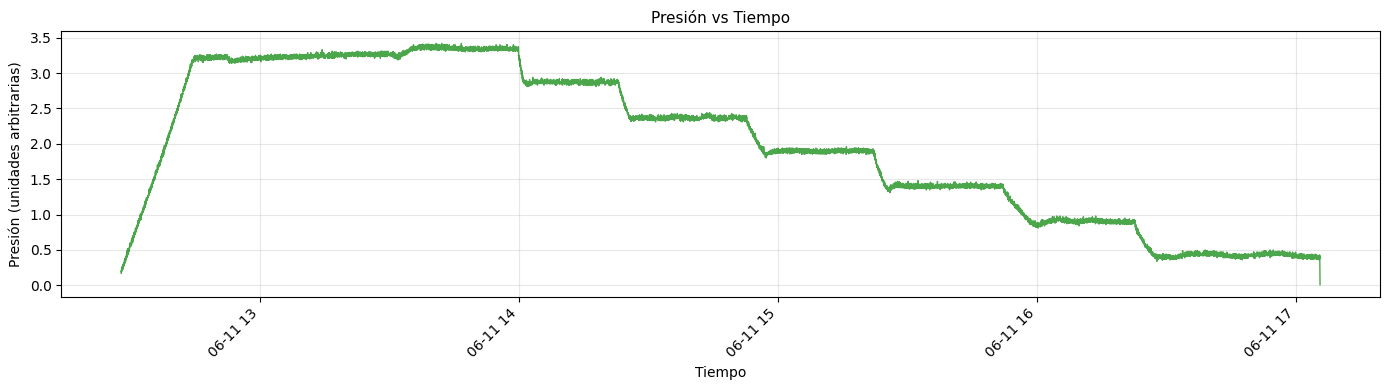

📊 Estadísticas de presión:
   Rango: [0.01, 3.42]
   Media: 2.01
   Std: 1.05
   Puntos válidos: 16,497


In [4]:
# Plot simple de presión vs tiempo (datos con problemas conocidos)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

# Extraer tiempos de presión y datos
times_press_raw = press_data["t"]
times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_press_raw])

# Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
else:
    press_data_plot = press_raw

# Filtrar valores positivos
press_valid_mask = press_data_plot > 0
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

if len(press_valid) > 0:
    ax.plot(times_press_valid, press_valid, 'g-', linewidth=1.0, alpha=0.7)
    ax.set_xlabel('Tiempo', fontsize=10)
    ax.set_ylabel('Presión (unidades arbitrarias)', fontsize=10)
    ax.set_title('Presión vs Tiempo', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Rotar etiquetas del eje X
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}]")
    print(f"   Media: {np.mean(press_valid):.2f}")
    print(f"   Std: {np.std(press_valid):.2f}")
    print(f"   Puntos válidos: {len(press_valid):,}")
else:
    print("⚠️ No hay datos válidos de presión para mostrar")

## 3️⃣ Filtrar Rango Temporal (16:00-17:30)

In [5]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 6, 11)  # ⬅️ CAMBIAR según tu archivo (20260609.root)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(13, 0))
    t_fin = datetime.datetime.combine(fecha, datetime.time(18, 0))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-06-11 12:27:43
   Fin:    2026-06-11 17:20:59

✅ Rango seleccionado para análisis:
   2026-06-11 13:00 - 18:00
   Puntos en el rango: 1,952,512


## 4️⃣ Análisis de Temperatura (8 RTDs)

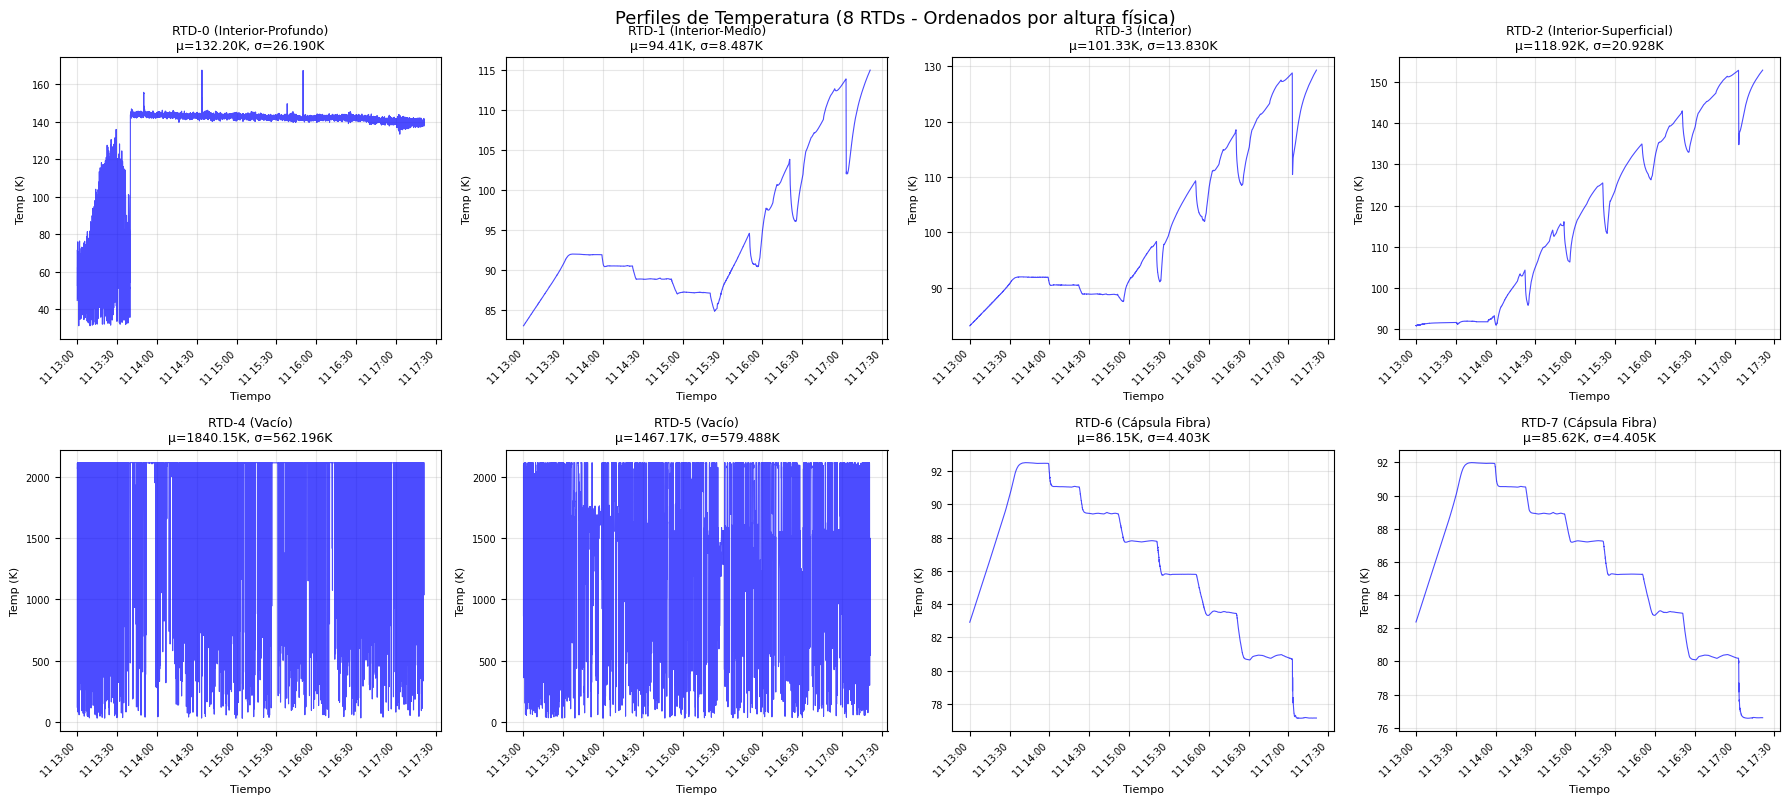


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ=132.20K  σ=26.190K
RTD-1 (Interior-Medio)        : μ= 94.41K  σ= 8.487K
RTD-3 (Interior)              : μ=101.33K  σ=13.830K
RTD-2 (Interior-Superficial)  : μ=118.92K  σ=20.928K
RTD-4 (Vacío)                 : μ=1840.15K  σ=562.196K
RTD-5 (Vacío)                 : μ=1467.17K  σ=579.488K
RTD-6 (Cápsula Fibra)         : μ= 86.15K  σ= 4.403K
RTD-7 (Cápsula Fibra)         : μ= 85.62K  σ= 4.405K


In [6]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [7]:
# ⚠️ CONFIGURACIÓN: Solo 2 sensores funcionales
# 2 sensores × 2 polarizaciones = 4 canales
# Índices 0-based: sensor 0, 1 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (2 sensores × 2 polarizaciones)")

✅ Configurados 4 canales FBG (2 sensores × 2 polarizaciones)


### 5.2 Filtrado Wavelength (μ±3σ)

In [8]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2):")
for sensor_idx in range(2):  # Solo 0, 1 (FBG-3 OMITIDO)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (1952512, 2, 2)
   Dimensiones: (time=1952512, pol=2, sensor=2)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2):
   FBG-1-P: 1952512 pts > 0, range=[1532.23, 1532.52] nm, μ=1532.40 nm
   FBG-1-S: 1952512 pts > 0, range=[1532.23, 1532.52] nm, μ=1532.40 nm
   FBG-2-P: 1952512 pts > 0, range=[1535.19, 1535.49] nm, μ=1535.36 nm
   FBG-2-S: 1952512 pts > 0, range=[1535.19, 1535.49] nm, μ=1535.36 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1532.399409  0.082201     1952512
FBG-1-S      1532.398532  0.082390     1952512
FBG-2-P      1535.360071  0.085644     1952512
FBG-2-S      1535.359988  0.084320     1952512


### 5.3 Calcular Media de Polarizaciones

In [9]:
# Calcular media P+S para cada sensor (solo sensores funcionales: 1, 2)
# FBG-3 omitido (sin datos)
fbg_mean_data = {}

for sensor_num in [1, 2]:  # Solo sensores funcionales (FBG-3 excluido)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para sensores funcionales")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para sensores funcionales

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1532.398970     0.082294        1952512
FBG-2-Mean      1535.360030     0.084976        1952512


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

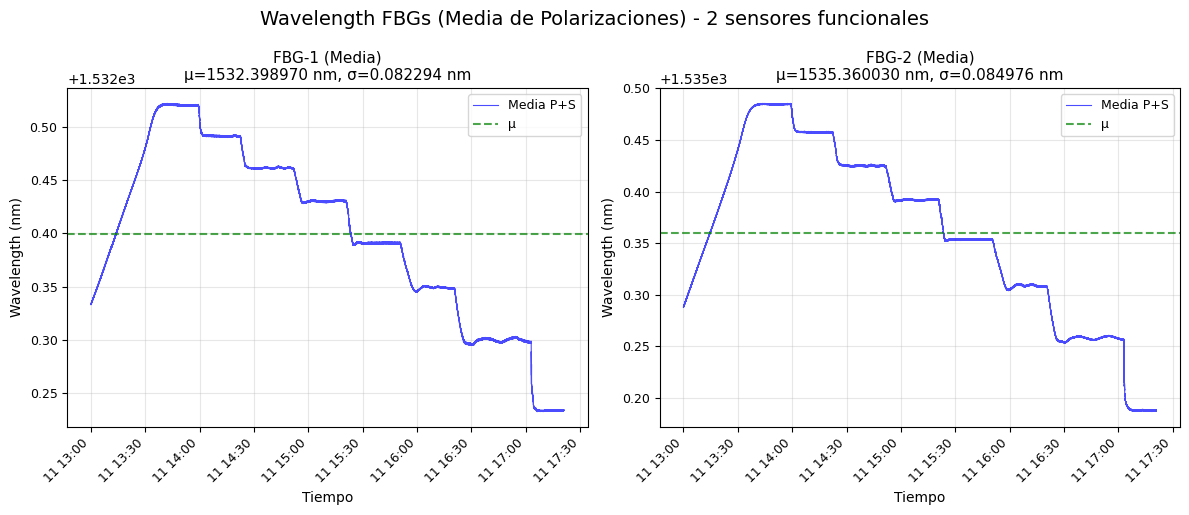

In [10]:
# Ajustar layout para 2 sensores (FBG-3 omitido)
n_sensors = len(fbg_mean_data)
if n_sensors == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores funcionales', fontsize=14, y=1.02)
plt.show()

## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [11]:
# Usar RTD-8 (cápsula fibra) como referencia
rtd_ref_idx = 7  # RTD-8 (cápsula fibra) es el sensor 7 (índice 7 en Python)
rtd_ref_name = "RTD-8 (1 timestamp every 2 seconds, 0.5Hz (2000 samples/point in))"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

print(f"✅ Referencia: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")

✅ Referencia: RTD-8 (1 timestamp every 2 seconds, 0.5Hz (2000 samples/point in))
   Rango: [76.57, 91.98] K


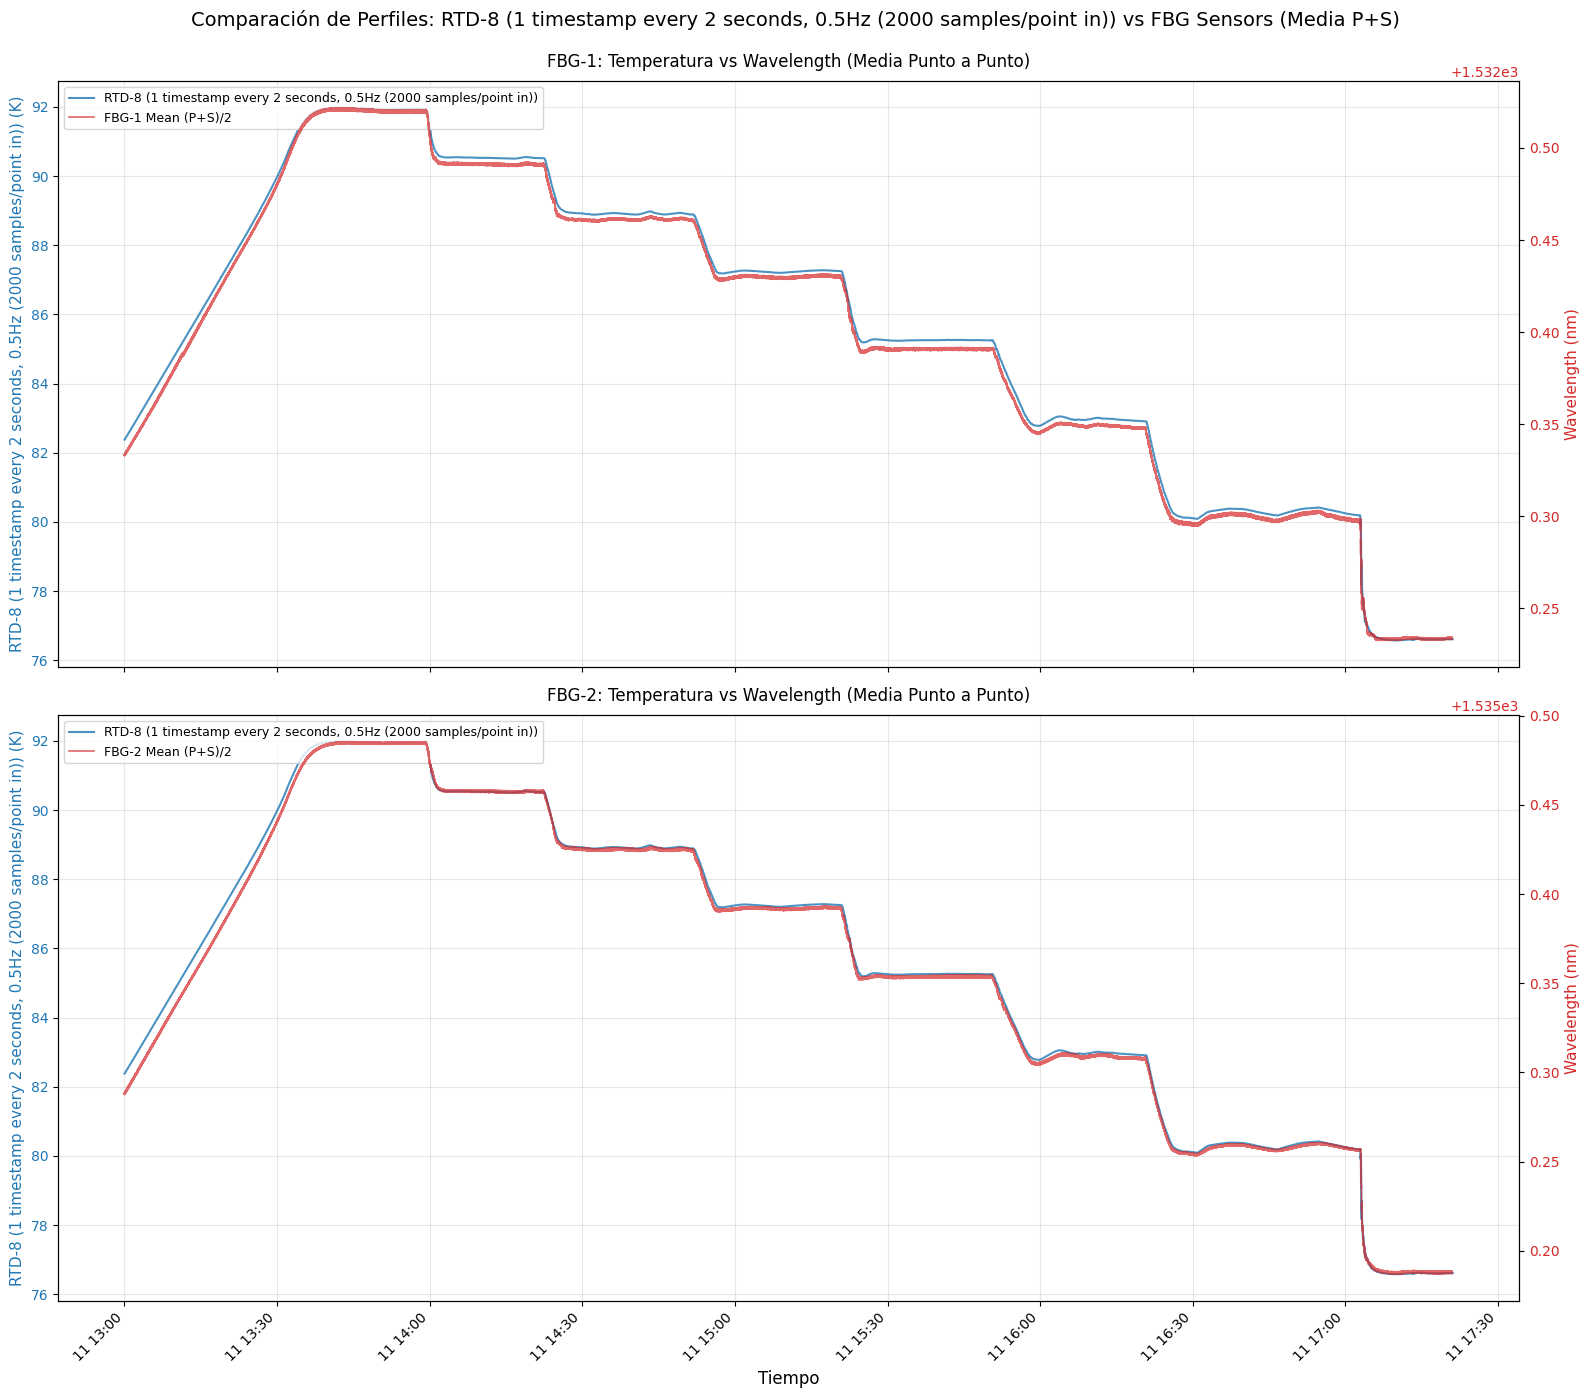

✅ Gráficos superpuestos generados para 2 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [12]:
# Superposición de temperatura con cada sensor FBG (2 subplots)
fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

color_temp = 'tab:blue'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength (media punto a punto P+S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines, 
                  labels1 + labels2 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura vs Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name} vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para 2 sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura y wavelength para identificar visualmente los plateaus.

### 6.3 Definición Manual de Plateaus

**✏️ Define aquí los intervalos temporales de plateau identificados en los gráficos anteriores**

In [13]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en los gráficos de la sección 6.2)
# ============================================================================
# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]

manual_plateaus = [
    ("Plateau 1", "13:49", "13:59"),
    ("Plateau 2", "14:12", "14:22"),
    ("Plateau 3", "14:40", "14:50"),
    ("Plateau 4", "15:10", "15:20"),
    ("Plateau 5", "15:40", "15:50"),
    ("Plateau 6", "16:09", "16:19"),
    ("Plateau 7", "16:52", "17:02"),
    ("Plateau 8", "17:10", "17:20"),
]

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*70)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "n_temp_points": len(temp_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*70)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1: 13:49 - 13:59
  Temperatura: μ=91.941K, σ=0.0034K, n=301
Plateau 2: 14:12 - 14:22
  Temperatura: μ=90.524K, σ=0.0125K, n=300
Plateau 3: 14:40 - 14:50
  Temperatura: μ=88.922K, σ=0.0256K, n=300
Plateau 4: 15:10 - 15:20
  Temperatura: μ=87.257K, σ=0.0189K, n=301
Plateau 5: 15:40 - 15:50
  Temperatura: μ=85.260K, σ=0.0038K, n=300
Plateau 6: 16:09 - 16:19
  Temperatura: μ=82.968K, σ=0.0237K, n=290
Plateau 7: 16:52 - 17:02
  Temperatura: μ=80.331K, σ=0.0705K, n=301
Plateau 8: 17:10 - 17:20
  Temperatura: μ=76.603K, σ=0.0124K, n=298

✅ 8 plateaus definidos


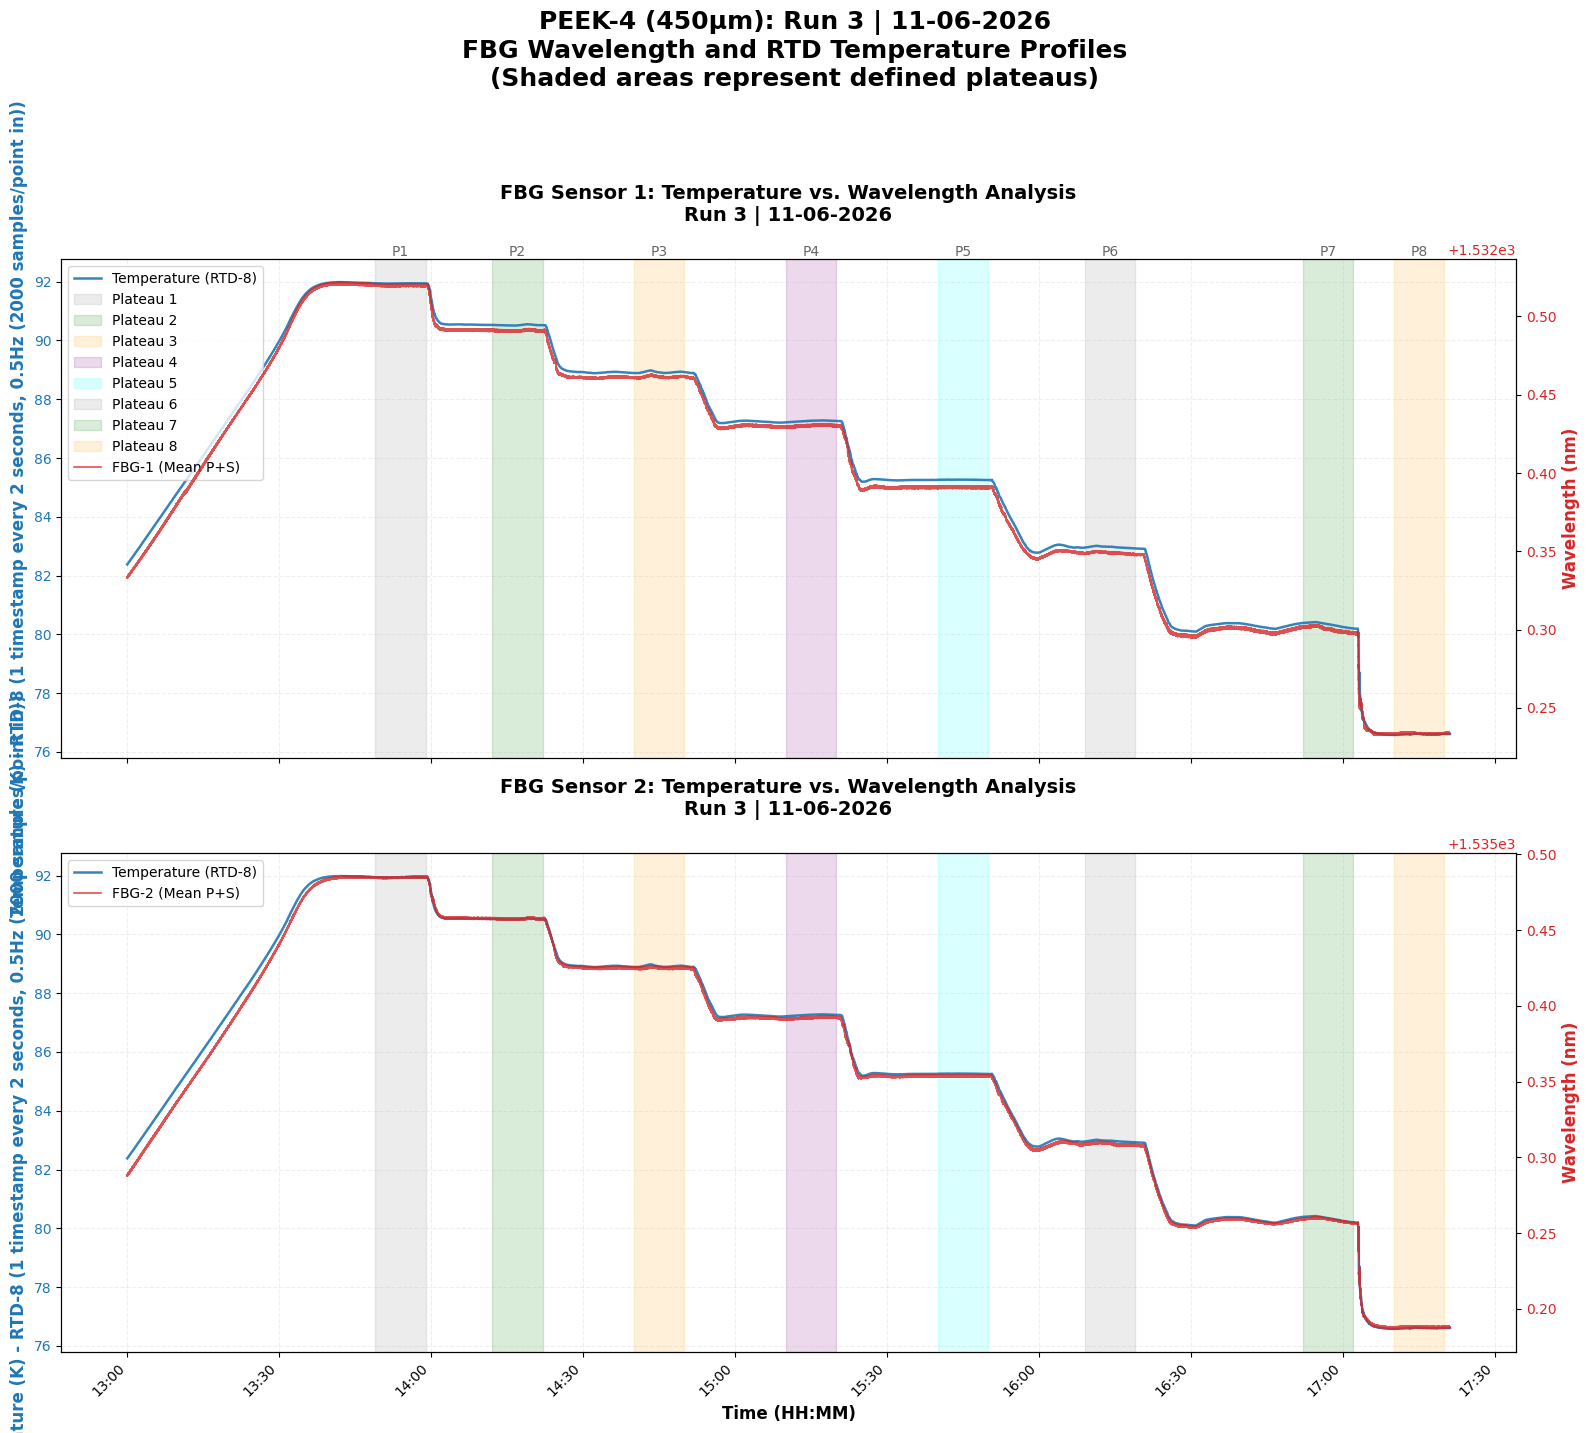

✅ Plot generated with English labels and shaded plateaus.


In [14]:
# ============================================================================
# PLOT: Wavelength vs Temperature with Shaded Plateaus (English)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_wav = 'tab:red'
# Colors for the plateau shaded areas
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue
        
    fbg_data_plot = fbg_mean_data[fbg_label]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD-6 Capsule)
    ax1.set_ylabel(f'Temperature (K) - {rtd_ref_name}', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.8, alpha=0.9, label='Temperature (RTD-8)')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], 
                        color=p_color, alpha=0.15, 
                        label=f'Plateau {p_idx+1}' if idx == 0 else "")
            # Optional: Add text label on top of the shaded area
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontsize=10, color='black', alpha=0.6)

    # 3. Right Axis: Wavelength
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color=color_wav, fontweight='bold')
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.8, 
             label=f'FBG-{sensor_num} (Mean P+S)')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: Temperature vs. Wavelength Analysis\nRun 3 | 11-06-2026', 
                  fontsize=14, pad=28, fontweight='bold')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.8)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Shared Layout
plt.suptitle('PEEK-4 (450µm): Run 3 | 11-06-2026\nFBG Wavelength and RTD Temperature Profiles\n(Shaded areas represent defined plateaus)', 
             fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()

print("✅ Plot generated with English labels and shaded plateaus.")

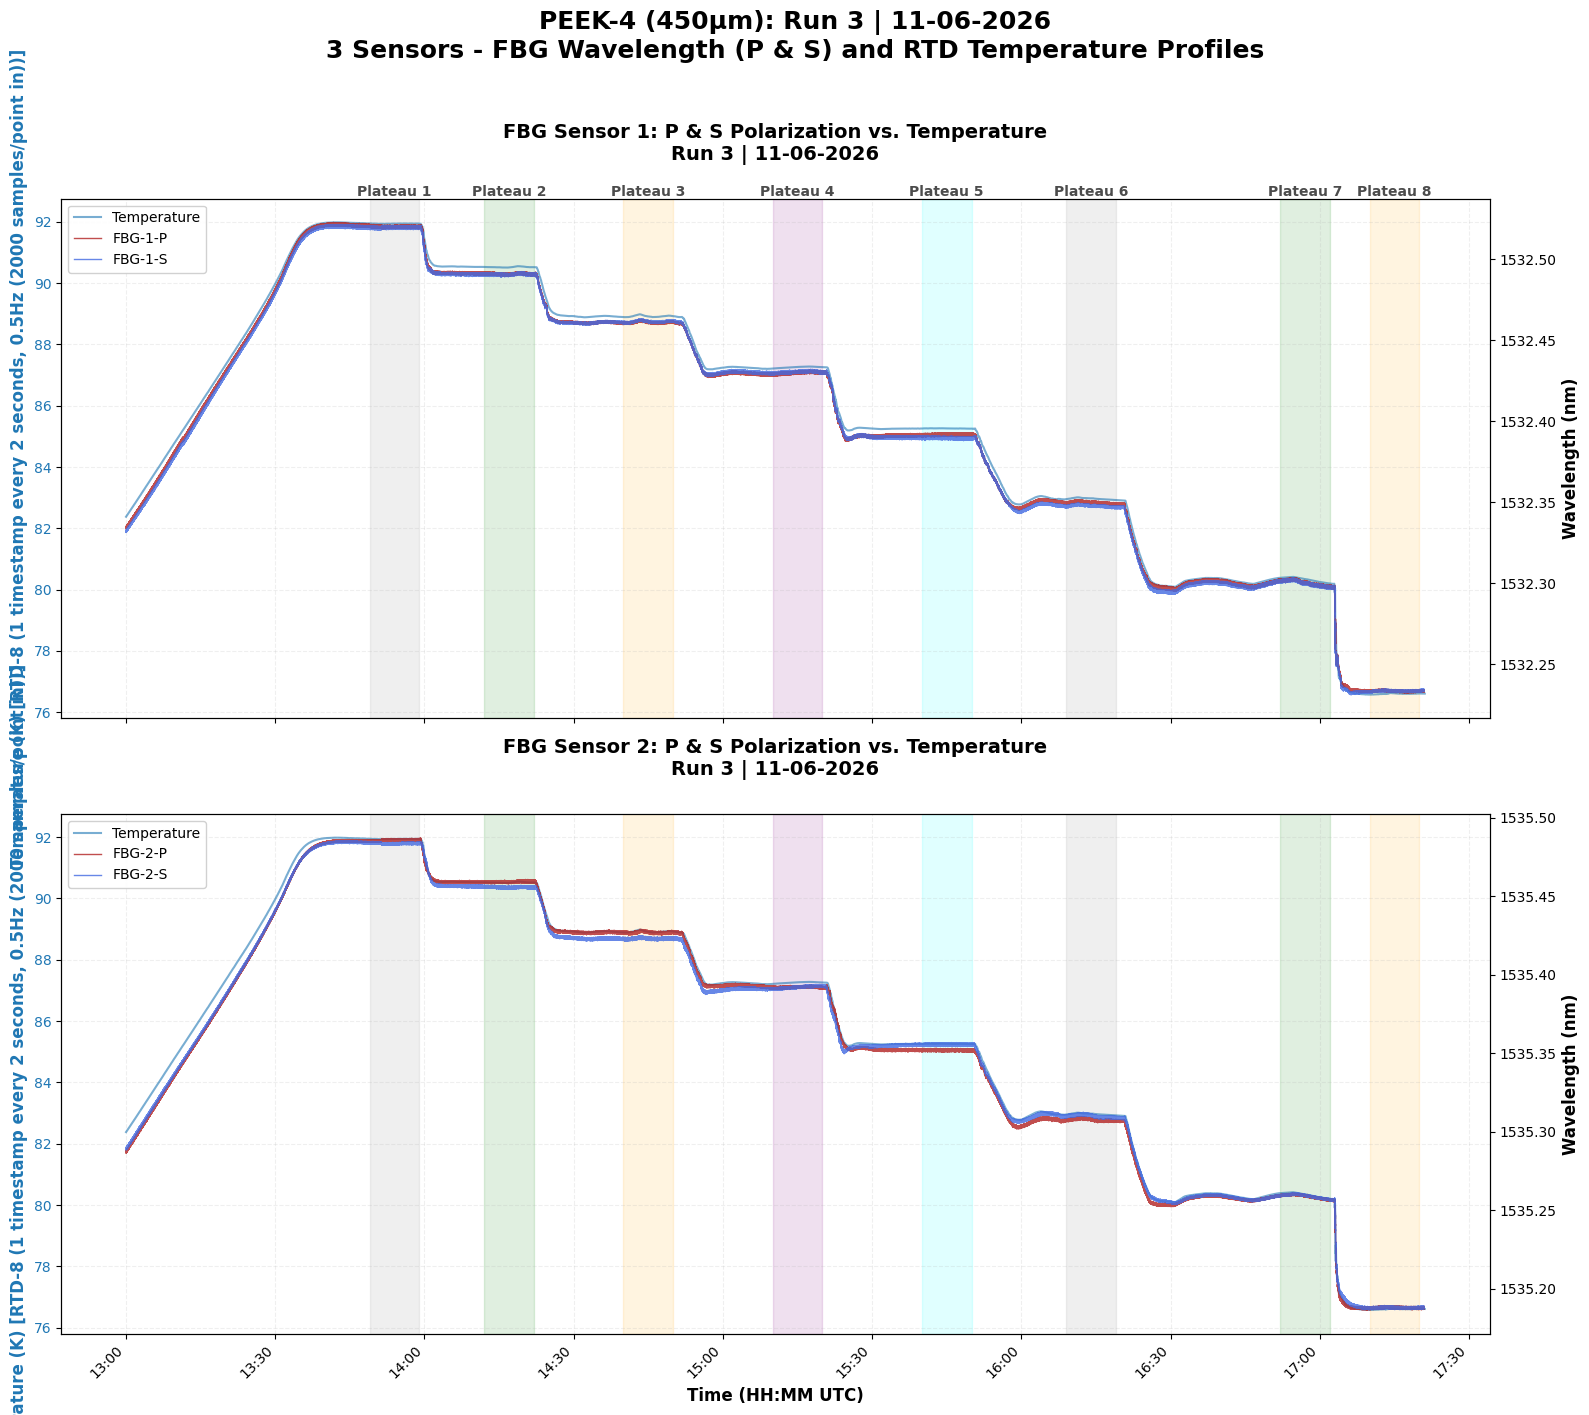

✅ Superimposed polarization plot generated.


In [15]:
# ============================================================================
# PLOT: Dual Polarization (P & S) vs Temperature with Shaded Plateaus
# Fiber: PEEK-4 (450µm) | Run 1 | 09-06-2026
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Color for Polarization P
color_pol_s = 'royalblue'   # Color for Polarization S
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 15), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    # Labels for both polarizations
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    
    if label_p not in fbg_filtered_data or label_s not in fbg_filtered_data:
        print(f"⚠️ Data missing for {label_p} or {label_s}, skipping...")
        continue
        
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temperature (K) [{rtd_ref_name}]', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.6, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # 2. Add Shaded Plateaus (Color bands)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], 
                        color=p_color, alpha=0.12)
            # Label plateaus at the top of the first subplot
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'Plateau {p_idx+1}', 
                         ha='center', va='bottom', fontsize=10, fontweight='bold', alpha=0.7)

    # 3. Right Axis: Wavelength (Superimposed Polarizations)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color='black', fontweight='bold')
    
    # Plot P Polarization
    ax2.plot(data_p["timestamps"], data_p["wavelength"], 
             color=color_pol_p, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    
    # Plot S Polarization
    ax2.plot(data_s["timestamps"], data_s["wavelength"], 
             color=color_pol_s, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.ticklabel_format(useOffset=False, axis='y') # Crucial to see pm changes
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: P & S Polarization vs. Temperature\nRun 3 | 11-06-2026',                  fontsize=14, pad=28, fontweight='bold')
    
    # Merge legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle('PEEK-4 (450µm): Run 3 | 11-06-2026\n3 Sensors - FBG Wavelength (P & S) and RTD Temperature Profiles', 
             fontsize=18, y=0.97, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("✅ Superimposed polarization plot generated.")

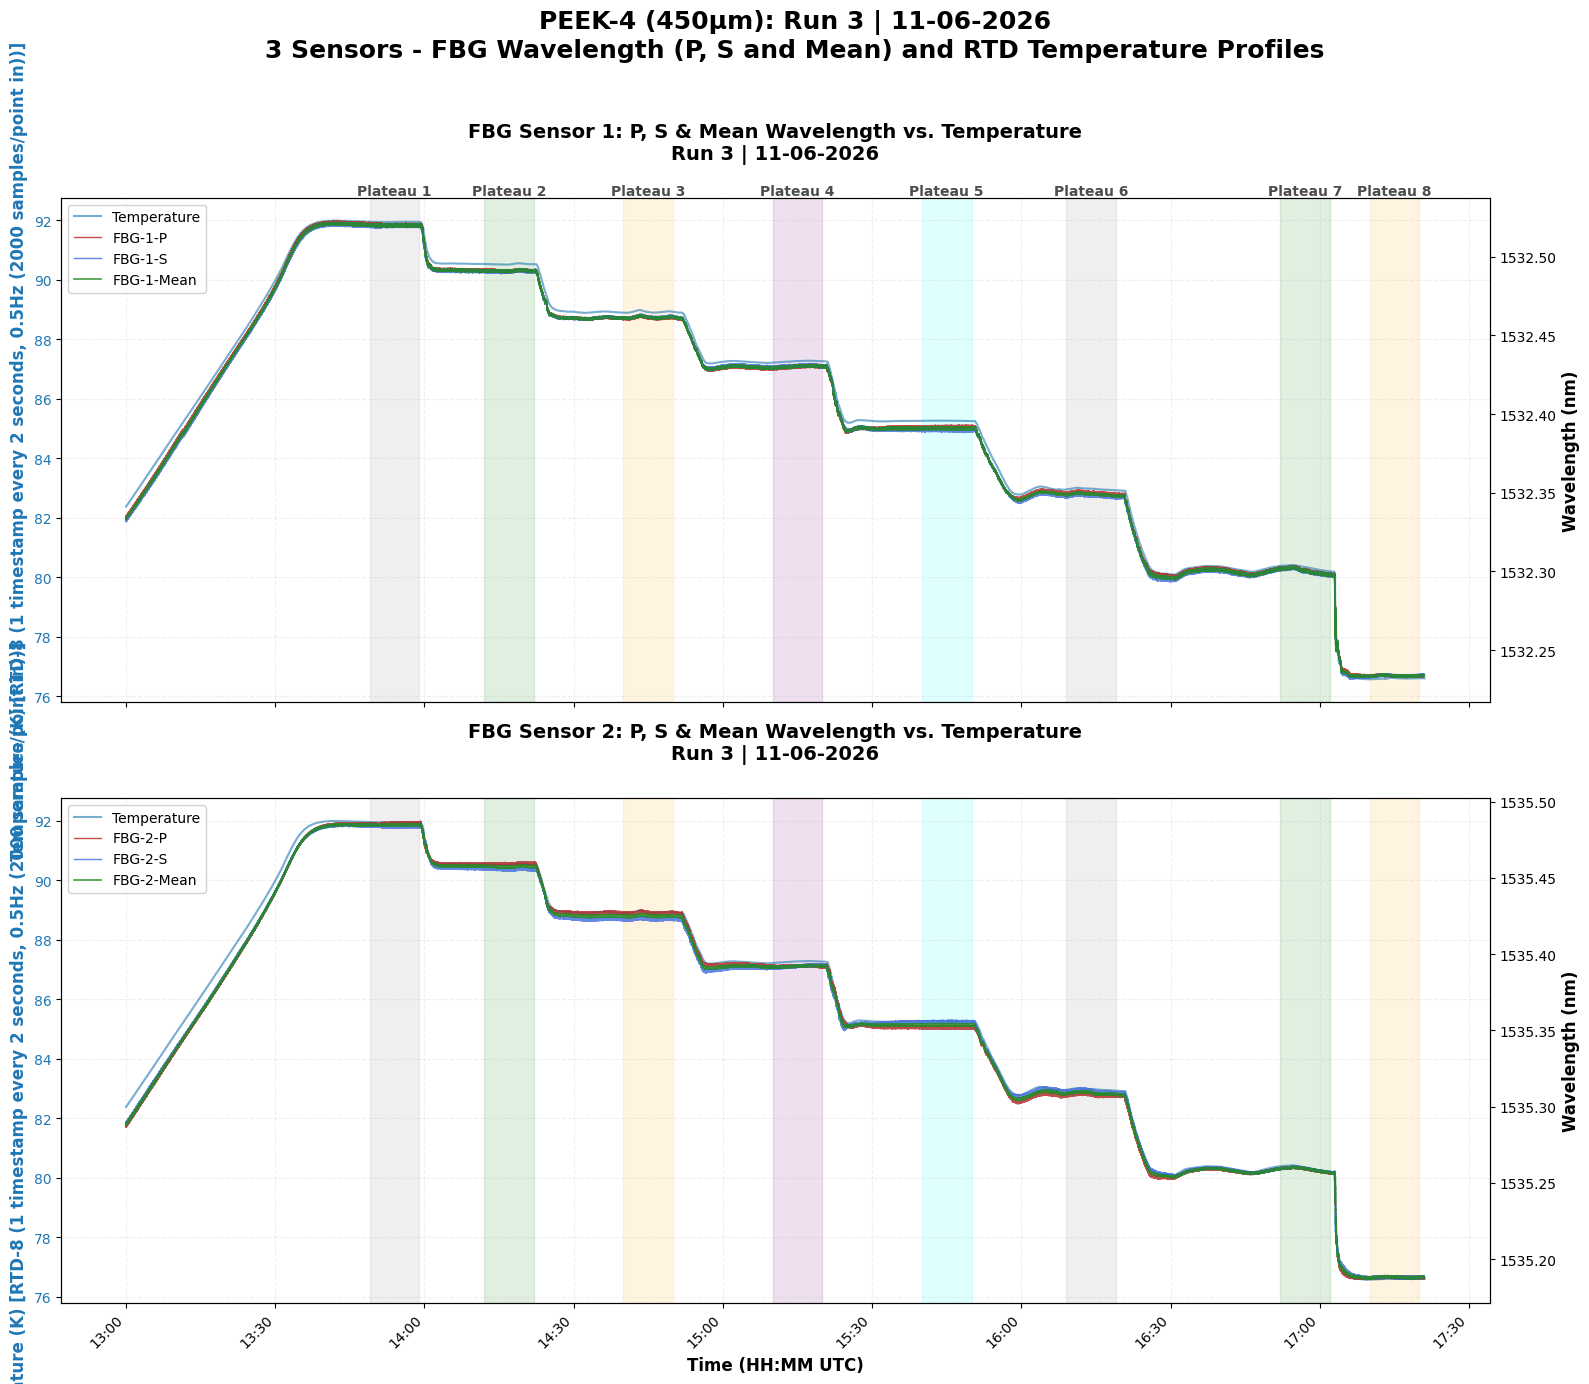

✅ Combined P/S/Mean plot generated.


In [16]:
# ============================================================================
# PLOT: P, S y Media vs Temperatura con Plateaus Sombreados
# Fiber: PEEK-4 (450µm) | Run 3 | 11-06-2026
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Color for Polarization P
color_pol_s = 'royalblue'   # Color for Polarization S
color_pol_mean = 'forestgreen'  # Color for Mean (P+S)/2
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(2, 1, figsize=(16, 15), sharex=True)

for idx, sensor_num in enumerate([1, 2]):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"

    if (
        label_p not in fbg_filtered_data or
        label_s not in fbg_filtered_data or
        label_mean not in fbg_mean_data
    ):
        print(f"⚠️ Data missing for {label_p}, {label_s} or {label_mean}, skipping...")
        continue

    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    data_mean = fbg_mean_data[label_mean]
    ax1 = axes[idx]

    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temperature (K) [{rtd_ref_name}]', fontsize=12, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.6, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')

    # 2. Add Shaded Plateaus (Color bands)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.12)
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'Plateau {p_idx+1}',
                         ha='center', va='bottom', fontsize=10, fontweight='bold', alpha=0.7)

    # 3. Right Axis: Wavelength (P, S and Mean)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=12, color='black', fontweight='bold')

    ax2.plot(data_p["timestamps"], data_p["wavelength"],
             color=color_pol_p, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"],
             color=color_pol_s, linewidth=1.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    ax2.plot(data_mean["timestamps"], data_mean["wavelength"],
             color=color_pol_mean, linewidth=1.2, alpha=0.85, label=f'FBG-{sensor_num}-Mean')

    ax2.tick_params(axis='y', labelcolor='black')
    ax2.ticklabel_format(useOffset=False, axis='y')

    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: P, S & Mean Wavelength vs. Temperature\nRun 3 | 11-06-2026',
                  fontsize=14, pad=28, fontweight='bold')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle('PEEK-4 (450µm): Run 3 | 11-06-2026\n3 Sensors - FBG Wavelength (P, S and Mean) and RTD Temperature Profiles',
             fontsize=18, y=0.95, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("✅ Combined P/S/Mean plot generated.")

### 6.4 Calcular Sensibilidad por Plateaus

Calcula la media y std de wavelength en cada plateau para cada sensor FBG.

In [17]:
# Calcular media y std de wavelength por plateau para cada sensor
plateau_sensitivity_data = {}

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    fbg_times = fbg_data["timestamps"]
    fbg_wav = fbg_data["wavelength"]
    
    plateau_wav_stats = []
    
    for plateau in plateau_data:
        # Máscara para datos de wavelength en este plateau
        mask_wav_plateau = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_plateau = fbg_wav[mask_wav_plateau]
        
        if len(wav_plateau) > 0:
            wav_mean = np.mean(wav_plateau)
            wav_std = np.std(wav_plateau)
            
            plateau_wav_stats.append({
                "name": plateau["name"],
                "temp_mean": plateau["temp_mean"],
                "temp_std": plateau["temp_std"],
                "wav_mean": wav_mean,
                "wav_std": wav_std,
                "n_wav_points": len(wav_plateau)
            })
    
    plateau_sensitivity_data[fbg_label] = plateau_wav_stats

print("✅ Estadísticas de wavelength calculadas por plateau")
print("\nResumen por sensor:")
print("="*80)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    n_plateaus = len(plateau_sensitivity_data[fbg_label])
    print(f"FBG-{sensor_num}: {n_plateaus} plateaus procesados")

✅ Estadísticas de wavelength calculadas por plateau

Resumen por sensor:
FBG-1: 8 plateaus procesados
FBG-2: 8 plateaus procesados


### 6.5 Visualizar Sensibilidad (Temp vs Wavelength con barras de error)

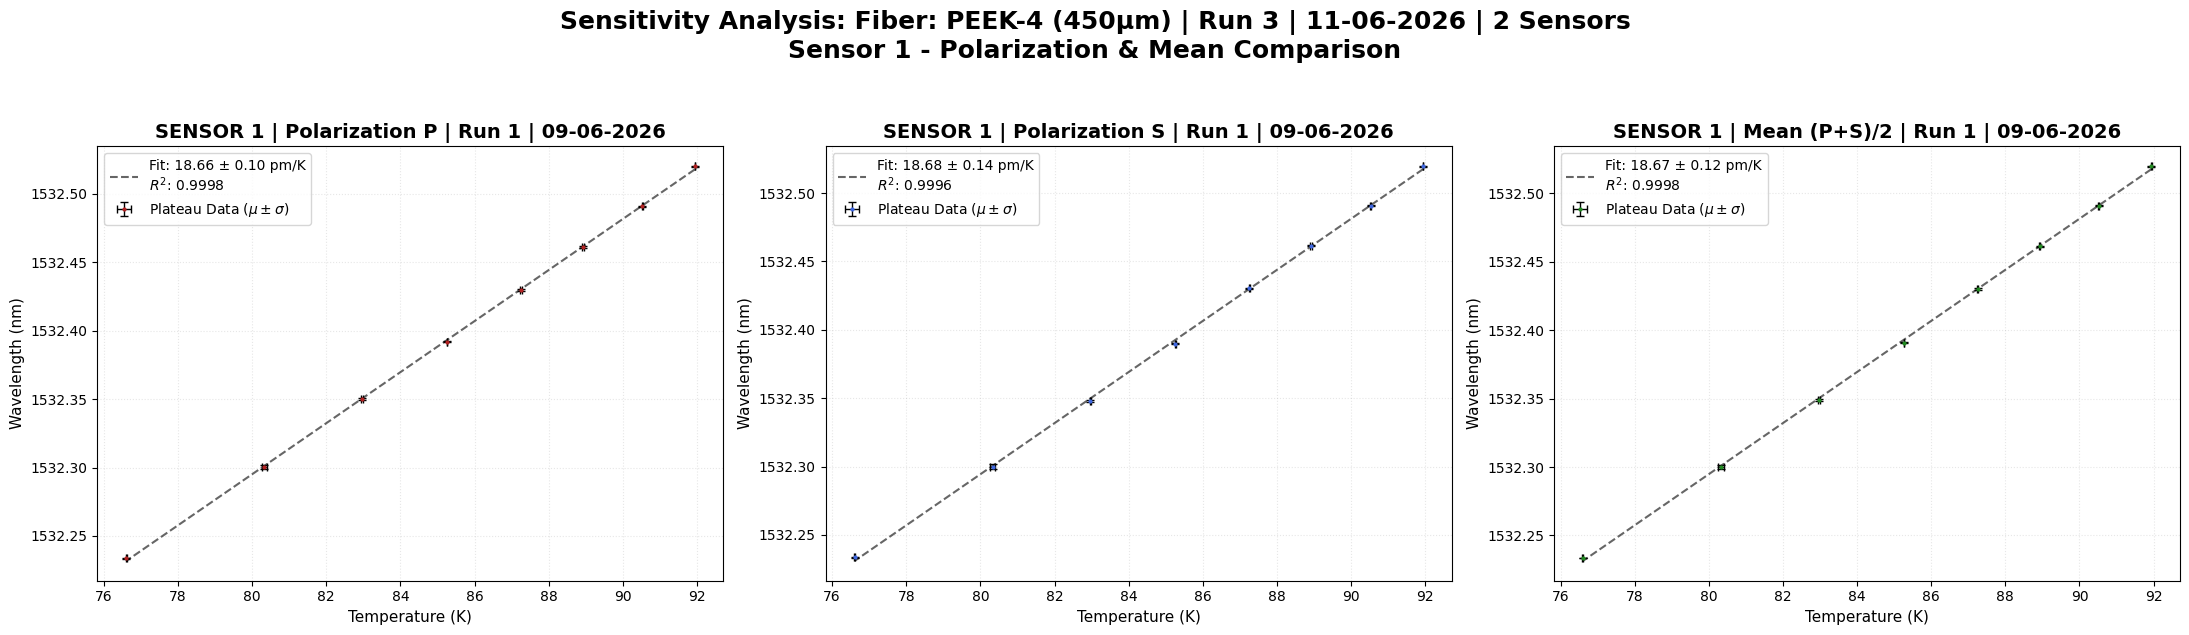

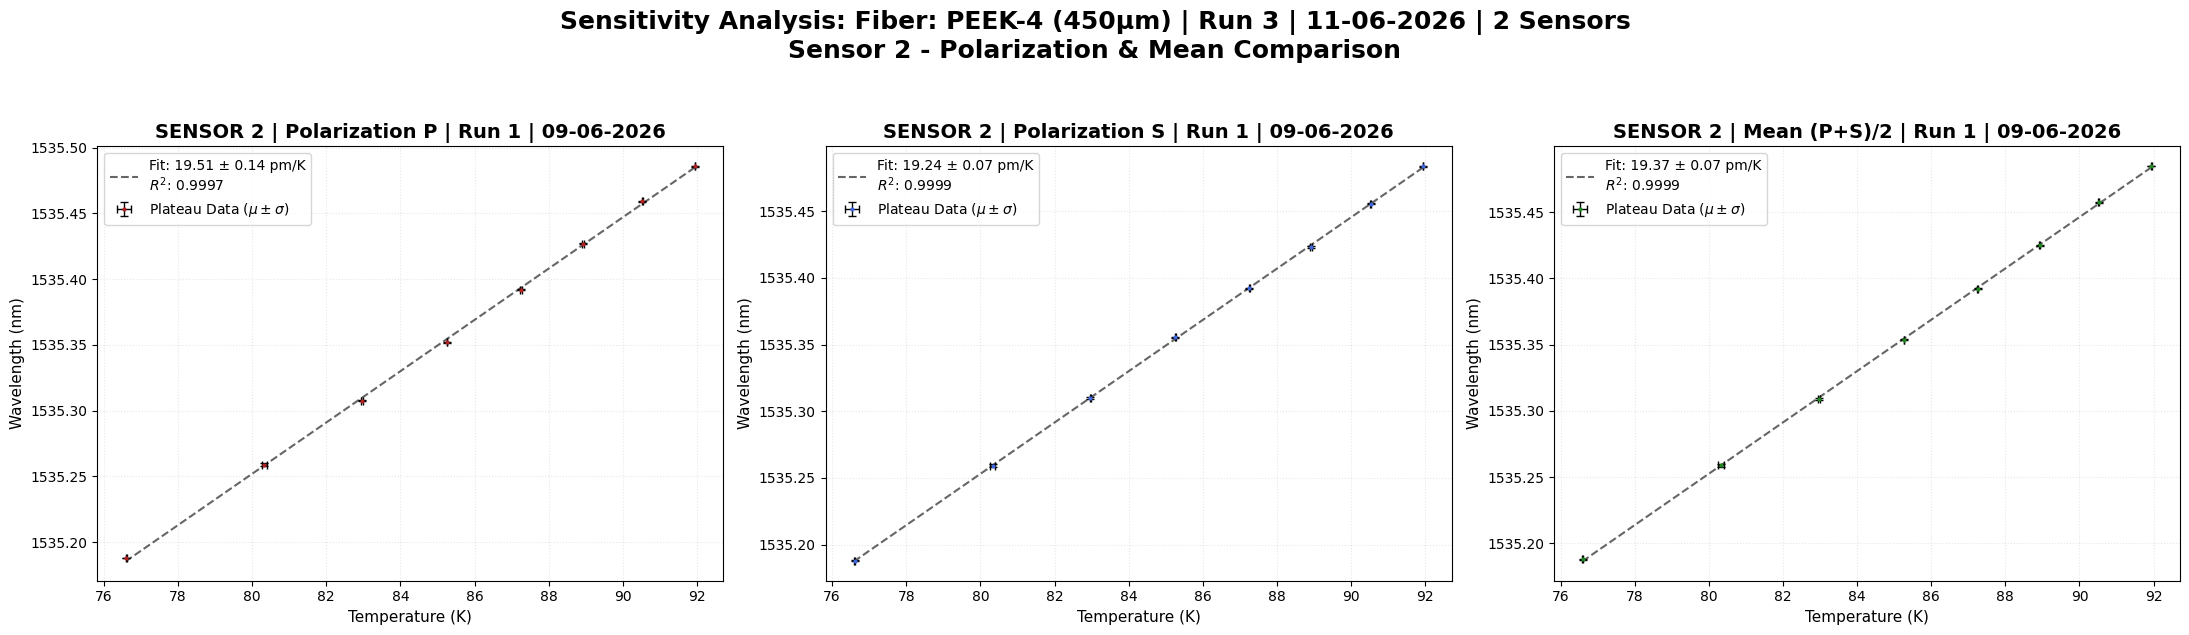


                  SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 1, 09-06-2026)                  
Sensor ID    | Measurement Type     | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
Sensor 1     | Polarization P       |       18.658       |        0.102    | 0.9998
Sensor 1     | Polarization S       |       18.681       |        0.143    | 0.9996
Sensor 1     | Mean (P+S)/2         |       18.669       |        0.118    | 0.9998
Sensor 2     | Polarization P       |       19.506       |        0.144    | 0.9997
Sensor 2     | Polarization S       |       19.238       |        0.071    | 0.9999
Sensor 2     | Mean (P+S)/2         |       19.372       |        0.074    | 0.9999


In [18]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber PEEK-7 | 2 Sensors | 27-02-2025
# Includes Slope Error in Legend, Summary Table and Explicit Sensor Labels
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Data structure to store results for the final summary table
summary_results = []

# Fiber and Run information for titles
fiber_info = "Fiber: PEEK-4 (450µm) | Run 3 | 11-06-2026 | 2 Sensors"

for sensor_num in [1, 2]:
    # Create a separate figure for each sensor with 2 subplots (P, S, Mean)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=False)
    
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Polarization P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Polarization S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for idx, config in enumerate(plot_configs):
        ax = axes[idx]
        label = config["key"]
        
        t_means, t_stds, w_means, w_stds = [], [], [], []
        
        # 1. Collect statistics for each plateau
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                # Temperature stats (Horizontal Error)
                t_means.append(p["temp_mean"])
                t_stds.append(p["temp_std"])
                
                # Wavelength stats (Vertical Error)
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    
                    if len(wav_data) > 0:
                        w_means.append(np.mean(wav_data))
                        w_stds.append(np.std(wav_data))
                    else:
                        w_means.append(np.nan); w_stds.append(np.nan)
                else:
                    w_means.append(np.nan); w_stds.append(np.nan)

            # Convert to arrays and filter NaNs
            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_stds); y_err = np.array(w_stds)
            
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                # 2. Linear Regression and Slope Error calculation
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                
                # Convert results to pm/K for standard reporting
                slope_pm = slope * 1e3
                err_pm = std_err * 1e3
                
                # Store data for the final summary table
                summary_results.append({
                    "Sensor": f"Sensor {sensor_num}",
                    "Type": config["title"],
                    "Slope": slope_pm,
                    "Error": err_pm,
                    "R2": r_val**2
                })

                # 3. Plotting with Error Bars
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=1, markersize=2, capsize=3, label='Plateau Data ($\mu \pm \sigma$)')
                
                # Plot Regression Line
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', alpha=0.6,
                        label=f'Fit: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}')

                # 4. SUBPLOT TITLES: Explicit Sensor Identification
                ax.set_title(f"SENSOR {sensor_num} | {config['title']} | Run 1 | 09-06-2026", fontsize=14, fontweight='bold')
                
                # Labels and Style
                ax.set_xlabel("Temperature (K)", fontsize=11)
                ax.set_ylabel("Wavelength (nm)", fontsize=11)
                ax.legend(fontsize=10, loc='best')
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.ticklabel_format(useOffset=False, axis='y')

    # Main Title for the whole sensor figure
    plt.suptitle(f"Sensitivity Analysis: {fiber_info}\nSensor {sensor_num} - Polarization & Mean Comparison", 
                 fontsize=18, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# FINAL SUMMARY TABLE: Results in pm/K
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 1, 09-06-2026)':^95}")
print("="*95)
print(f"{'Sensor ID':<12} | {'Measurement Type':<20} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['Sensor']:<12} | {res['Type']:<20} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")
print("="*95)

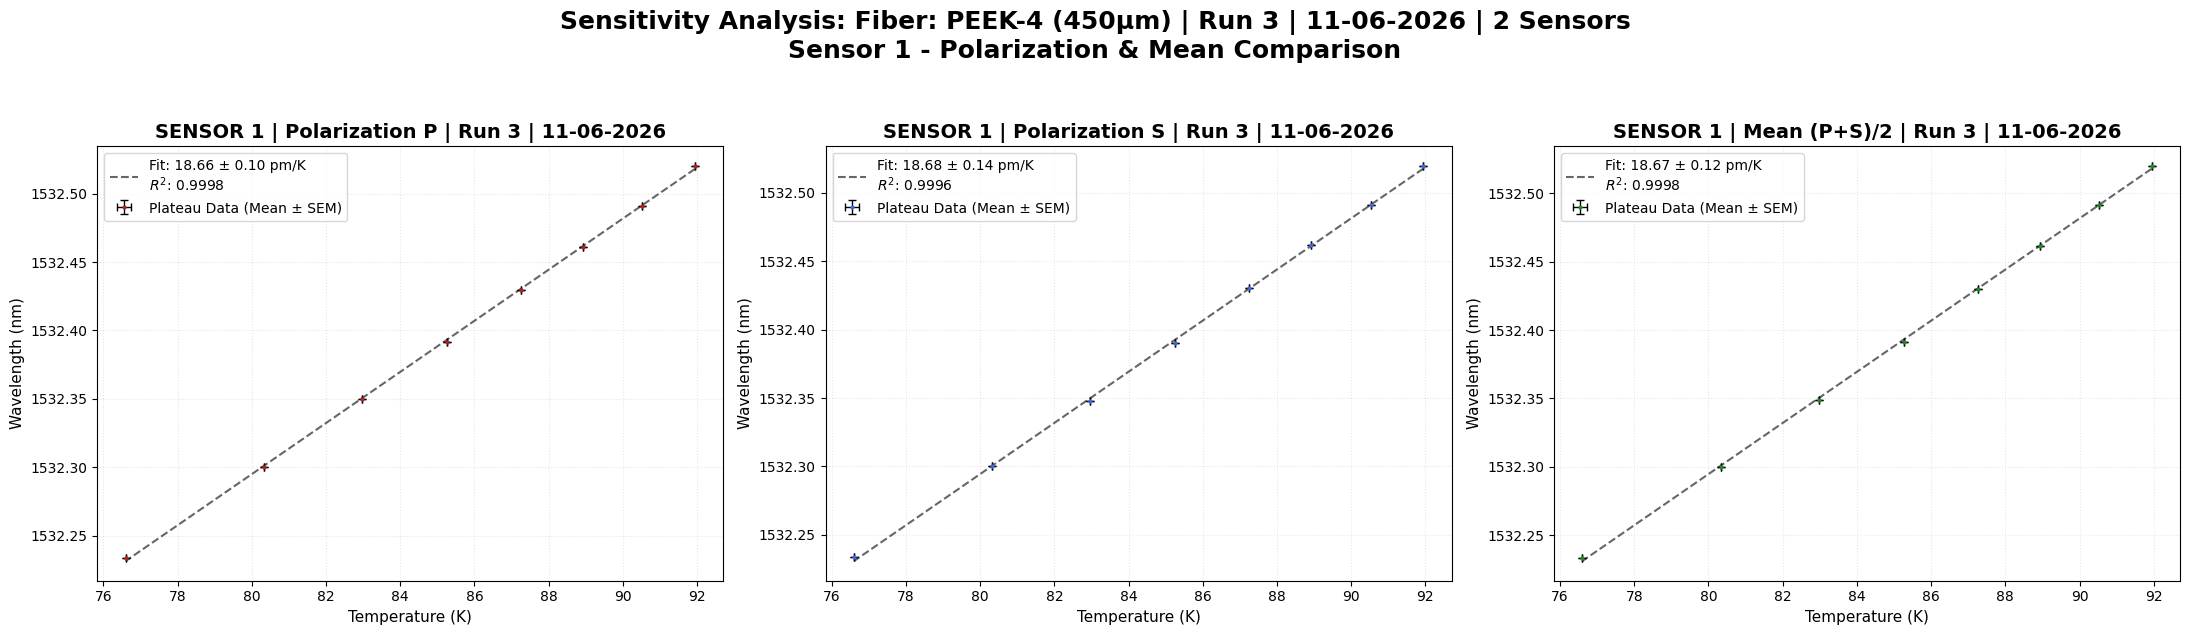

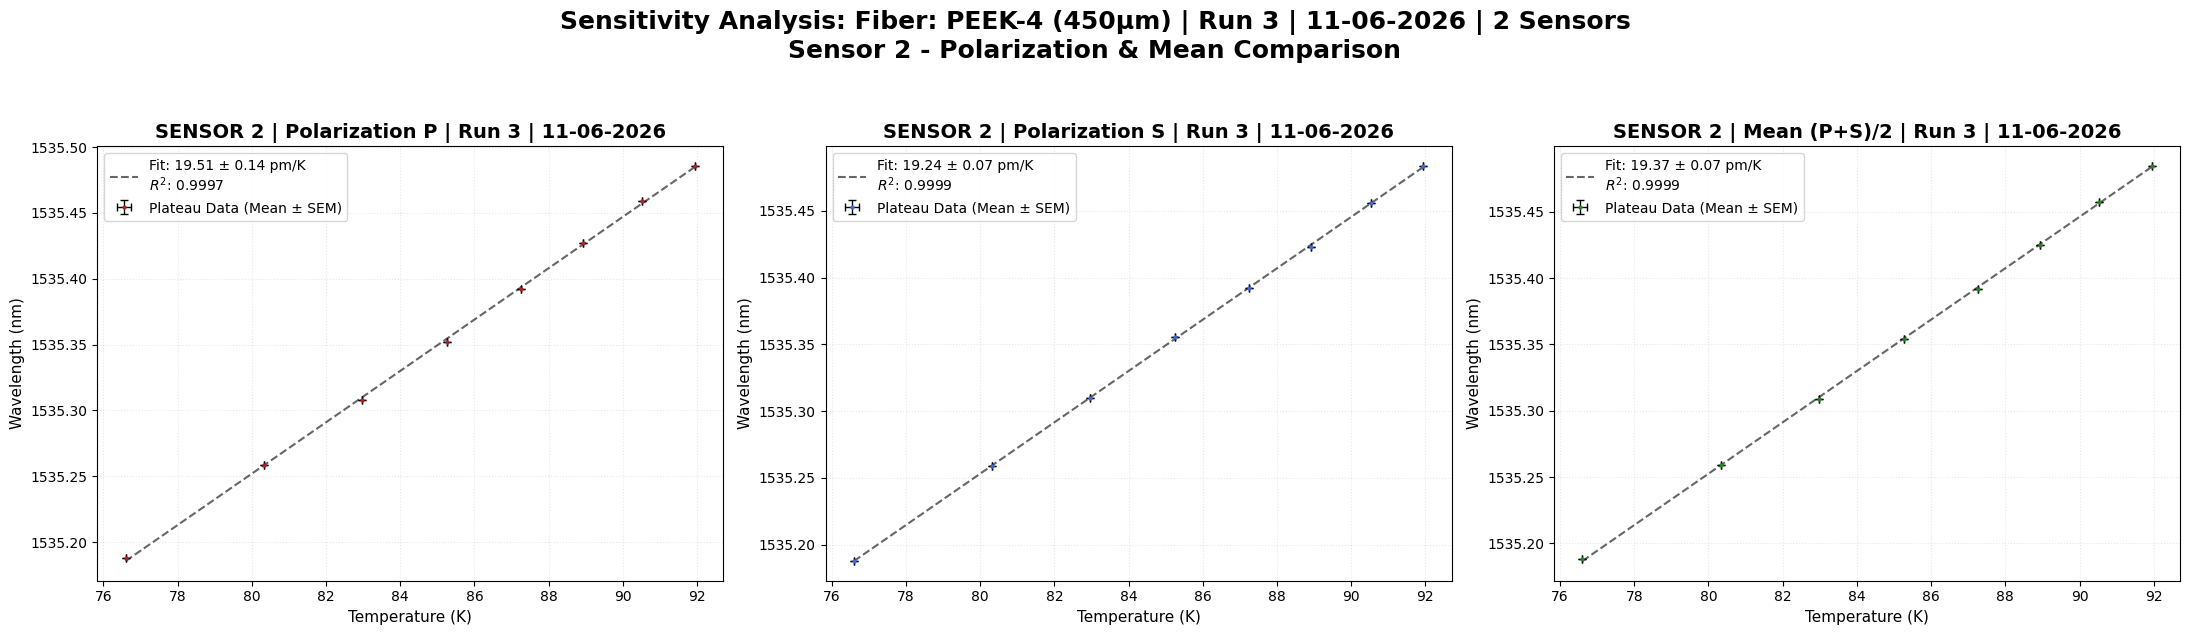


                  SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 3, 11-06-2026)                  
Sensor ID    | Measurement Type     | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
Sensor 1     | Polarization P       |       18.658       |        0.102    | 0.9998
Sensor 1     | Polarization S       |       18.681       |        0.143    | 0.9996
Sensor 1     | Mean (P+S)/2         |       18.669       |        0.118    | 0.9998
Sensor 2     | Polarization P       |       19.506       |        0.144    | 0.9997
Sensor 2     | Polarization S       |       19.238       |        0.071    | 0.9999
Sensor 2     | Mean (P+S)/2         |       19.372       |        0.074    | 0.9999


In [19]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber PEEK-4 | 2 Sensors | 11-06-2026
# Includes Slope Error in Legend, Summary Table and Explicit Sensor Labels
# UPDATED: Error bars now represent Standard Error of the Mean (SEM)
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Data structure to store results for the final summary table
summary_results = []

# Fiber and Run information for titles
fiber_info = "Fiber: PEEK-4 (450µm) | Run 3 | 11-06-2026 | 2 Sensors"

for sensor_num in [1, 2]:
    # Create a separate figure for each sensor with 3 subplots (P, S, Mean)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=False)
    
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Polarization P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Polarization S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for idx, config in enumerate(plot_configs):
        ax = axes[idx]
        label = config["key"]
        
        t_means, t_stds, w_means, w_stds = [], [], [], []
        
        # 1. Collect statistics for each plateau
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                # Extract wavelength data first to know the sample size (N) for SEM
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    n_samples = len(wav_data)
                    
                    if n_samples > 1: # SEM calculation requires at least 2 points
                        w_means.append(np.mean(wav_data))
                        w_stds.append(stats.sem(wav_data)) # Vertical Error (SEM)
                    else:
                        w_means.append(np.nan)
                        w_stds.append(np.nan)
                else:
                    n_samples = 1
                    w_means.append(np.nan)
                    w_stds.append(np.nan)

                # Temperature stats (Horizontal Error) -> Converted to SEM
                t_means.append(p["temp_mean"])
                t_stds.append(p["temp_std"] / np.sqrt(n_samples) if n_samples > 0 else np.nan)

            # Convert to arrays and filter NaNs
            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_stds); y_err = np.array(w_stds)
            
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                # 2. Linear Regression and Slope Error calculation
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                
                # Convert results to pm/K for standard reporting
                slope_pm = slope * 1e3
                err_pm = std_err * 1e3
                
                # Store data for the final summary table
                summary_results.append({
                    "Sensor": f"Sensor {sensor_num}",
                    "Type": config["title"],
                    "Slope": slope_pm,
                    "Error": err_pm,
                    "R2": r_val**2
                })

                # 3. Plotting with Error Bars (Updated Legend to SEM)
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=1, markersize=2, capsize=3, label='Plateau Data (Mean ± SEM)')
                
                # Plot Regression Line
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', alpha=0.6,
                        label=f'Fit: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}')

                # 4. SUBPLOT TITLES: Explicit Sensor Identification
                ax.set_title(f"SENSOR {sensor_num} | {config['title']} | Run 3 | 11-06-2026", fontsize=14, fontweight='bold')
                
                # Labels and Style
                ax.set_xlabel("Temperature (K)", fontsize=11)
                ax.set_ylabel("Wavelength (nm)", fontsize=11)
                ax.legend(fontsize=10, loc='best')
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.ticklabel_format(useOffset=False, axis='y')

    # Main Title for the whole sensor figure
    plt.suptitle(f"Sensitivity Analysis: {fiber_info}\nSensor {sensor_num} - Polarization & Mean Comparison", 
                 fontsize=18, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# FINAL SUMMARY TABLE: Results in pm/K
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FIBER PEEK-4 (RUN 3, 11-06-2026)':^95}")
print("="*95)
print(f"{'Sensor ID':<12} | {'Measurement Type':<20} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['Sensor']:<12} | {res['Type']:<20} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")
print("="*95)

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

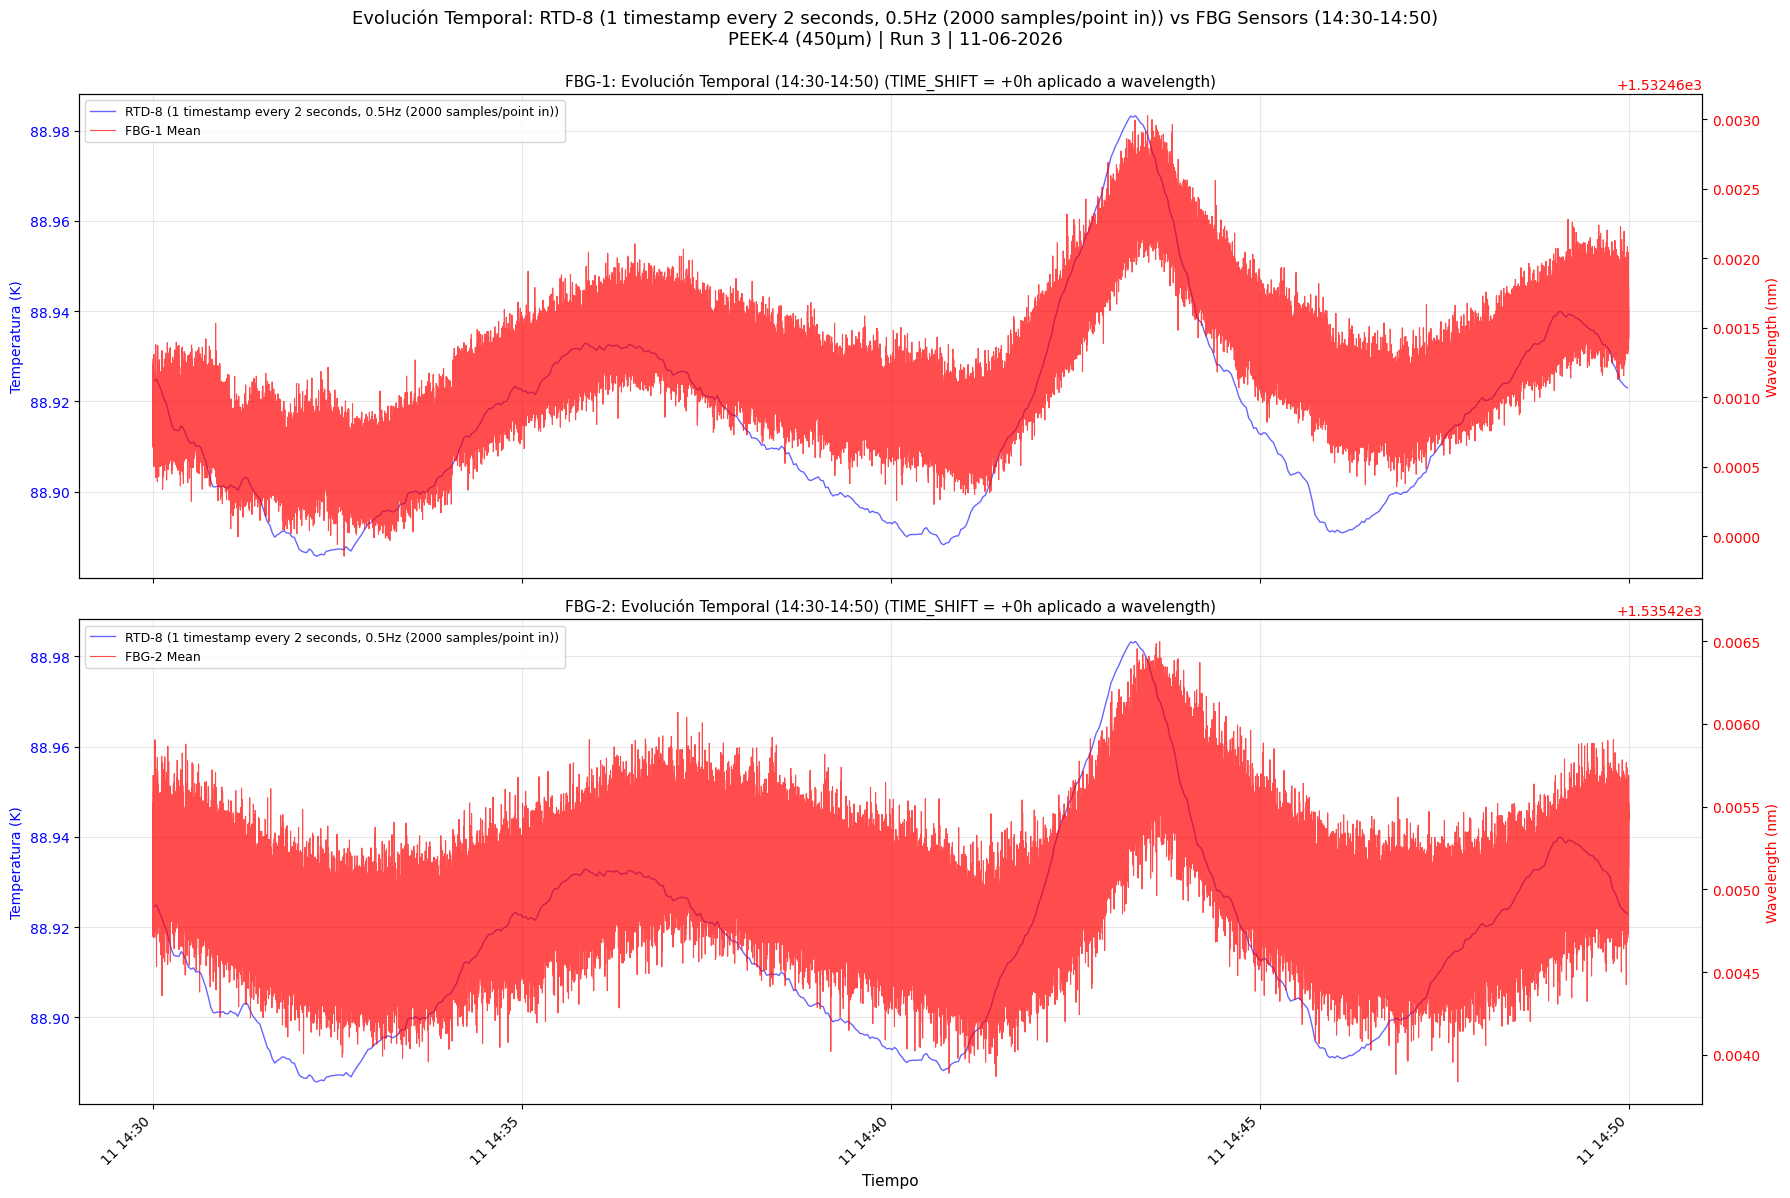


📊 Rango temporal mostrado: (14:30-14:50)
   Temperatura: 2026-06-11 14:30 - 14:49
   Wavelength (con +0h shift): 2026-06-11 14:30 - 14:49

💡 Este gráfico muestra el TIME_SHIFT de 0 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [20]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(14, 50))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 3 | 11-06-2026', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

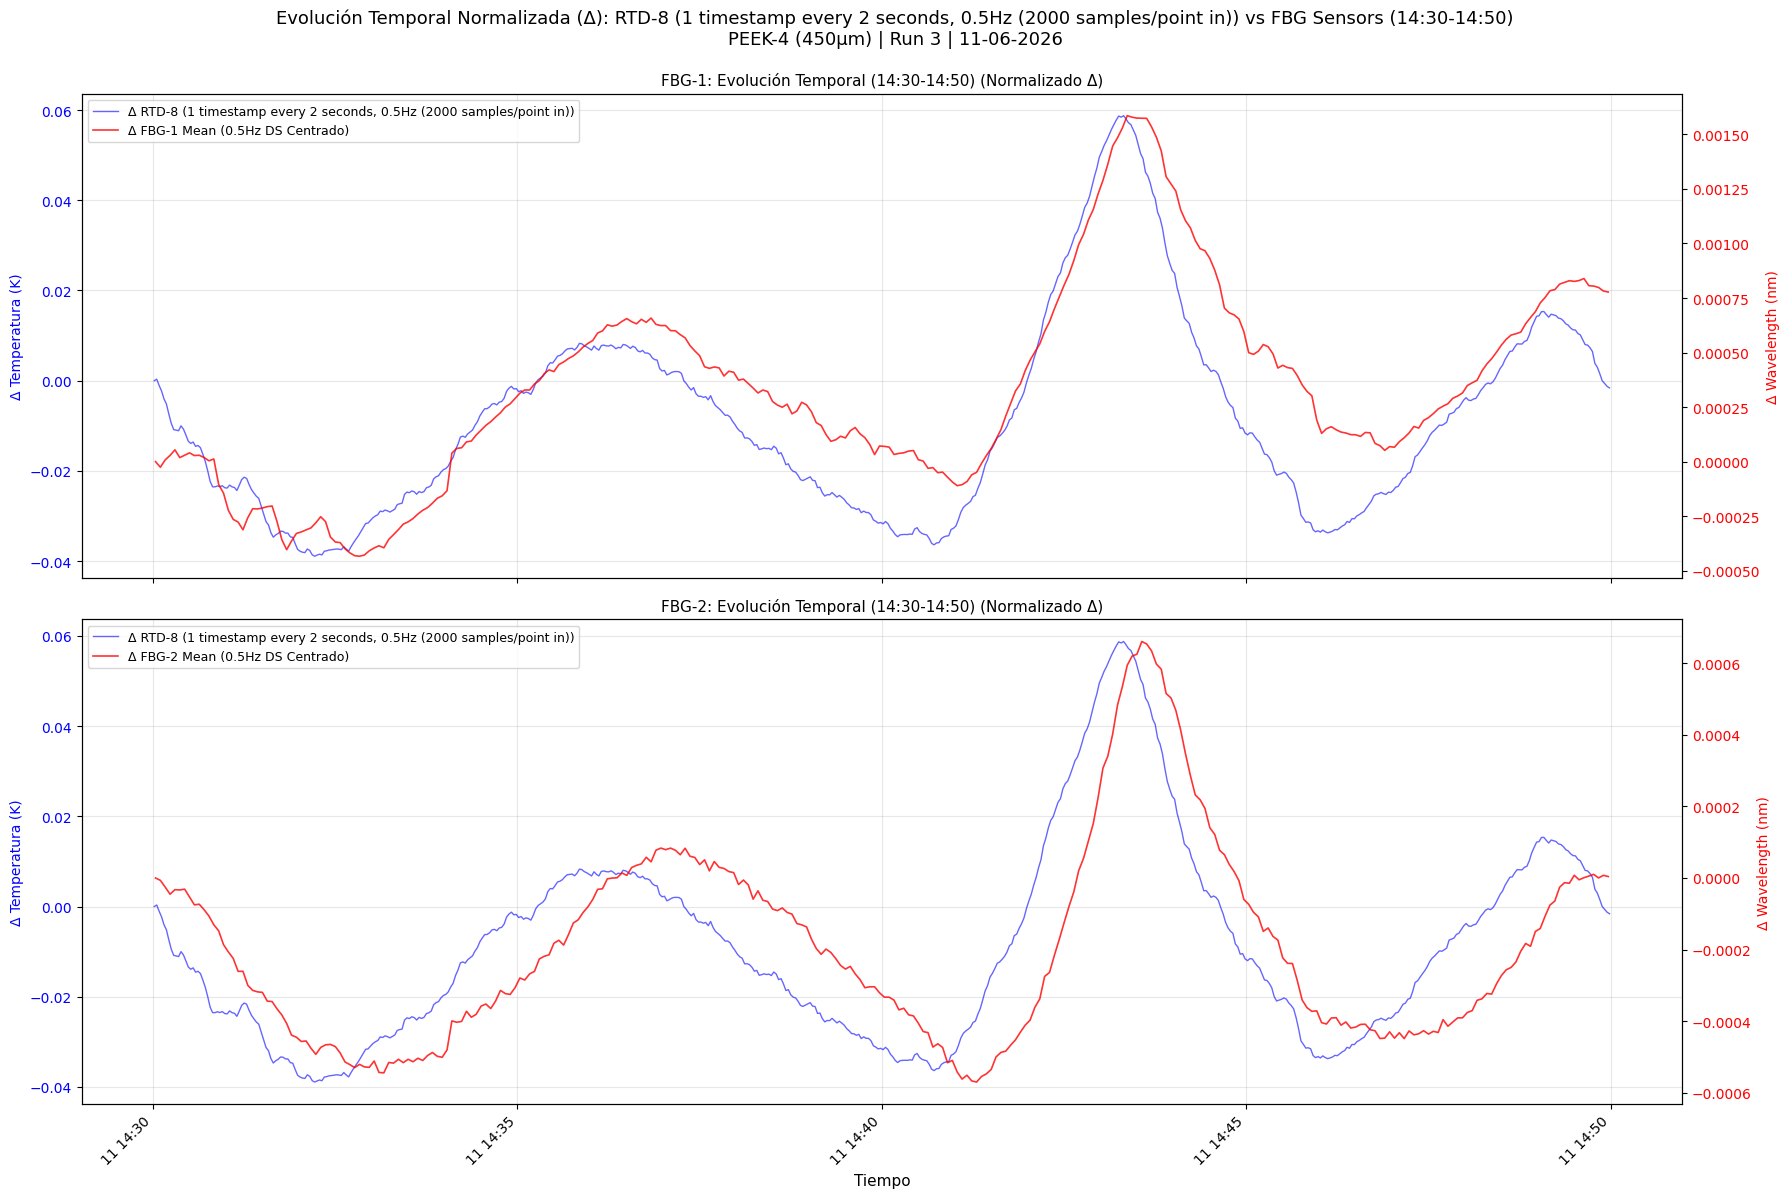


📊 Rango temporal mostrado: (14:30-14:50)
   Temperatura: 2026-06-11 14:30:01 - 14:49:59
   Wavelength (con +0h shift): 2026-06-11 14:30:00 - 14:49:59

💡 Este gráfico muestra señales normalizadas (Δ) y con Downsampling centrado a 0.5Hz en FBG.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [21]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(14, 50))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# NORMALIZACIÓN RTD: Calcular Delta T (Restar el valor inicial)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp = temp_plot - temp_baseline

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)
half_ds_factor = ds_factor // 2   # Índice central del bloque

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL CENTRADO (Timestamp en el centro del bloque)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del CENTRO de la ventana.
        times_p_plot_ds = times_p_plot[half_ds_factor : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    # NORMALIZACIÓN FBG: Calcular Delta Wavelength (Restar el valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav = wav_mean_plot_ds - wav_baseline
    
    ax = axes[idx]
    
    # Plot temperatura normalizada (Delta)
    ax.plot(times_temp_plot, delta_temp, 'b-', linewidth=1.0, alpha=0.6, label=f'Δ {rtd_ref_name}')
    ax.set_ylabel('Δ Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength normalizada en eje secundario (Delta + DS)
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, delta_wav, 'r-', linewidth=1.2, alpha=0.8, label=f'Δ FBG-{sensor_num} Mean (0.5Hz DS Centrado)')
    ax2.set_ylabel('Δ Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Normalizado Δ)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal Normalizada (Δ): {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 3 | 11-06-2026', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_temp_plot[-1].strftime('%H:%M:%S')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_p_plot[-1].strftime('%H:%M:%S')}")

print(f"\n💡 Este gráfico muestra señales normalizadas (Δ) y con Downsampling centrado a 0.5Hz en FBG.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

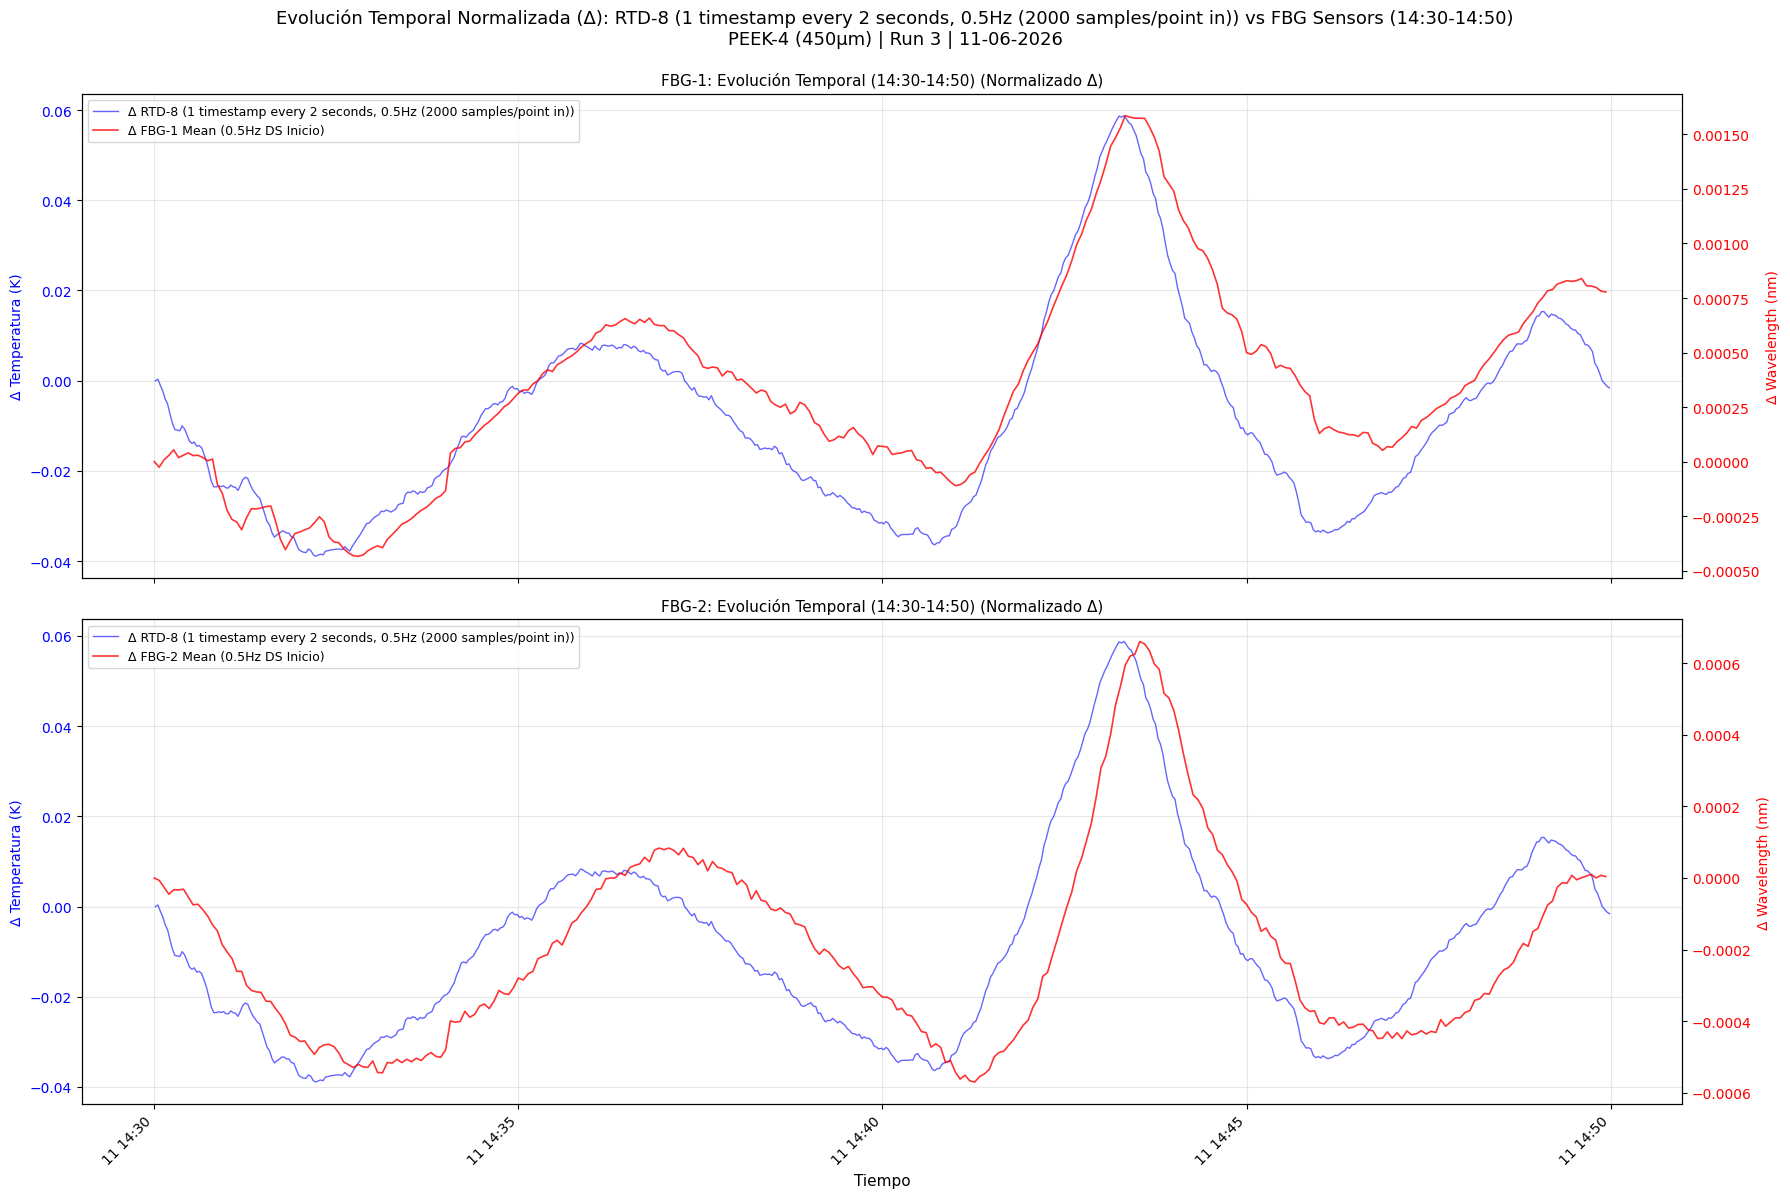


📊 Rango temporal mostrado: (14:30-14:50)
   Temperatura: 2026-06-11 14:30:01 - 14:49:59
   Wavelength (con +0h shift): 2026-06-11 14:30:00 - 14:49:59

💡 Este gráfico muestra señales normalizadas (Δ) y con Downsampling al INICIO del bloque a 0.5Hz en FBG.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [22]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(14, 50))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# NORMALIZACIÓN RTD: Calcular Delta T (Restar el valor inicial)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp = temp_plot - temp_baseline

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL (Timestamp al INICIO del bloque emulando a LabVIEW)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del INICIO de la ventana (índice 0).
        times_p_plot_ds = times_p_plot[0 : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    # NORMALIZACIÓN FBG: Calcular Delta Wavelength (Restar el valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav = wav_mean_plot_ds - wav_baseline
    
    ax = axes[idx]
    
    # Plot temperatura normalizada (Delta)
    ax.plot(times_temp_plot, delta_temp, 'b-', linewidth=1.0, alpha=0.6, label=f'Δ {rtd_ref_name}')
    ax.set_ylabel('Δ Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength normalizada en eje secundario (Delta + DS)
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, delta_wav, 'r-', linewidth=1.2, alpha=0.8, label=f'Δ FBG-{sensor_num} Mean (0.5Hz DS Inicio)')
    ax2.set_ylabel('Δ Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Normalizado Δ)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal Normalizada (Δ): {rtd_ref_name} vs FBG Sensors {range_label}\nPEEK-4 (450µm) | Run 3 | 11-06-2026', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_temp_plot[-1].strftime('%H:%M:%S')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_p_plot[-1].strftime('%H:%M:%S')}")

print(f"\n💡 Este gráfico muestra señales normalizadas (Δ) y con Downsampling al INICIO del bloque a 0.5Hz en FBG.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

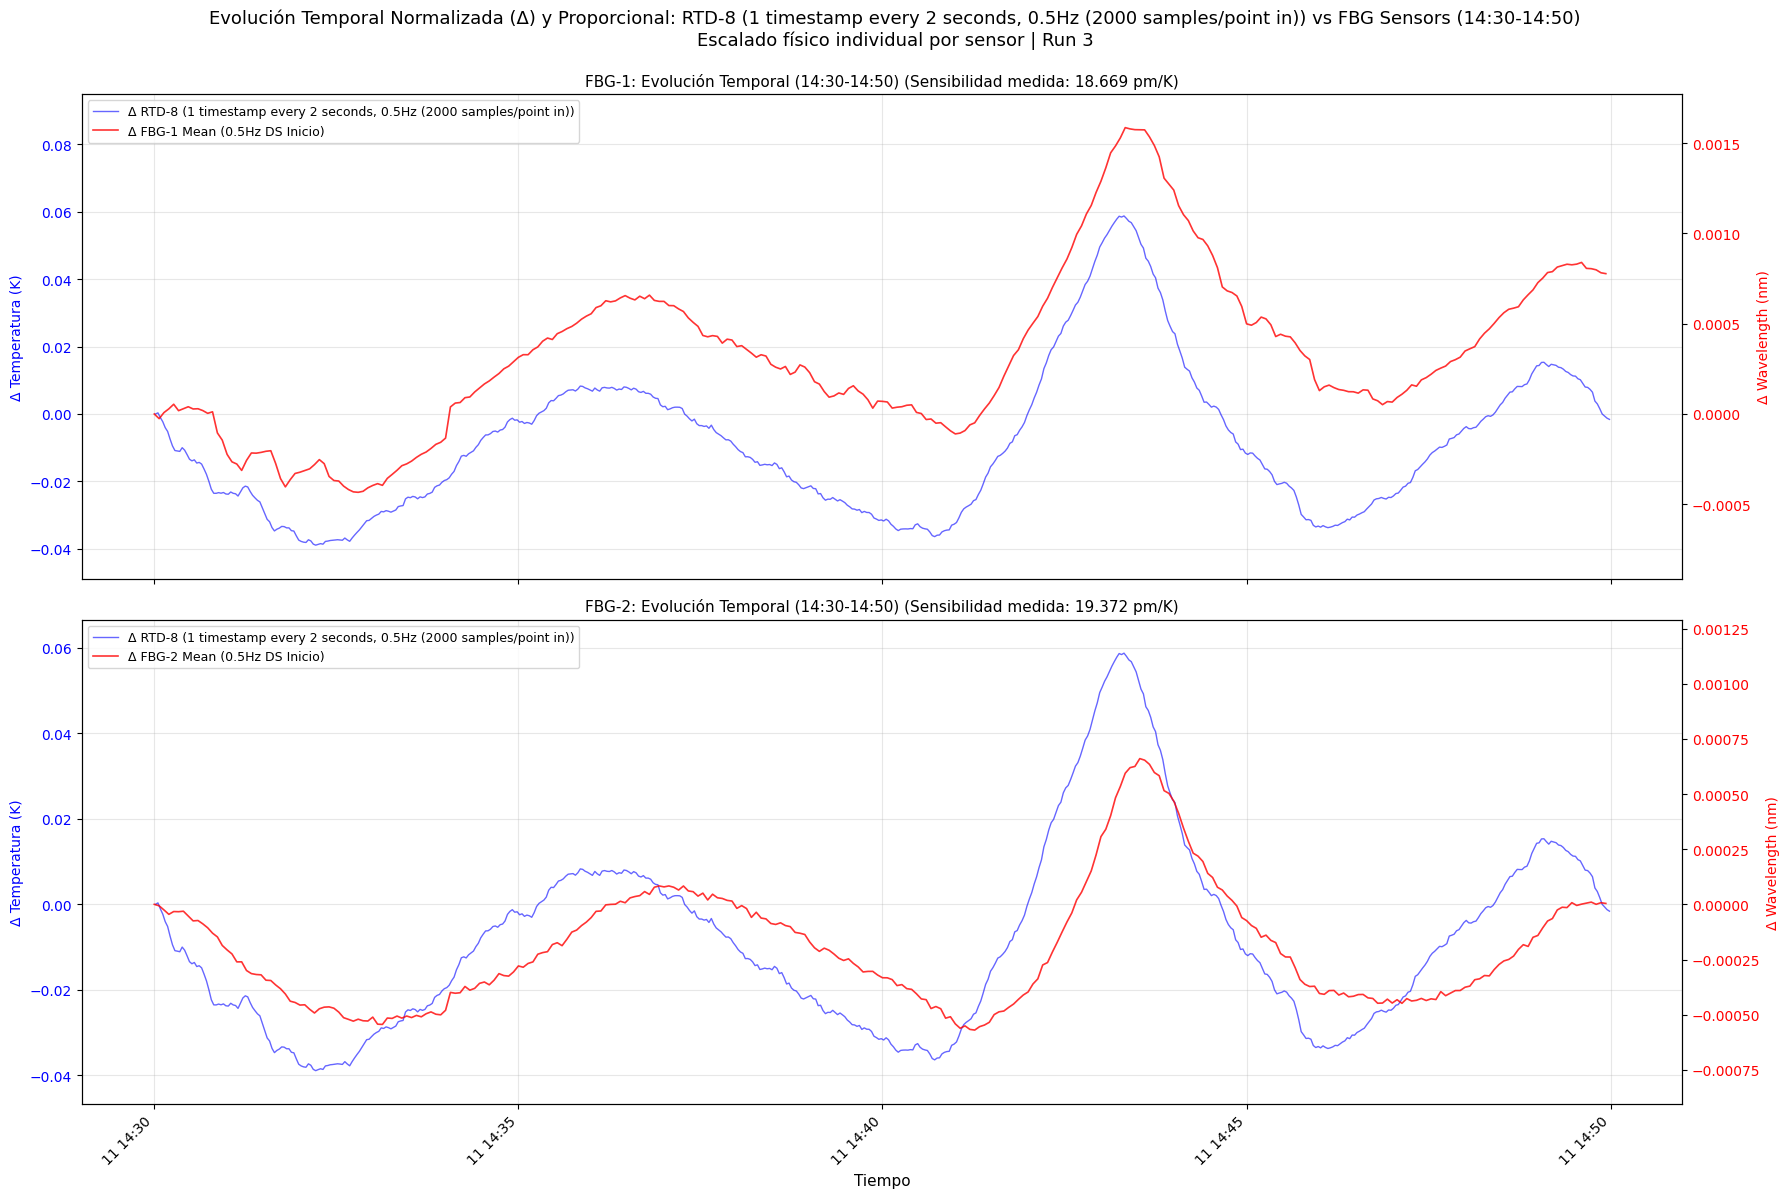


📊 Rango temporal mostrado: (14:30-14:50)
   Temperatura: 2026-06-11 14:30:01 - 14:49:59
   Wavelength (con shift): 2026-06-11 14:30:00 - 14:49:59

💡 Este gráfico tiene las ESCALAS VINCULADAS FÍSICAMENTE por sensor:
   - FBG-1 escalado a 18.669 pm/K
   - FBG-2 escalado a 19.372 pm/K


In [23]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(14, 50))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# NORMALIZACIÓN RTD: Calcular Delta T (Restar el valor inicial)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp = temp_plot - temp_baseline

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)

# ============================================================================
# SENSIBILIDADES INDIVIDUALES MEDIDAS (Mean P+S / 2) en nm/K
# Convertimos de pm/K a nm/K multiplicando por 1e-3
# ============================================================================
fbg_sensitivities_nm_K = {
    1: 18.669 * 1e-3,  # 0.018669 nm/K
    2: 19.372 * 1e-3   # 0.019372 nm/K
}
# ============================================================================

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Obtener sensibilidad específica para este sensor
    fbg_sensitivity_nm_K = fbg_sensitivities_nm_K[sensor_num]
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL (Timestamp al INICIO del bloque emulando a LabVIEW)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del INICIO de la ventana (índice 0).
        times_p_plot_ds = times_p_plot[0 : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    # NORMALIZACIÓN FBG: Calcular Delta Wavelength (Restar el valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav = wav_mean_plot_ds - wav_baseline
    
    ax = axes[idx]
    
    # Plot temperatura normalizada (Delta)
    ax.plot(times_temp_plot, delta_temp, 'b-', linewidth=1.0, alpha=0.6, label=f'Δ {rtd_ref_name}')
    ax.set_ylabel('Δ Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength normalizada en eje secundario (Delta + DS)
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, delta_wav, 'r-', linewidth=1.2, alpha=0.8, label=f'Δ FBG-{sensor_num} Mean (0.5Hz DS Inicio)')
    ax2.set_ylabel('Δ Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # ----------------------------------------------------------------------
    # VINCULACIÓN FÍSICA INTELIGENTE DE ESCALAS (¡Sin recortar curvas!)
    # Convertimos la señal de longitud de onda a temperatura equivalente (K)
    # dividiendo por su sensibilidad medida.
    fbg_temp_equivalent = delta_wav / fbg_sensitivity_nm_K
    
    # Encontramos los límites mínimos y máximos globales considerando AMBAS señales
    t_min = min(np.min(delta_temp), np.min(fbg_temp_equivalent))
    t_max = max(np.max(delta_temp), np.max(fbg_temp_equivalent))
    
    # Añadimos un pequeño margen de cortesía (8%) para que las curvas respiren
    t_range = t_max - t_min
    margin = 0.08 * t_range if t_range > 0 else 0.1
    ylim_min = t_min - margin
    ylim_max = t_max + margin
    
    # Forzamos los límites de ambos ejes vinculados por la sensibilidad física
    ax.set_ylim(ylim_min, ylim_max)
    ax2.set_ylim(ylim_min * fbg_sensitivity_nm_K, ylim_max * fbg_sensitivity_nm_K)
    # ----------------------------------------------------------------------
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Sensibilidad medida: {fbg_sensitivity_nm_K*1e3:.3f} pm/K)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal Normalizada (Δ) y Proporcional: {rtd_ref_name} vs FBG Sensors {range_label}\nEscalado físico individual por sensor | Run 3', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_temp_plot[-1].strftime('%H:%M:%S')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength (con shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_p_plot[-1].strftime('%H:%M:%S')}")

print(f"\n💡 Este gráfico tiene las ESCALAS VINCULADAS FÍSICAMENTE por sensor:")
print(f"   - FBG-1 escalado a {fbg_sensitivities_nm_K[1]*1e3:.3f} pm/K")
print(f"   - FBG-2 escalado a {fbg_sensitivities_nm_K[2]*1e3:.3f} pm/K")

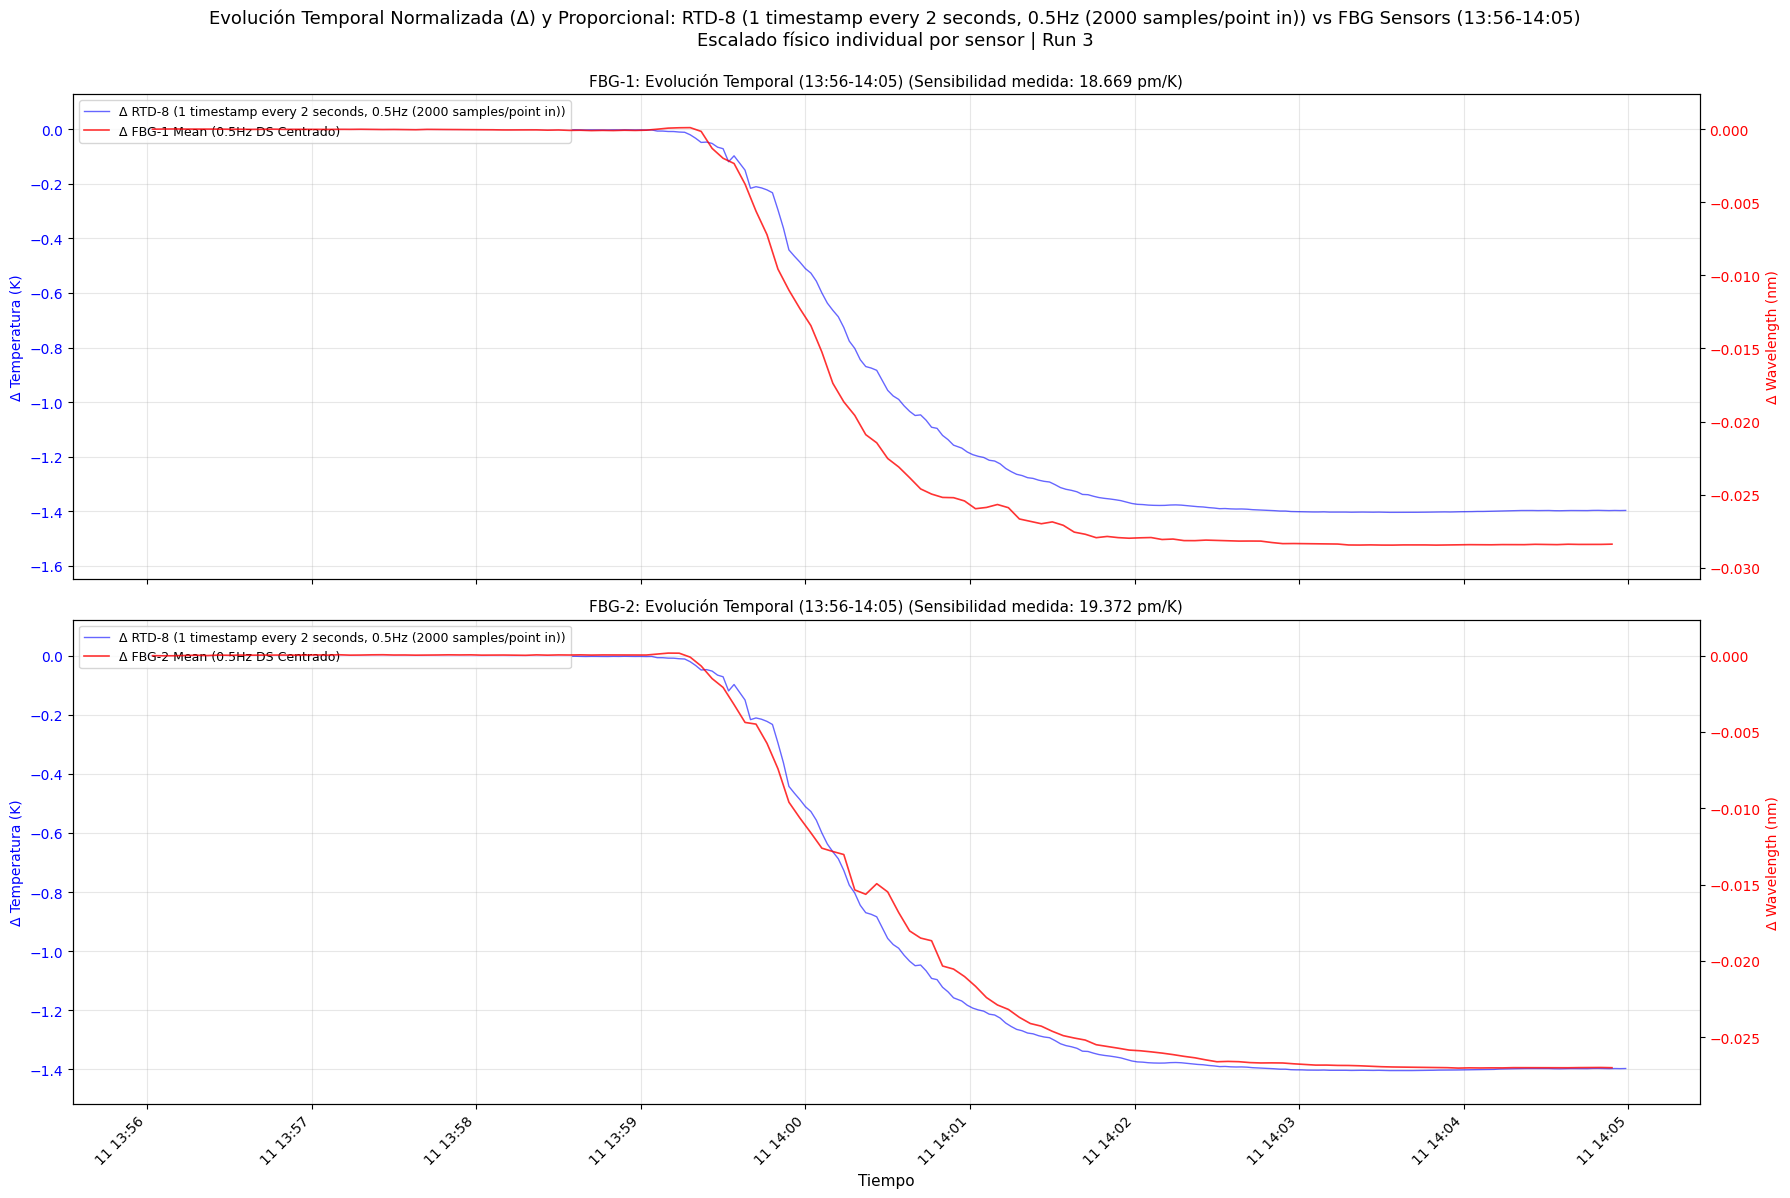


📊 Rango temporal mostrado: (13:56-14:05)
   Temperatura: 2026-06-11 13:56:00 - 14:04:59
   Wavelength (con shift): 2026-06-11 13:56:00 - 14:04:59

💡 Este gráfico tiene las ESCALAS VINCULADAS FÍSICAMENTE por sensor:
   - FBG-1 escalado a 18.669 pm/K
   - FBG-2 escalado a 19.372 pm/K


In [24]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(13, 56))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(14, 5))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# NORMALIZACIÓN RTD: Calcular Delta T (Restar el valor inicial)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp = temp_plot - temp_baseline

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)
half_ds_factor = ds_factor // 2   # Índice central del bloque (250 puntos)

# ============================================================================
# SENSIBILIDADES INDIVIDUALES MEDIDAS (Mean P+S / 2) en nm/K
# Convertimos de pm/K a nm/K multiplicando por 1e-3
# ============================================================================
fbg_sensitivities_nm_K = {
    1: 18.669 * 1e-3,  # 0.018669 nm/K
    2: 19.372 * 1e-3   # 0.019372 nm/K
}
# ============================================================================

for idx, sensor_num in enumerate([1, 2]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Obtener sensibilidad específica para este sensor
    fbg_sensitivity_nm_K = fbg_sensitivities_nm_K[sensor_num]
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2 (Señal en crudo a 250Hz)
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    # ----------------------------------------------------------------------
    # DOWNSAMPLING MANUAL CENTRADO (Timestamp en el medio de la ventana)
    # ----------------------------------------------------------------------
    num_blocks = len(wav_mean_plot) // ds_factor
    
    if num_blocks > 0:
        # 1. Agrupamos los datos en bloques de 500 y calculamos la media
        wav_mean_plot_ds = np.mean(wav_mean_plot[:num_blocks*ds_factor].reshape(-1, ds_factor), axis=1)
        # 2. Tomamos el timestamp del CENTRO de la ventana (half_ds_factor).
        times_p_plot_ds = times_p_plot[half_ds_factor : num_blocks*ds_factor : ds_factor]
    else:
        # Fallback de seguridad
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot
    # ----------------------------------------------------------------------
    
    # NORMALIZACIÓN FBG: Calcular Delta Wavelength (Restar el valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav = wav_mean_plot_ds - wav_baseline
    
    ax = axes[idx]
    
    # Plot temperatura normalizada (Delta)
    ax.plot(times_temp_plot, delta_temp, 'b-', linewidth=1.0, alpha=0.6, label=f'Δ {rtd_ref_name}')
    ax.set_ylabel('Δ Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength normalizada en eje secundario (Delta + DS)
    ax2 = ax.twinx()
    ax2.plot(times_p_plot_ds, delta_wav, 'r-', linewidth=1.2, alpha=0.8, label=f'Δ FBG-{sensor_num} Mean (0.5Hz DS Centrado)')
    ax2.set_ylabel('Δ Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # ----------------------------------------------------------------------
    # VINCULACIÓN FÍSICA INTELIGENTE DE ESCALAS (¡Sin recortar curvas!)
    # Convertimos la señal de longitud de onda a temperatura equivalente (K)
    # dividiendo por su sensibilidad medida.
    fbg_temp_equivalent = delta_wav / fbg_sensitivity_nm_K
    
    # Encontramos los límites mínimos y máximos globales considerando AMBAS señales
    t_min = min(np.min(delta_temp), np.min(fbg_temp_equivalent))
    t_max = max(np.max(delta_temp), np.max(fbg_temp_equivalent))
    
    # Añadimos un pequeño margen de cortesía (8%) para que las curvas respiren
    t_range = t_max - t_min
    margin = 0.08 * t_range if t_range > 0 else 0.1
    ylim_min = t_min - margin
    ylim_max = t_max + margin
    
    # Forzamos los límites de ambos ejes vinculados por la sensibilidad física
    ax.set_ylim(ylim_min, ylim_max)
    ax2.set_ylim(ylim_min * fbg_sensitivity_nm_K, ylim_max * fbg_sensitivity_nm_K)
    # ----------------------------------------------------------------------
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (Sensibilidad medida: {fbg_sensitivity_nm_K*1e3:.3f} pm/K)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal Normalizada (Δ) y Proporcional: {rtd_ref_name} vs FBG Sensors {range_label}\nEscalado físico individual por sensor | Run 3', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_temp_plot[-1].strftime('%H:%M:%S')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength (con shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M:%S')} - {times_p_plot[-1].strftime('%H:%M:%S')}")

print(f"\n💡 Este gráfico tiene las ESCALAS VINCULADAS FÍSICAMENTE por sensor:")
print(f"   - FBG-1 escalado a {fbg_sensitivities_nm_K[1]*1e3:.3f} pm/K")
print(f"   - FBG-2 escalado a {fbg_sensitivities_nm_K[2]*1e3:.3f} pm/K")

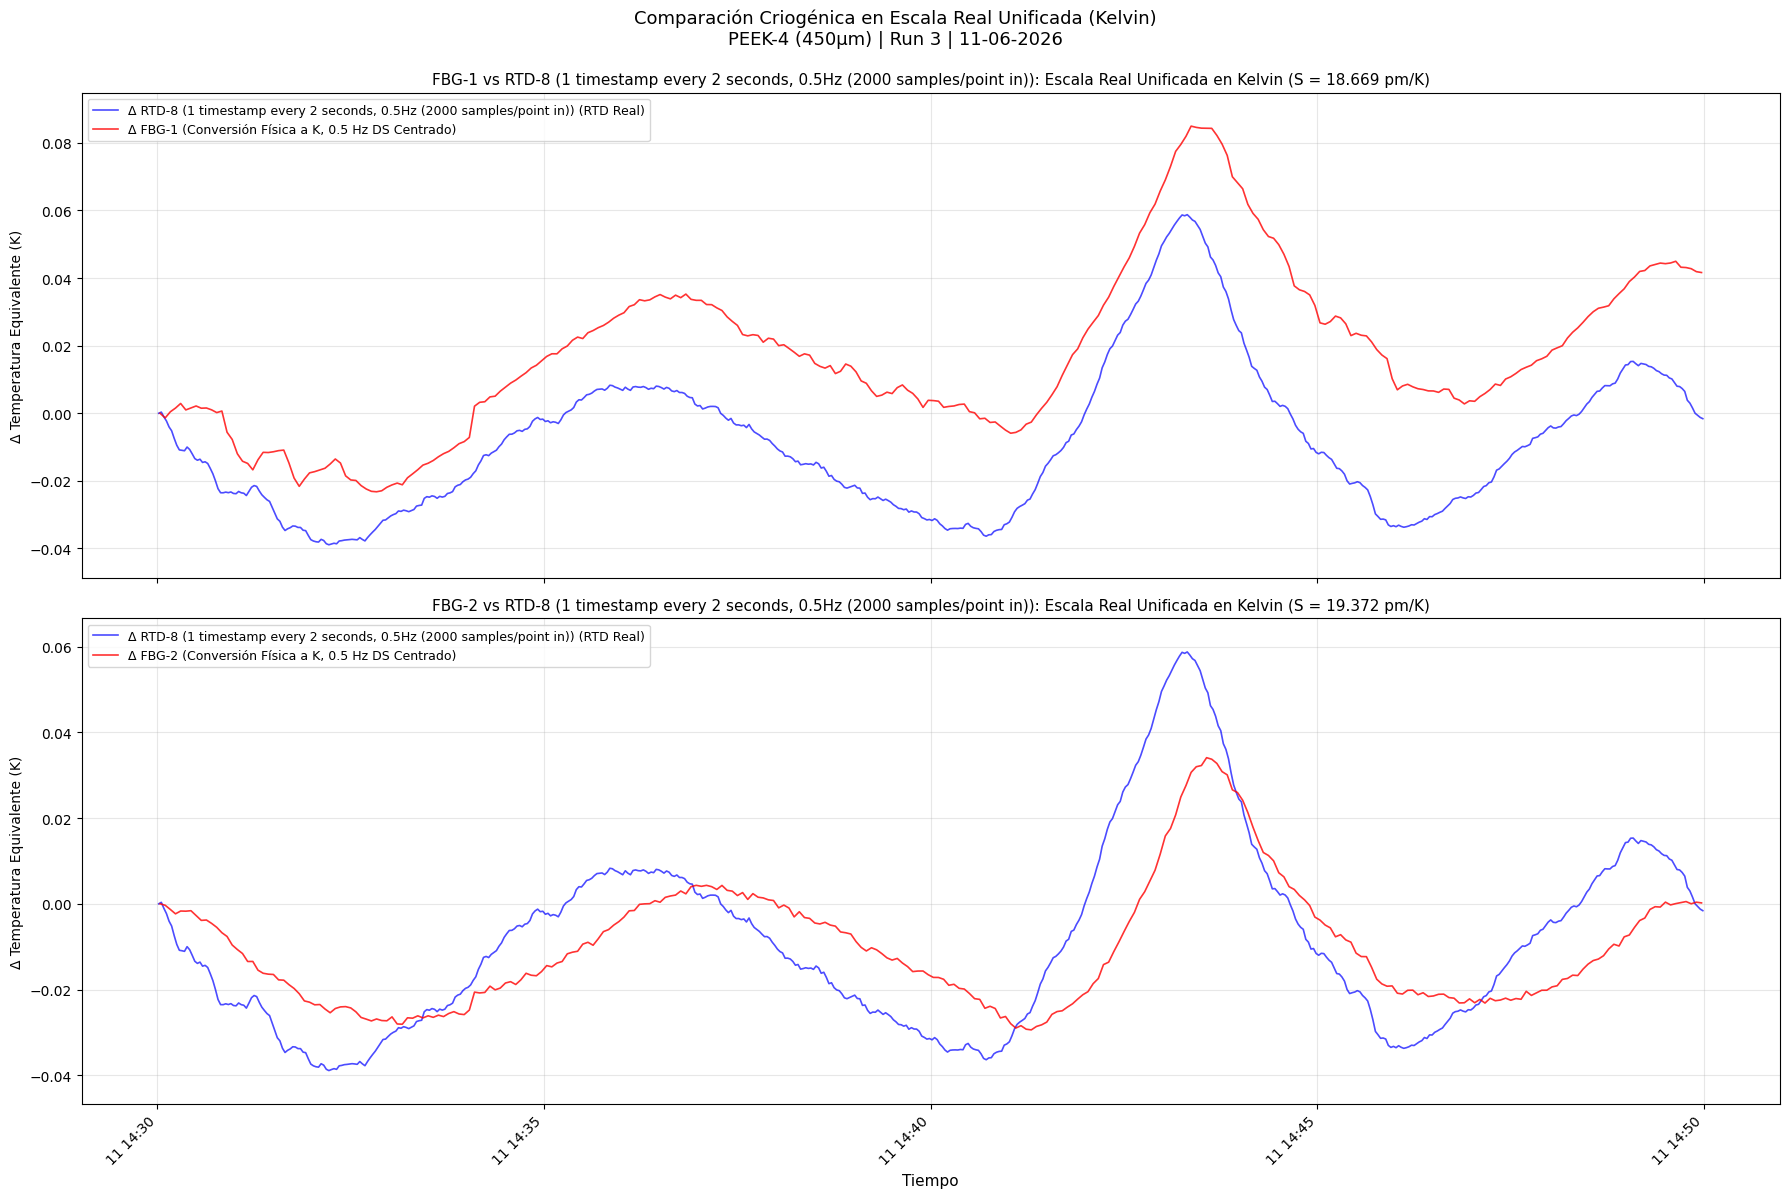

In [25]:
import datetime
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(14, 50))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"

# ============================================================================
# PARÁMETROS FÍSICOS REALES (Calibración)
# ============================================================================
# Sensibilidades medidas en nm/K (Convertidas de pm/K multiplicando por 1e-3)
fbg_sensitivities_nm_K = {
    1: 18.669 * 1e-3,  # 0.018669 nm/K
    2: 19.372 * 1e-3,  # 0.019372 nm/K
}

# Parámetros para el Downsampling
fbg_hz = 250
rtd_hz = 0.5
ds_factor = int(fbg_hz / rtd_hz)  # 500 puntos (2 segundos de datos)
half_ds_factor = ds_factor // 2  # Índice central para el centrado a 0.5 Hz

# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# 1. PROCESAR Y FILTRAR RTD DE REFERENCIA
temp_raw_valid_mask = (
    (temp_raw[:, rtd_ref_idx] > 0)
    & (times_temp >= t_plot_inicio)
    & (times_temp <= t_plot_fin)
)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

# Delta T del RTD (Restamos el valor inicial para que empiece en 0)
temp_baseline = temp_plot[0] if len(temp_plot) > 0 else 0
delta_temp_K = temp_plot - temp_baseline

# 2. PROCESAR CADA SENSOR FBG CON CONVERSIÓN FÍSICA A KELVIN
for idx, sensor_num in enumerate([1, 2]):
    fbg_sensitivity_nm_K = fbg_sensitivities_nm_K[sensor_num]

    # Extraer datos RAW completos del sensor óptico
    sensor_idx = sensor_num - 1
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]

    # Filtrar por rango temporal
    mask_p = (
        (wav_p_full > 0)
        & (times_peak >= t_plot_inicio)
        & (times_peak <= t_plot_fin)
    )
    mask_s = (
        (wav_s_full > 0)
        & (times_peak >= t_plot_inicio)
        & (times_peak <= t_plot_fin)
    )

    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]

    # Interpolar polarización S al vector de tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)

    # Media de polarizaciones (P+S)/2 a 250 Hz
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0

    # Downsampling centrado a 0.5 Hz (1 dato cada 2 segundos)
    num_blocks = len(wav_mean_plot) // ds_factor
    if num_blocks > 0:
        wav_mean_plot_ds = np.mean(
            wav_mean_plot[: num_blocks * ds_factor].reshape(-1, ds_factor),
            axis=1,
        )
        times_p_plot_ds = times_p_plot[
            half_ds_factor : num_blocks * ds_factor : ds_factor
        ]
    else:
        wav_mean_plot_ds = wav_mean_plot
        times_p_plot_ds = times_p_plot

    # Delta Wavelength de la FBG (Restamos valor inicial)
    wav_baseline = wav_mean_plot_ds[0] if len(wav_mean_plot_ds) > 0 else 0
    delta_wav_nm = wav_mean_plot_ds - wav_baseline

    # ----------------------------------------------------------------------
    # EL CAMBIO CLAVE: CONVERSIÓN FÍSICA ESTRICTA A KELVIN EQUIVALENTES
    # ----------------------------------------------------------------------
    # Dividimos los nanómetros por la sensibilidad real para pasarlo a Kelvin.
    # NO se estira de forma arbitraria, mantiene la proporción física real.
    fbg_temp_equivalent_K = delta_wav_nm / fbg_sensitivity_nm_K
    # ----------------------------------------------------------------------

    ax = axes[idx]

    # Graficar ambas señales juntas en el MISMO EJE Y (Unidades: Kelvin)
    ax.plot(
        times_temp_plot,
        delta_temp_K,
        "b-",
        linewidth=1.2,
        alpha=0.7,
        label=f"Δ {rtd_ref_name} (RTD Real)",
    )
    ax.plot(
        times_p_plot_ds,
        fbg_temp_equivalent_K,
        "r-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Δ FBG-{sensor_num} (Conversión Física a K, 0.5 Hz DS Centrado)",
    )

    # Configuración de ejes unificados
    ax.set_ylabel("Δ Temperatura Equivalente (K)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

    # Definir límites dinámicos automáticos pero compartidos para que no se recorte nada
    all_values = np.concatenate([delta_temp_K, fbg_temp_equivalent_K])
    y_min, y_max = np.min(all_values), np.max(all_values)
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.08 * y_range)

    ax.set_title(
        f"FBG-{sensor_num} vs {rtd_ref_name}: Escala Real Unificada en Kelvin (S = {fbg_sensitivity_nm_K*1e3:.3f} pm/K)",
        fontsize=11,
    )

# Configurar eje X
axes[-1].set_xlabel("Tiempo", fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.suptitle(
    f"Comparación Criogénica en Escala Real Unificada (Kelvin)\nPEEK-4 (450µm) | Run 3 | 11-06-2026",
    fontsize=13,
    y=0.995,
)
plt.tight_layout()
plt.show()

## 8️⃣ Resumen Final

## 📝 Guía de Uso

### Pasos básicos:
1. **Celda 2**: Cambiar ruta del archivo ROOT
2. **Celda 3**: Ajustar rango horario si es necesario
3. **Celda 6.1**: Seleccionar RTD de referencia
4. **Celda 6.2**: Visualizar perfiles Temp-Wavelength para identificar plateaus
5. **Celda 6.3**: Definir plateaus manuales con intervalos temporales
6. **Ejecutar todo**: Run All

### Configuración:
- **RTD referencia**: Celda 6.1 → `rtd_ref_idx` (6 = RTD-6 "Cápsula")
- **Plateaus**: Celda 6.3 → editar `manual_plateaus` con intervalos estables
- **Rango temporal**: Celda 3 → `t_inicio`, `t_fin`

### Método de plateaus:
El análisis calcula sensibilidades usando **plateaus manuales**:
1. Identificar intervalos donde temperatura es estable (visualizar en 6.2)
2. Definir intervalos temporales en formato "HH:MM" (celda 6.3)
3. Calcular μ±σ de temperatura y wavelength en cada plateau
4. Sensibilidad = pendiente del ajuste lineal con barras de error

### Output:
- **Sección 5**: Gráficos de temperatura (8 RTDs) y wavelengths (FBG-1,2,3)
- **Sección 6.2**: Visualización Temp-Wavelength superpuesta
- **Sección 6.3-6.4**: Estadísticas de plateaus (μ±σ)
- **Sección 6.5**: Gráficos de sensibilidad con error bars y R²
- **Sección 8**: Resumen con sensibilidades en pm/K

### Ejemplo de plateaus:
```python
manual_plateaus = [
    ("Plateau 1", "16:55", "17:01"),
    ("Plateau 2", "17:05", "17:12"),
    ("Plateau 3", "17:16", "17:21"),
    ("Plateau 4", "17:26", "17:35"),
]
```

**Nota**: FBG-4 excluido por falla del sensor (status=0 en adquisición).

## 📊 **Plot: Espectro Individual en Tiempo Específico**

Visualiza el espectro completo de un sensor FBG en un instante temporal determinado. Útil para analizar la forma del pico, FWHM, y calidad de la medición.

📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (PEEK-4, 09/06/2026)

✅ Tree 'spectrum' encontrado
   Ramas disponibles: ['t', 'wav']

📊 Estructura de datos:
   't': shape=(1, 2), dtype=float64
   'wav': shape=(1, 2, 1, 39200), dtype=float64

   Detalle de 'wav' (espectros completos):
      Shape: (1, 2, 1, 39200)
      → Dimensiones: (n_entries=1, dim1=2, dim2=1, n_points=39200)

   ⏰ Timestamps ('t'):
      Shape: (1, 2)
      Primeros valores: [1.78117368e+09 1.78117368e+09]

🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
   ✅ Usando timestamps de 'spectrum.t'
   Timestamps shape: (30, 2) → usando columna 0
   Tiempo objetivo:     2026-06-11 15:15:00
   Tiempo más cercano:  2026-06-11 12:28:56
   Diferencia:          9963.0 segundos
   Índice del evento:   29

📊 Datos cargados del tree 'spectrum':
   Shape raw: (1, 2, 1, 39200)
   → Estructura 4D detectada, extrayendo primera entrada: (2, 1, 39200)

📊 Datos del evento listo para procesar:
   Shape final: (2, 1, 39200)
   Tamaño tot

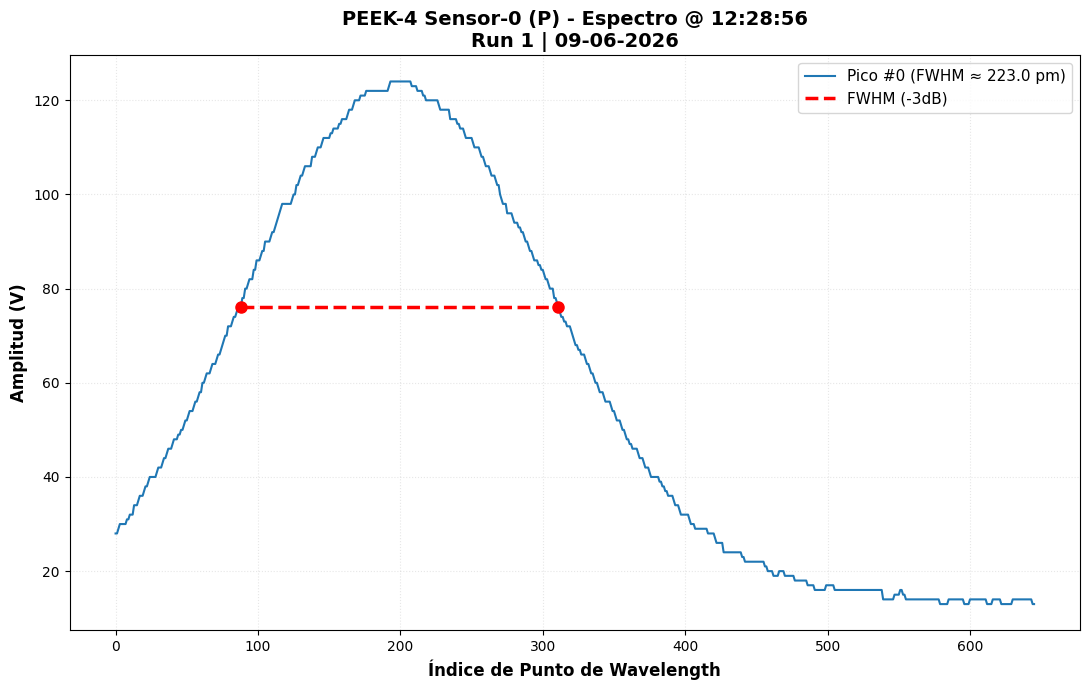


✅ Plot generado exitosamente


In [26]:
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTRO INDIVIDUAL
# ============================================================================

# ⏰ Tiempo a visualizar (aprox. en el primer plateau)
TARGET_TIME = datetime.datetime(2026, 6, 11, 15, 15, 0)  # Ajusta según tu necesidad

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   # Índice del sensor a visualizar
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     # Si hay múltiples picos, cuál visualizar

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# ============================================================================
# PASO 1: Verificar estructura del tree 'spectrum' en el archivo ROOT
# ============================================================================

print("="*80)
print("📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (PEEK-4, 09/06/2026)")
print("="*80)

try:
    with uproot.open(filepath) as file:
        # Verificar que existe el tree 'spectrum'
        if 'spectrum' in file:
            spectrum_tree = file['spectrum']
            print(f"\n✅ Tree 'spectrum' encontrado")
            print(f"   Ramas disponibles: {spectrum_tree.keys()}")
            
            # Leer una muestra pequeña
            sample = spectrum_tree.arrays(library="np", entry_stop=1)
            
            print(f"\n📊 Estructura de datos:")
            for key in sample.keys():
                data = sample[key]
                if hasattr(data, 'shape'):
                    print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
                else:
                    print(f"   '{key}': {type(data)}")
            
            # Verificar estructura de 'wav' (espectros)
            if 'wav' in sample:
                wav_sample = sample['wav']
                if hasattr(wav_sample, 'shape'):
                    print(f"\n   Detalle de 'wav' (espectros completos):")
                    print(f"      Shape: {wav_sample.shape}")
                    if wav_sample.ndim == 4:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]}, n_points={wav_sample.shape[3]})")
                    elif wav_sample.ndim == 3:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, n_points={wav_sample.shape[2]})")
                    elif wav_sample.ndim == 2:
                        print(f"      → Dimensiones: (dim0={wav_sample.shape[0]}, n_points={wav_sample.shape[1]})")
            
            # Verificar timestamps
            if 't' in sample:
                t_sample = sample['t']
                if hasattr(t_sample, 'shape'):
                    print(f"\n   ⏰ Timestamps ('t'):")
                    print(f"      Shape: {t_sample.shape}")
                    if len(t_sample) > 0:
                        print(f"      Primeros valores: {t_sample.flat[:3]}")
                    else:
                        print(f"      (vacío - se usarán timestamps de 'peak')")
        else:
            print(f"\n❌ Tree 'spectrum' NO encontrado en el archivo ROOT")
            print(f"   Trees disponibles: {file.keys()}")

except Exception as e:
    print(f"\n❌ Error verificando estructura: {e}")

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

wav_data = None
spectrum = None
center_idx = None
closest_time = None

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            spectrum_tree = file['spectrum']
            
            # Intentar obtener timestamps - pueden estar en spectrum o en peak
            timestamps_raw = None
            
            try:
                timestamps_raw = spectrum_tree['t'].array(library="np")
                if len(timestamps_raw) == 0:
                    timestamps_raw = None
                else:
                    print("   ✅ Usando timestamps de 'spectrum.t'")
            except:
                pass
            
            if timestamps_raw is None:
                print("   ℹ️  'spectrum.t' vacío o no disponible, usando timestamps de 'peak.t'")
                if 'peak' in file:
                    timestamps_raw = file['peak']['t'].array(library="np")
                else:
                    raise ValueError("No hay timestamps disponibles")
            
            # Procesar según estructura (puede ser 1D o 2D)
            if timestamps_raw.ndim == 2:
                timestamps = timestamps_raw[:, 0]
                print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
            elif timestamps_raw.ndim == 1:
                timestamps = timestamps_raw
                print(f"   Timestamps shape: {timestamps_raw.shape}")
            else:
                print(f"   ⚠️  Estructura inesperada de timestamps: shape={timestamps_raw.shape}")
                timestamps = timestamps_raw.flatten()
            
            if len(timestamps) == 0:
                raise ValueError("No hay timestamps válidos después del procesamiento")
            
            # Convertir TARGET_TIME a timestamp Unix
            target_timestamp = TARGET_TIME.timestamp()
            
            # Encontrar índice más cercano
            time_diffs = np.abs(timestamps - target_timestamp)
            closest_idx_time = np.argmin(time_diffs)
            closest_timestamp = timestamps[closest_idx_time]
            closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
            
            print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
            print(f"   Índice del evento:   {closest_idx_time}")
            
            # Cargar el evento específico del tree 'spectrum'
            wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
            
            print(f"\n📊 Datos cargados del tree 'spectrum':")
            print(f"   Shape raw: {wav_data_raw.shape}")
            
            # Verificar si hay datos
            if wav_data_raw.size == 0:
                print(f"\n   ⚠️  El tree 'spectrum' contiene datos pero están vacíos")
                raise ValueError("Tree 'spectrum' sin datos útiles")
            
            # Procesar según estructura
            if wav_data_raw.ndim == 4:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 4D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 3:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 3D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 2:
                wav_data = wav_data_raw
                print(f"   → Estructura 2D detectada: {wav_data.shape}")
            else:
                wav_data = wav_data_raw
                print(f"   → Estructura {wav_data_raw.ndim}D, usando como está")
            
            print(f"\n📊 Datos del evento listo para procesar:")
            print(f"   Shape final: {wav_data.shape}")
            print(f"   Tamaño total: {wav_data.size} elementos")
                
except Exception as e:
    print(f"\n❌ Error cargando eventos: {e}")
    import traceback
    traceback.print_exc()
    wav_data = None

# ============================================================================
# PASO 3: Extraer y visualizar el espectro seleccionado
# ============================================================================

if wav_data is not None and closest_time is not None:
    print(f"\n📈 EXTRAYENDO ESPECTRO")
    print("="*80)
    
    print(f"   Sensor Index:  {PLOT_SENSOR_IDX}")
    print(f"   Polarización:  {PLOT_POL}")
    print(f"   Tiempo:        {closest_time.strftime('%H:%M:%S')}")
    
    # Extraer espectro según estructura
    try:
        # Intentar diferentes estructuras
        if wav_data.ndim == 3:
            # Probar (sensores, pol, puntos)
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
            print(f"   ✅ Espectro extraído (estructura 3D: sensor x pol x puntos)")
        elif wav_data.ndim == 2:
            # Probar (canales, puntos)
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            if ch < wav_data.shape[0]:
                spectrum_full = wav_data[ch, :]
                print(f"   ✅ Espectro extraído (estructura 2D, canal {ch})")
            else:
                # Si no hay suficientes canales, usar el índice como está
                spectrum_full = wav_data[PLOT_SENSOR_IDX, :]
                print(f"   ✅ Espectro extraído (estructura 2D, usando índice {PLOT_SENSOR_IDX})")
        elif wav_data.ndim == 1:
            spectrum_full = wav_data
            print(f"   ✅ Espectro 1D, usando directamente")
        else:
            raise ValueError(f"Estructura inesperada: {wav_data.ndim}D")
        
        # Diagnosticar
        print(f"   Puntos en espectro: {len(spectrum_full)}")
        print(f"   Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
        n_nans = np.sum(np.isnan(spectrum_full))
        print(f"   NaN values: {n_nans}")
        
        # Detectar picos
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        print(f"\n   🔍 Picos detectados: {len(all_peaks)}")
        for i, peak_pos in enumerate(all_peaks[:5]):  # Mostrar primeros 5
            print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
        if len(all_peaks) > 5:
            print(f"      ... ({len(all_peaks)-5} picos más)")
        
        # Seleccionar pico
        if len(all_peaks) > PLOT_PEAK_IDX:
            center_idx = all_peaks[PLOT_PEAK_IDX]
            print(f"\n   ✅ Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        else:
            if len(all_peaks) > 0:
                center_idx = all_peaks[0]
                print(f"\n   ⚠️  PLOT_PEAK_IDX={PLOT_PEAK_IDX} fuera de rango. Usando primer pico.")
            else:
                center_idx = len(spectrum_full) // 2
                print(f"\n   ⚠️  No hay picos detectados. Usando centro del espectro.")
        
        spectrum = spectrum_full
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        import traceback
        traceback.print_exc()
        spectrum = None
        center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis y plotting del pico
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"   ✅ Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Calcular FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # Asumiendo 1 pm por punto
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except:
        print(f"   ⚠️  No se pudo calcular FWHM")
        fwhm_points = 50
        fwhm_pm = 50
        results_half = None
    
    # Definir ventana alrededor del pico
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"   📐 Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"PEEK-4 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
    
    plt.figure(figsize=(11, 7))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)", color='#1f77b4')
    
    # Marcar FWHM
    if results_half is not None:
        # Extraer valores escalares (results_half retorna arrays, tomamos primer elemento)
        fwhm_height = results_half[1][0] if hasattr(results_half[1], '__len__') else results_half[1]
        fwhm_left = results_half[2][0] if hasattr(results_half[2], '__len__') else results_half[2]
        fwhm_right = results_half[3][0] if hasattr(results_half[3], '__len__') else results_half[3]
        
        plt.hlines(fwhm_height, fwhm_left, fwhm_right, 
                   color='red', linestyle='--', linewidth=2.5, label='FWHM (-3dB)')
        plt.plot([fwhm_left, fwhm_right], [fwhm_height, fwhm_height], 'ro', markersize=8)
    
    plt.xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitud (V)", fontsize=12, fontweight='bold')
    if closest_time is not None:
        plt.title(f"{fiber_name} - Espectro @ {closest_time.strftime('%H:%M:%S')}\nRun 1 | 09-06-2026", 
                  fontsize=14, fontweight='bold')
    else:
        plt.title(f"{fiber_name} - Espectro\nRun 1 | 09-06-2026", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plot generado exitosamente")
else:
    print("\n❌ No se pudo generar el plot (espectro vacío o inválido)")

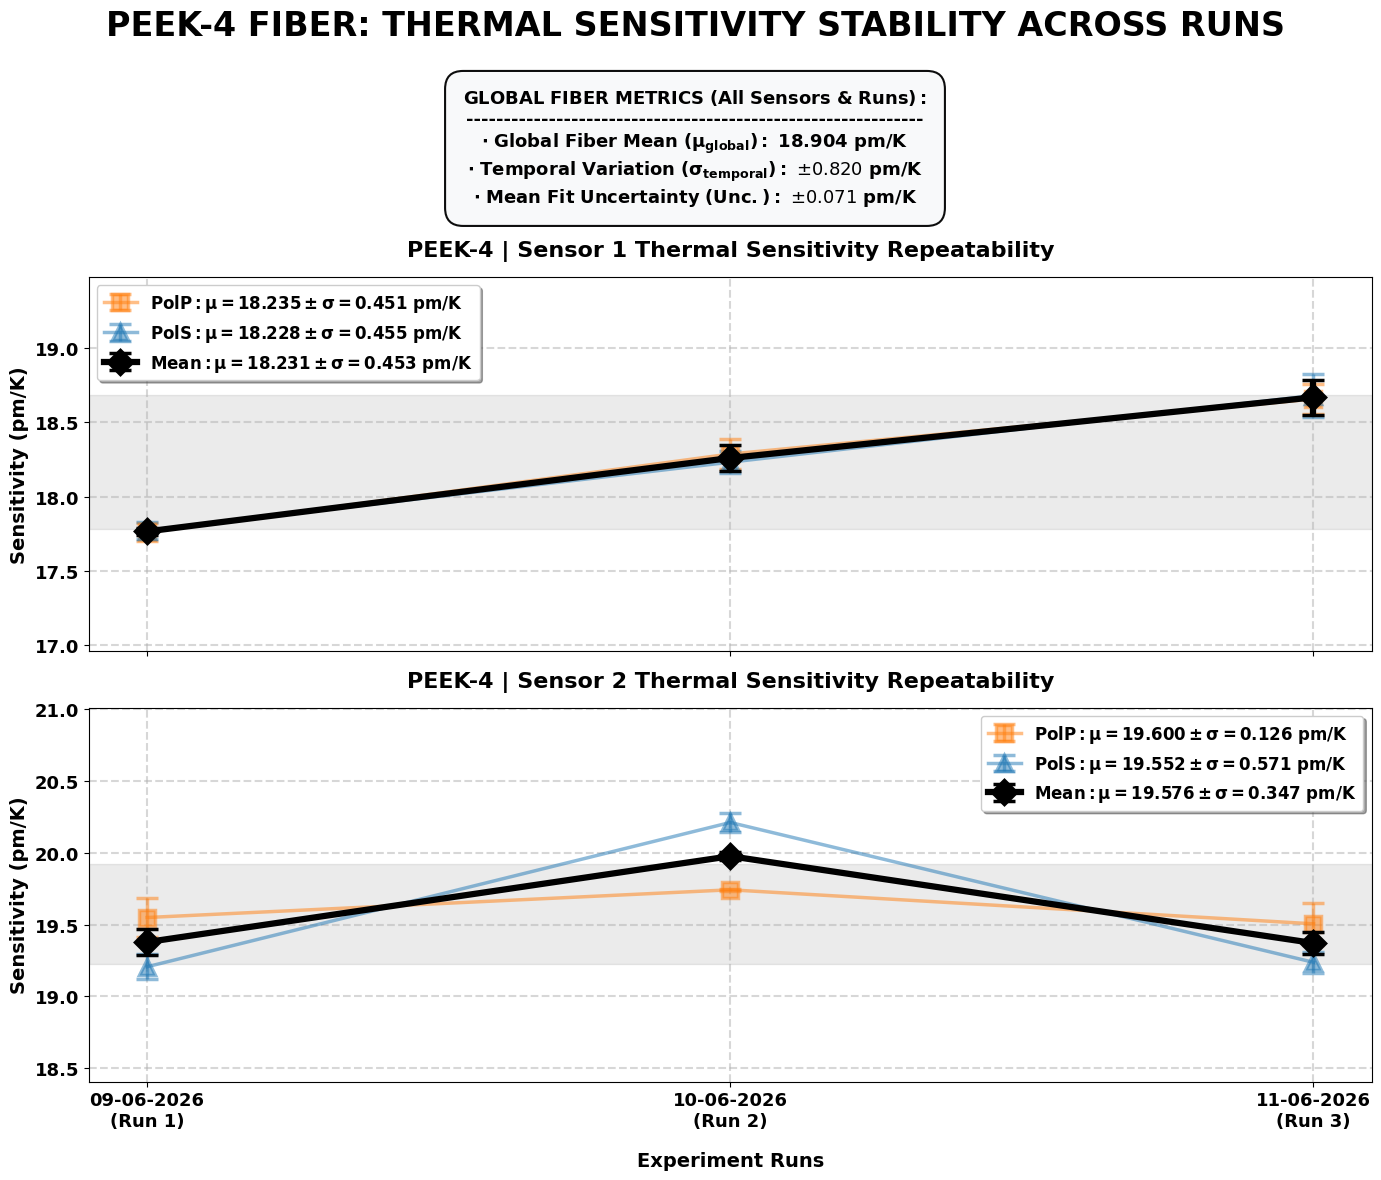


         TEMPORAL REPEATABILITY STATS SUMMARY (MEAN POLARIZATION)          
Sensor ID    | Mean Global μ (pm/K)     | Temporal Stability σ (pm/K)
---------------------------------------------------------------------------
Sensor 1     |          18.231        |            0.453
Sensor 2     |          19.576        |            0.347


In [27]:
# ============================================================================
# PEEK-4 REPEATABILITY ANALYSIS: 2 SENSORS | 3 RUNS
# Features: Legend Stats (μ ± σ), Shaded Stability Bands, and Global KPI Box
# Date: 2026-06-12 (Updated Analysis for PEEK-4 Fiber)
# OPTIMIZED: High-visibility bold typography & Top Global Stats Box for slides
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP DE DATOS (Campaña de Medidas de Junio 2026)
dates = ["09-06-2026\n(Run 1)", "10-06-2026\n(Run 2)", "11-06-2026\n(Run 3)"]
x = np.arange(len(dates))

# v: valor de la pendiente (pm/K), e: incertidumbre del ajuste (pm/K)
peek4_data = {
    "Sensor 1": {
        "Pol P": {"v": [17.760, 18.287, 18.658], "e": [0.060, 0.104, 0.102]},
        "Pol S": {"v": [17.771, 18.232, 18.681], "e": [0.057, 0.076, 0.143]},
        "Mean":  {"v": [17.765, 18.260, 18.669], "e": [0.023, 0.088, 0.118]}
    },
    "Sensor 2": {
        "Pol P": {"v": [19.550, 19.743, 19.506], "e": [0.136, 0.009, 0.144]},
        "Pol S": {"v": [19.207, 20.212, 19.238], "e": [0.088, 0.066, 0.071]},
        "Mean":  {"v": [19.379, 19.977, 19.372], "e": [0.092, 0.029, 0.074]}
    }
}

# --- Cálculo Automático de Estadísticos Globales de la Fibra ---
all_mean_slopes = []
all_fit_errors = []

for s_id in peek4_data:
    all_mean_slopes.extend(peek4_data[s_id]["Mean"]["v"])
    all_fit_errors.extend(peek4_data[s_id]["Mean"]["e"])

global_mu = np.mean(all_mean_slopes)
global_sigma_temporal = np.std(all_mean_slopes, ddof=1)  # Variabilidad temporal de la red
global_fit_err = np.mean(all_fit_errors)                # Error típico de regresión

# --- Styling Constants for Slides ---
FS_SUPTITLE = 24
FS_TITLE = 16
FS_LABEL = 14
FS_TICK = 13
FS_LEGEND = 12

# 2. PLOT CONFIGURATION (2 Filas para los 2 sensores)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

styles = {
    "Pol P": {"color": "#ff7f0e", "marker": "s", "alpha": 0.5}, # Orange
    "Pol S": {"color": "#1f77b4", "marker": "^", "alpha": 0.5}, # Blue
    "Mean":  {"color": "black",   "marker": "D", "alpha": 1.0}  # Black Diamond for Mean
}

# 3. LOOP THROUGH SENSORS
for i, sensor_id in enumerate(["Sensor 1", "Sensor 2"]):
    ax = axes[i]
    pols = peek4_data[sensor_id]
    all_vals_sensor = []
    
    for p_name, data in pols.items():
        v = np.array(data["v"])
        e = np.array(data["e"])
        all_vals_sensor.extend(v)
        
        mu = np.mean(v)
        sigma = np.std(v, ddof=1)
        
        style = styles[p_name]
        label = rf'$\mathbf{{{p_name}: \mu={mu:.3f} \pm \sigma={sigma:.3f}\ pm/K}}$'
        
        # Plot con barras de incertidumbre del ajuste
        ax.errorbar(x, v, yerr=e, fmt=style["marker"] + '-', color=style["color"],
                    capsize=8, markersize=12, linewidth=4.5 if p_name=="Mean" else 2.5,
                    markeredgewidth=2.5, alpha=style["alpha"], label=label,
                    zorder=10 if p_name=="Mean" else 5)
        
        # Banda de estabilidad temporal (Mean +/- Sigma) para la serie promedio
        if p_name == "Mean":
            ax.axhspan(mu - sigma, mu + sigma, color=style["color"], alpha=0.08, zorder=1)

    # Formateo de cada subplot
    ax.set_title(f'PEEK-4 | {sensor_id} Thermal Sensitivity Repeatability', fontsize=FS_TITLE, fontweight='bold', pad=15)
    ax.set_ylabel('Sensitivity (pm/K)', fontsize=FS_LABEL, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Leyenda en alta visibilidad
    leg = ax.legend(fontsize=FS_LEGEND, loc='best', frameon=True, shadow=True, facecolor='white')
    plt.setp(leg.get_texts(), fontweight='bold')
    
    # Límites dinámicos con margen
    y_min, y_max = np.min(all_vals_sensor), np.max(all_vals_sensor)
    ax.set_ylim(y_min - 0.8, y_max + 0.8)
    
    ax.tick_params(axis='y', labelsize=FS_TICK)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

# Formateo del eje común X
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(dates, fontsize=FS_TICK, fontweight='bold')
axes[-1].set_xlabel('Experiment Runs', fontsize=FS_LABEL, fontweight='bold', labelpad=15)

# Título Principal
plt.suptitle('PEEK-4 FIBER: THERMAL SENSITIVITY STABILITY ACROSS RUNS', 
             fontsize=FS_SUPTITLE, fontweight='bold', y=0.98)

# --- 📦 RECUADRO DE ESTADÍSTICOS GLOBALES (Debajo del Título Principal) ---
stats_box_text = (
    r"$\mathbf{GLOBAL\ FIBER\ METRICS\ (All\ Sensors\ &\ Runs):}$" + "\n"
    f"-------------------------------------------------------------\n"
    r"$\mathbf{\bullet\ Global\ Fiber\ Mean\ (\mu_{global}):}$ " + f"{global_mu:.3f} " + r"$\mathbf{pm/K}$" + "\n"
    r"$\mathbf{\bullet\ Temporal\ Variation\ (\sigma_{temporal}):}$ " + f"$\pm{global_sigma_temporal:.3f}$ " + r"$\mathbf{pm/K}$" + "\n"
    r"$\mathbf{\bullet\ Mean\ Fit\ Uncertainty\ (Unc.):}$ " + f"$\pm{global_fit_err:.3f}$ " + r"$\mathbf{pm/K}$"
)

# Insertamos el cuadro flotante con coordenadas limpias evitando el argumento 'shadow'
fig.text(0.5, 0.915, stats_box_text, transform=fig.transFigure,
         fontsize=13, fontweight='bold', ha='center', va='top',
         bbox=dict(facecolor='#f8f9fa', alpha=0.95, edgecolor='black', 
                  boxstyle='round,pad=1', linewidth=1.5))

# El rect=[0, 0, 1, 0.84] empuja hacia abajo los plots para dejar espacio libre al recuadro
plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()

# ============================================================================
# 4. TABLA RESUMEN POR TERMINAL
# ============================================================================
print("\n" + "="*75)
print(f"{'TEMPORAL REPEATABILITY STATS SUMMARY (MEAN POLARIZATION)':^75}")
print("="*75)
print(f"{'Sensor ID':<12} | {'Mean Global μ (pm/K)':<24} | {'Temporal Stability σ (pm/K)':<25}")
print("-" * 75)
for s_name, pols in peek4_data.items():
    m_vals = pols["Mean"]["v"]
    print(f"{s_name:<12} | {np.mean(m_vals):>15.3f}        | {np.std(m_vals, ddof=1):>16.3f}")
print("="*75)

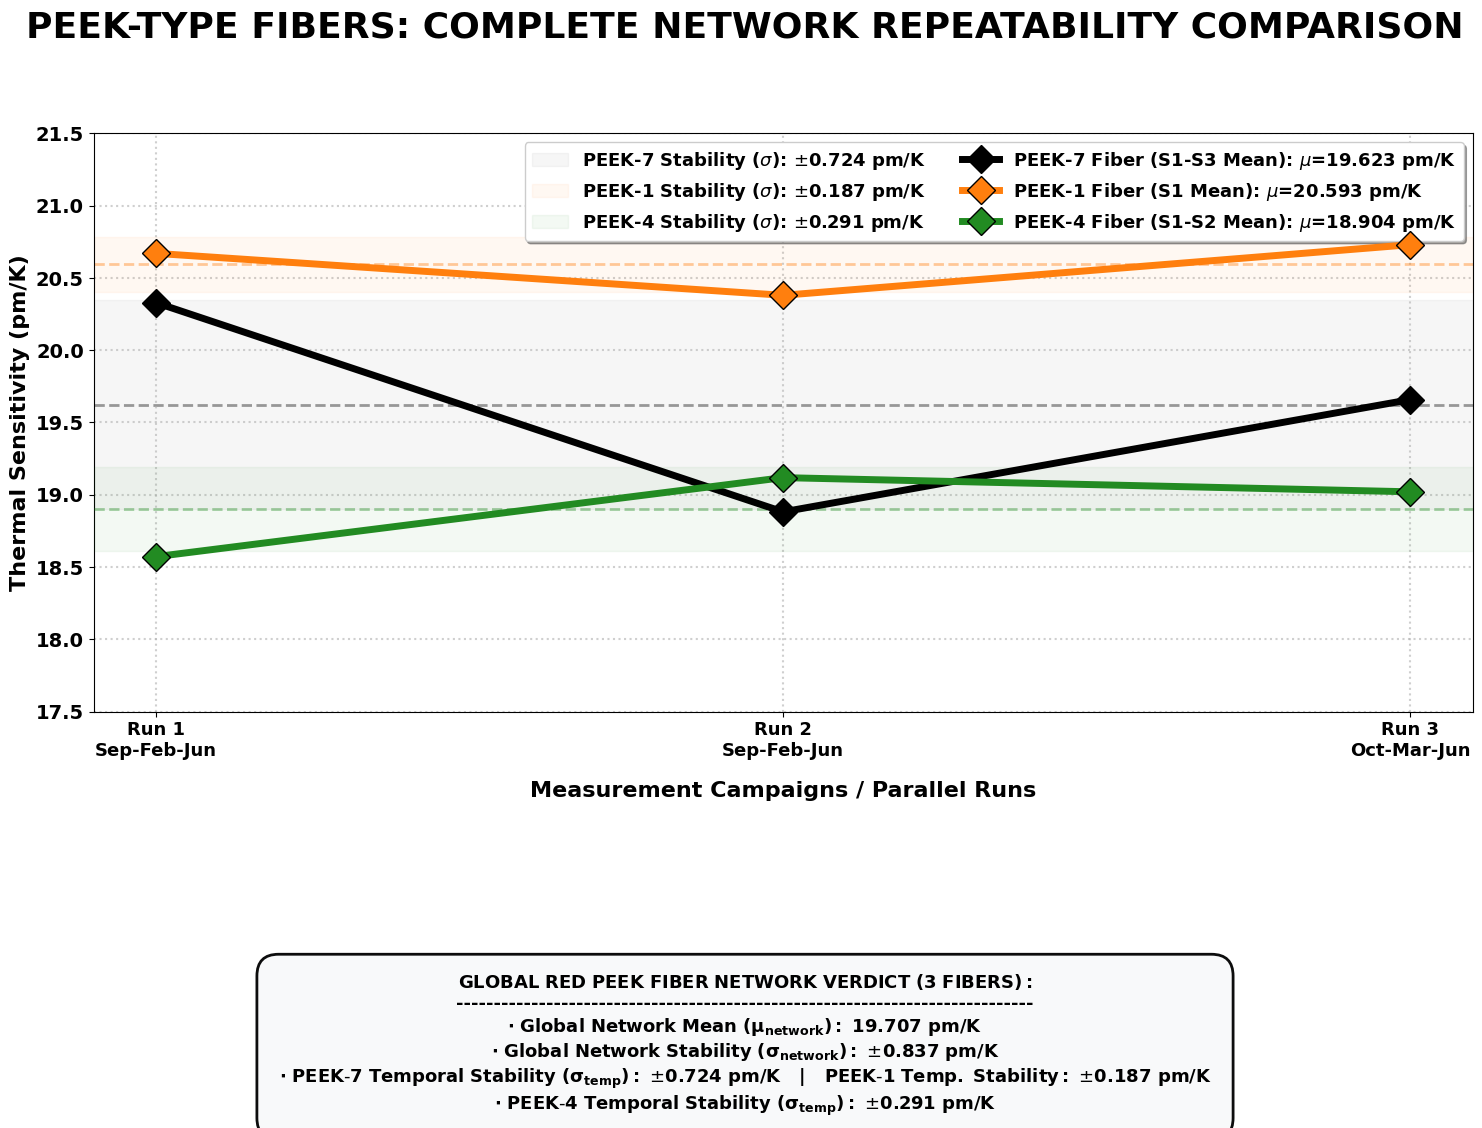


       GLOBAL REPEATABILITY SUMMARY: COMPLETE PEEK POLYIMIDE NETWORK       
Fiber Type            | Mean Global μ (pm/K)    | Temporal Stability σ (pm/K)
---------------------------------------------------------------------------
PEEK-7 (Sensors 1-3)  |             19.623        |            0.724
PEEK-1 (Sensor 1)     |             20.593        |            0.187
PEEK-4 (Sensors 1-2)  |             18.904        |            0.291
---------------------------------------------------------------------------
Red PEEK Network Global Combined Stats: μ = 19.707 ± σ = 0.837 pm/K


In [28]:
# ============================================================================
# JOINT REPEATABILITY ANALYSIS: PEEK-7 vs PEEK-1 vs PEEK-4 (FULL NETWORK)
# Features: Legend Stats (μ ± σ), Shared Stability Bands, and Global Network Box
# Date: 2026-06-12 (Unified Comparative Analysis - 3 Fibers)
# OPTIMIZED: Giant bold typography & Fixed Global Stats Box for slides
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETUP DE DATOS CONJUNTOS ---
dates = ["Run 1\nSep-Feb-Jun", "Run 2\nSep-Feb-Jun", "Run 3\nOct-Mar-Jun"]
x = np.arange(len(dates))

# PEEK-7: Promedio de las series "Mean" de sus 3 sensores independientes
p7_s1 = [18.661, 18.643, 19.470]
p7_s2 = [20.141, 19.016, 19.889]
p7_s3 = [22.183, 18.986, 19.615]
peek7_mean_v = np.mean([p7_s1, p7_s2, p7_s3], axis=0)

# PEEK-1: Serie "Mean" de su único sensor verificado
peek1_mean_v = [20.67, 20.38, 20.73]

# PEEK-4: Promedio de las series "Mean" de sus 2 sensores independientes (Nuevos datos de Junio)
p4_s1 = [17.765, 18.260, 18.669]
p4_s2 = [19.379, 19.977, 19.372]
peek4_mean_v = np.mean([p4_s1, p4_s2], axis=0)

# --- 2. CÁLCULO DE ESTADÍSTICAS POR FIBRA (ddof=1 para rigor muestral) ---
global_mu_p7 = np.mean(peek7_mean_v)
global_sigma_p7 = np.std(peek7_mean_v, ddof=1)

global_mu_p1 = np.mean(peek1_mean_v)
global_sigma_p1 = np.std(peek1_mean_v, ddof=1)

global_mu_p4 = np.mean(peek4_mean_v)
global_sigma_p4 = np.std(peek4_mean_v, ddof=1)

# Gran promedio y desviación estándar de TODA la red de fibra PEEK (todos los puntos combinados)
all_data_points = np.concatenate([peek7_mean_v, peek1_mean_v, peek4_mean_v])
red_peek_global_mu = np.mean(all_data_points)
red_peek_global_sigma = np.std(all_data_points, ddof=1)

# --- 3. CONFIGURACIÓN DE FIGURA Y TIPOGRAFÍA PARA SLIDES ---
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
FS_SUPTITLE = 26
FS_TITLE = 20
FS_LABEL = 16
FS_TICK = 14
FS_LEGEND = 13

# Altura ampliada a 13.0 para dar un suelo blanco impecable abajo del recuadro de 3 fibras
fig, ax = plt.subplots(figsize=(15, 13.0))

# --- 4. PLOT DE SERIES Y BANDAS DE ESTABILIDAD ---
# PEEK-7: Diamantes Negros y banda de estabilidad gris
ax.errorbar(x, peek7_mean_v, fmt='D-', color='black',
            capsize=12, markersize=14, linewidth=5, markeredgecolor='black',
            label=rf'PEEK-7 Fiber (S1-S3 Mean): $\mu$={global_mu_p7:.3f} pm/K', zorder=10)
ax.axhline(global_mu_p7, color='black', linestyle='--', linewidth=2, alpha=0.4, zorder=1)
ax.axhspan(global_mu_p7 - global_sigma_p7, global_mu_p7 + global_sigma_p7, color='gray', alpha=0.07, 
           label=rf'PEEK-7 Stability ($\sigma$): $\pm${global_sigma_p7:.3f} pm/K', zorder=1)

# PEEK-1: Diamantes Naranjas y banda naranja suave
ax.errorbar(x, peek1_mean_v, fmt='D-', color='#ff7f0e',
            capsize=12, markersize=14, linewidth=5, markeredgecolor='black',
            label=rf'PEEK-1 Fiber (S1 Mean): $\mu$={global_mu_p1:.3f} pm/K', zorder=11)
ax.axhline(global_mu_p1, color='#ff7f0e', linestyle='--', linewidth=2, alpha=0.4, zorder=2)
ax.axhspan(global_mu_p1 - global_sigma_p1, global_mu_p1 + global_sigma_p1, color='#ff7f0e', alpha=0.05, 
           label=rf'PEEK-1 Stability ($\sigma$): $\pm${global_sigma_p1:.3f} pm/K', zorder=2)

# PEEK-4: Diamantes Verdes y banda verde suave (Nueva incorporación)
ax.errorbar(x, peek4_mean_v, fmt='D-', color='forestgreen',
            capsize=12, markersize=14, linewidth=5, markeredgecolor='black',
            label=rf'PEEK-4 Fiber (S1-S2 Mean): $\mu$={global_mu_p4:.3f} pm/K', zorder=12)
ax.axhline(global_mu_p4, color='forestgreen', linestyle='--', linewidth=2, alpha=0.4, zorder=3)
ax.axhspan(global_mu_p4 - global_sigma_p4, global_mu_p4 + global_sigma_p4, color='forestgreen', alpha=0.05, 
           label=rf'PEEK-4 Stability ($\sigma$): $\pm${global_sigma_p4:.3f} pm/K', zorder=3)

# --- 5. CUADRO DE TEXTO GLOBAL (Blindado contra errores f-string de LaTeX) ---
stats_box_text = (
    r"$\mathbf{GLOBAL\ RED\ PEEK\ FIBER\ NETWORK\ VERDICT\ (3\ FIBERS):}$" + "\n"
    f"-----------------------------------------------------------------------------\n"
    r"$\mathbf{\bullet\ Global\ Network\ Mean\ (\mu_{network}):}$ " + f"{red_peek_global_mu:.3f} " + r"$\mathbf{pm/K}$" + "\n"
    r"$\mathbf{\bullet\ Global\ Network\ Stability\ (\sigma_{network}):}$ " + f"$\pm${red_peek_global_sigma:.3f} " + r"$\mathbf{pm/K}$" + "\n"
    r"$\mathbf{\bullet\ PEEK\text{-}7\ Temporal\ Stability\ (\sigma_{temp}):}$ " + f"$\pm${global_sigma_p7:.3f} " + r"$\mathbf{pm/K}$" + "   |   " + r"$\mathbf{PEEK\text{-}1\ Temp.\ Stability:}$ " + f"$\pm${global_sigma_p1:.3f} " + r"$\mathbf{pm/K}$" + "\n"
    r"$\mathbf{\bullet\ PEEK\text{-}4\ Temporal\ Stability\ (\sigma_{temp}):}$ " + f"$\pm${global_sigma_p4:.3f} " + r"$\mathbf{pm/K}$"
)

# El recuadro flotante se posiciona perfectamente centrado en la zona blanca baja
fig.text(0.5, 0.24, stats_box_text, transform=fig.transFigure,
         fontsize=13, fontweight='bold', ha='center', va='top',
         bbox=dict(facecolor='#f8f9fa', alpha=0.95, edgecolor='black', 
                  boxstyle='round,pad=1.2', linewidth=2.0))

# --- 6. ESTILO DE EJES Y LEYENDAS ---
plt.suptitle('PEEK-TYPE FIBERS: COMPLETE NETWORK REPEATABILITY COMPARISON', 
             fontsize=FS_SUPTITLE, y=0.98, fontweight='bold')

ax.set_ylabel('Thermal Sensitivity (pm/K)', fontsize=FS_LABEL, fontweight='bold')
ax.set_xlabel('Measurement Campaigns / Parallel Runs', fontsize=FS_LABEL, fontweight='bold', labelpad=15)

ax.set_xticks(x)
ax.set_xticklabels(dates, fontsize=13, fontweight='bold')

ax.tick_params(axis='y', labelsize=FS_TICK)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')

ax.grid(True, linestyle=':', alpha=0.6, linewidth=1.5)

# Límites optimizados para abarcar de forma holgada las tres franjas de sensibilidad
ax.set_ylim(17.5, 21.5)

# Leyenda de alta visibilidad organizada en 2 columnas
leg = ax.legend(loc='upper right', fontsize=FS_LEGEND, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.setp(leg.get_texts(), fontweight='bold')

# rect=[izq, fondo, der, top] -> 0.36 eleva el plot liberando el espacio para los KPI y el suelo blanco
plt.tight_layout(rect=[0, 0.36, 1, 0.94])
plt.show()

# ============================================================================
# 7. IMPRESIÓN DEL RESUMEN ESTADÍSTICO TERMINAL COMPLETO
# ============================================================================
print("\n" + "="*75)
print(f"{'GLOBAL REPEATABILITY SUMMARY: COMPLETE PEEK POLYIMIDE NETWORK':^75}")
print("="*75)
print(f"{'Fiber Type':<21} | {'Mean Global μ (pm/K)':<23} | {'Temporal Stability σ (pm/K)':<25}")
print("-" * 75)
print(f"{'PEEK-7 (Sensors 1-3)':<21} | {global_mu_p7:>18.3f}        | {global_sigma_p7:>16.3f}")
print(f"{'PEEK-1 (Sensor 1)':<21} | {global_mu_p1:>18.3f}        | {global_sigma_p1:>16.3f}")
print(f"{'PEEK-4 (Sensors 1-2)':<21} | {global_mu_p4:>18.3f}        | {global_sigma_p4:>16.3f}")
print("-" * 75)
print(f"{'Red PEEK Network Global Combined Stats:':<38} μ = {red_peek_global_mu:.3f} ± σ = {red_peek_global_sigma:.3f} pm/K")
print("="*75)


 🛠️ A. METROLOGICAL RESOLUTION ANALYSIS (Plateau 1) 
• Optical Noise Floor (1σ):     0.2471 pm
• Noise Equivalent Temp (1σ):   13.24 mK
• System Resolution Limit (3σ): 39.71 mK

⏳ Aligning Signals via Cross-Correlation of Derivatives...
✅ Maximum overlap found! RTD is delayed by: -7.0 seconds.


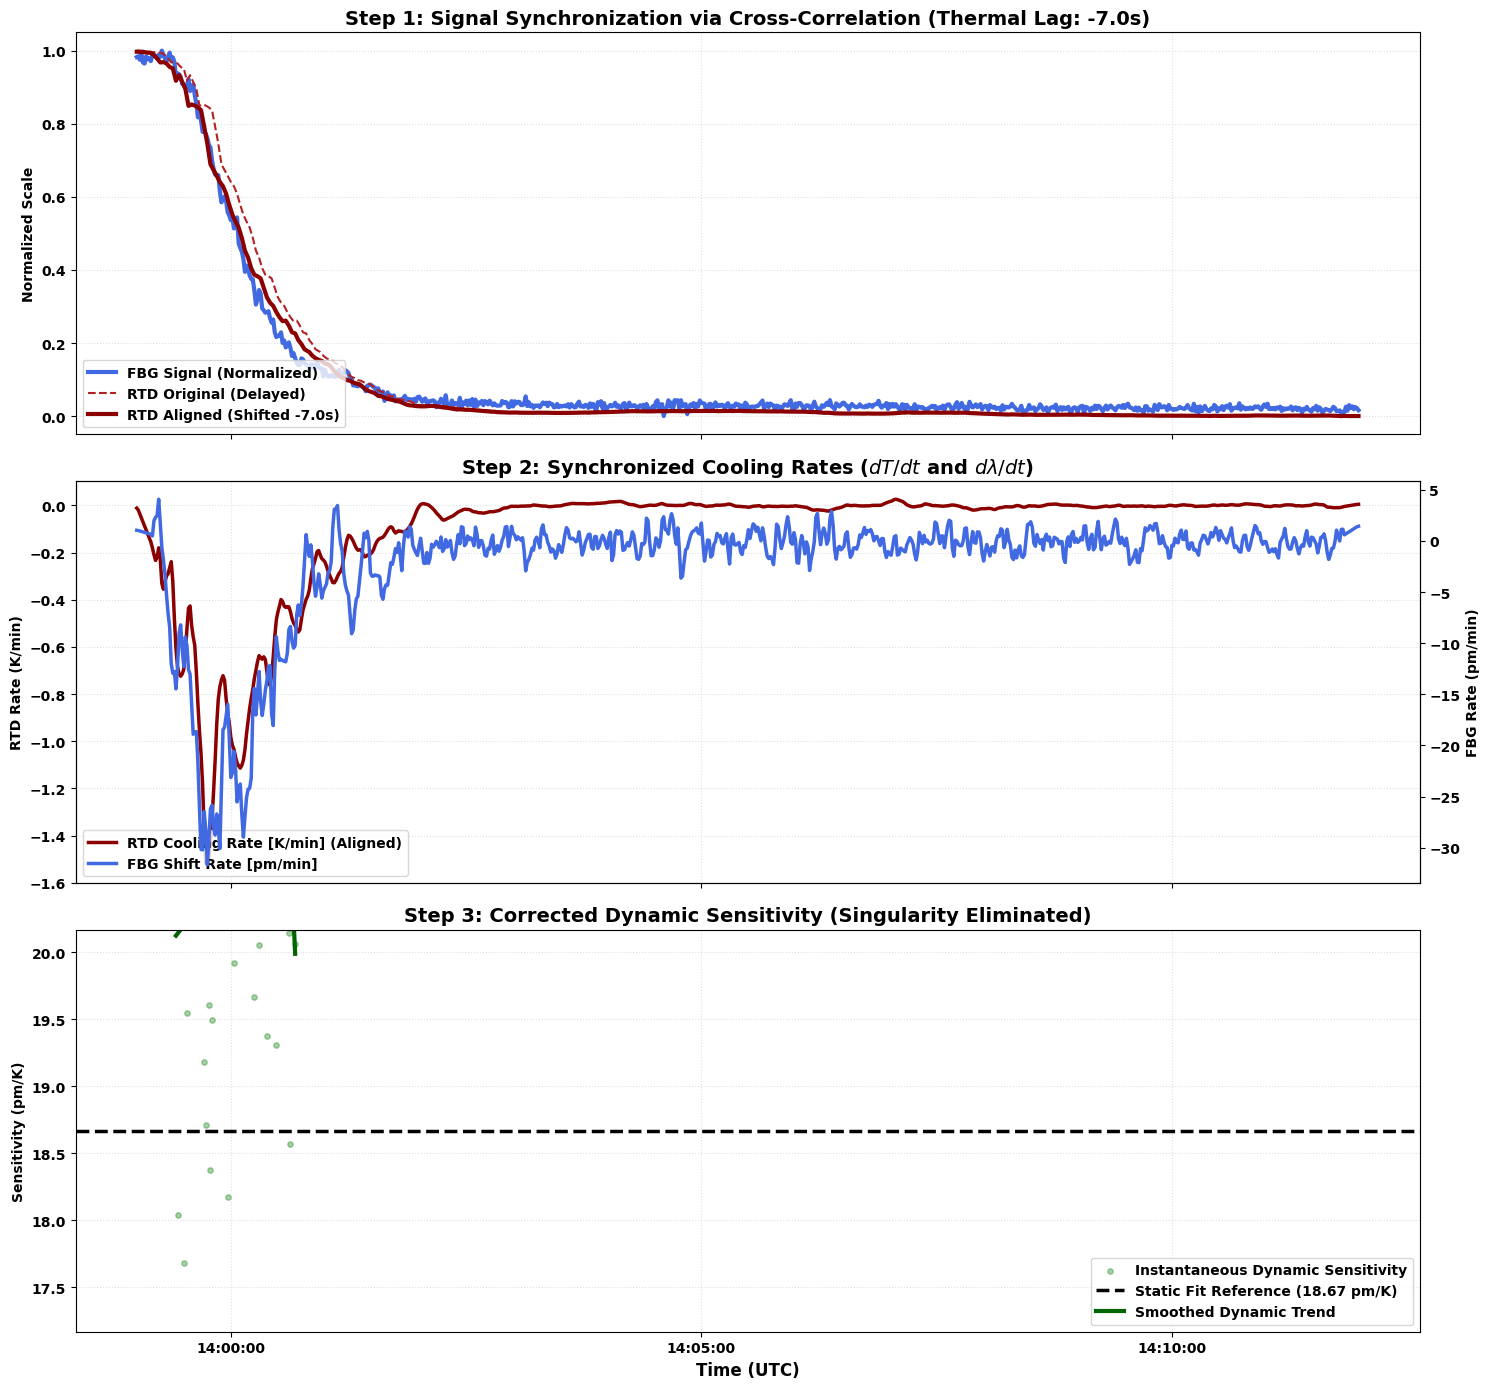

In [29]:
# ============================================================================
# ADVANCED METROLOGICAL ANALYSIS: Resolution & Dynamic Synchronization
# Fiber: PEEK-4 | Run 3 | Sensor 1 (Mean Polarization)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter, correlate, correlation_lags
from scipy import stats
import datetime 

# --- CONFIGURACIÓN ---
sensor_key = "FBG-1-Mean"
fbg_times = fbg_mean_data[sensor_key]["timestamps"]
fbg_wavs = fbg_mean_data[sensor_key]["wavelength"]

SENSITIVITY_PM_K = 18.669 
SENSITIVITY_NM_K = SENSITIVITY_PM_K / 1000.0

# ============================================================================
# PARTE A: RESOLUCIÓN LÍMITE (En el Plateau 1)
# ============================================================================
if len(plateau_data) >= 1:
    p1_start, p1_end = plateau_data[0]["t0"], plateau_data[0]["tfin"]
    mask_fbg_p1 = (fbg_times >= p1_start) & (fbg_times <= p1_end)
    wavs_p1 = fbg_wavs[mask_fbg_p1]
    
    # Detrend para aislar ruido puro
    x_idx = np.arange(len(wavs_p1))
    slope, intercept, _, _, _ = stats.linregress(x_idx, wavs_p1)
    wavs_p1_detrended = wavs_p1 - (slope * x_idx + intercept)
    
    sigma_wav_pm = np.std(wavs_p1_detrended, ddof=1) * 1000.0
    sigma_temp_mK = (sigma_wav_pm / SENSITIVITY_PM_K) * 1000.0
    res_3sigma_mK = 3 * sigma_temp_mK

    print("\n" + "="*65)
    print(" 🛠️ A. METROLOGICAL RESOLUTION ANALYSIS (Plateau 1) ")
    print("="*65)
    print(f"• Optical Noise Floor (1σ):     {sigma_wav_pm:.4f} pm")
    print(f"• Noise Equivalent Temp (1σ):   {sigma_temp_mK:.2f} mK")
    print(f"• System Resolution Limit (3σ): {res_3sigma_mK:.2f} mK")
    print("="*65)

# ============================================================================
# PARTE B: ALINEAMIENTO TEMPORAL Y SENSIBILIDAD DINÁMICA
# ============================================================================
if len(plateau_data) >= 2:
    print("\n⏳ Aligning Signals via Cross-Correlation of Derivatives...")
    
    r_start, r_end = plateau_data[0]["tfin"], plateau_data[1]["t0"]
    
    # Extraer rampa y convertir a segundos desde t=0
    m_rtd = (times_temp_ref >= r_start) & (times_temp_ref <= r_end)
    m_fbg = (fbg_times >= r_start) & (fbg_times <= r_end)
    
    t0_dt = min(times_temp_ref[m_rtd][0], fbg_times[m_fbg][0])
    t_rtd_s = np.array([(t - t0_dt).total_seconds() for t in times_temp_ref[m_rtd]])
    t_fbg_s = np.array([(t - t0_dt).total_seconds() for t in fbg_times[m_fbg]])
    
    T_raw = temp_ref_valid[m_rtd]
    W_raw = fbg_wavs[m_fbg]
    
    # 1. Base de tiempo común de alta resolución (1 segundo)
    dt_res = 1.0 
    t_master = np.arange(0, max(t_rtd_s.max(), t_fbg_s.max()), dt_res)
    
    T_interp = np.interp(t_master, t_rtd_s, T_raw)
    W_interp = np.interp(t_master, t_fbg_s, W_raw)
    
    # 2. Normalización Min-Max (0 a 1) para comparar formas de onda
    T_norm = (T_interp - T_interp.min()) / (T_interp.max() - T_interp.min())
    W_norm = (W_interp - W_interp.min()) / (W_interp.max() - W_interp.min())
    
    # 3. Correlación Cruzada de las DERIVADAS (La Clave Matemática)
    # Extraemos la tasa de cambio normalizada para ignorar los plateaus planos
    W_norm_smooth = savgol_filter(W_norm, window_length=31, polyorder=2)
    T_norm_smooth = savgol_filter(T_norm, window_length=31, polyorder=2)
    
    dW_norm = np.gradient(W_norm_smooth)
    dT_norm = np.gradient(T_norm_smooth)
    
    corr = correlate(dW_norm, dT_norm, mode='full')
    lags = correlation_lags(len(dW_norm), len(dT_norm), mode='full')
    
    lag_sec = lags[np.argmax(corr)] * dt_res
    print(f"✅ Maximum overlap found! RTD is delayed by: {lag_sec:.1f} seconds.")
    
    # 4. Alinear Matemáticamente (Adelantamos el RTD para sincronizarlo con el FBG)
    T_aligned = np.interp(t_master, t_master + lag_sec, T_interp)
    T_norm_aligned = np.interp(t_master, t_master + lag_sec, T_norm)
    
    # 5. Suavizado y Derivadas (np.gradient mantiene el tamaño del array)
    W_smooth = savgol_filter(W_interp, window_length=21, polyorder=2)
    T_smooth = savgol_filter(T_aligned, window_length=21, polyorder=2)
    
    dW_dt = np.gradient(W_smooth, dt_res) # nm/s
    dT_dt = np.gradient(T_smooth, dt_res) # K/s
    
    # Sensibilidad (Solo calculada donde realmente está enfriando de forma clara)
    mask_cooling = dT_dt < -0.005
    sens_din_pmK = np.full_like(dT_dt, np.nan)
    sens_din_pmK[mask_cooling] = (dW_dt[mask_cooling] / dT_dt[mask_cooling]) * 1000.0
    
    # --- PLOT DE 3 PANELES ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
    
    t_plot_dt = [t0_dt + datetime.timedelta(seconds=float(s)) for s in t_master]
    
    # PANEL 1: Demostración de Sincronismo
    ax1.plot(t_plot_dt, W_norm, color='royalblue', linewidth=3, label='FBG Signal (Normalized)')
    ax1.plot(t_plot_dt, T_norm, color='firebrick', linewidth=1.5, linestyle='--', label='RTD Original (Delayed)')
    ax1.plot(t_plot_dt, T_norm_aligned, color='darkred', linewidth=3, label=f'RTD Aligned (Shifted {lag_sec:.1f}s)')
    ax1.set_title(f'Step 1: Signal Synchronization via Cross-Correlation (Thermal Lag: {lag_sec:.1f}s)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Normalized Scale', fontweight='bold')
    ax1.legend(loc='lower left')
    ax1.grid(True, alpha=0.4, linestyle=':')
    
    # PANEL 2: Tasas de Enfriamiento Sincronizadas
    ax2.plot(t_plot_dt, dT_dt * 60, color='darkred', linewidth=2.5, label='RTD Cooling Rate [K/min] (Aligned)')
    ax2.set_ylabel('RTD Rate (K/min)', fontweight='bold')
    
    ax2b = ax2.twinx()
    ax2b.plot(t_plot_dt, dW_dt * 60 * 1000, color='royalblue', linewidth=2.5, label='FBG Shift Rate [pm/min]')
    ax2b.set_ylabel('FBG Rate (pm/min)', fontweight='bold')
    
    ax2.set_title('Step 2: Synchronized Cooling Rates ($dT/dt$ and $d\lambda/dt$)', fontsize=14, fontweight='bold')
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_2b, labels_2b = ax2b.get_legend_handles_labels()
    ax2.legend(lines_2 + lines_2b, labels_2 + labels_2b, loc='lower left')
    ax2.grid(True, alpha=0.4, linestyle=':')
    
    # PANEL 3: Sensibilidad Dinámica Corregida
    ax3.scatter(t_plot_dt, sens_din_pmK, color='forestgreen', s=15, alpha=0.4, label='Instantaneous Dynamic Sensitivity')
    ax3.axhline(SENSITIVITY_PM_K, color='black', linestyle='--', linewidth=2.5, label=f'Static Fit Reference ({SENSITIVITY_PM_K:.2f} pm/K)')
    
    if np.sum(mask_cooling) > 21:
        valid_idx = np.where(mask_cooling)[0]
        # Eliminamos posibles picos residuales por matemáticas divisiones
        clean_sens = sens_din_pmK[valid_idx]
        med = np.median(clean_sens)
        super_clean_idx = np.abs(clean_sens - med) < 3.0 # Filtro de ruido severo
        
        if np.sum(super_clean_idx) > 21:
            sens_smooth = savgol_filter(clean_sens[super_clean_idx], window_length=21, polyorder=2)
            t_smooth_plot = np.array(t_plot_dt)[valid_idx][super_clean_idx]
            ax3.plot(t_smooth_plot, sens_smooth, color='darkgreen', linewidth=3, label='Smoothed Dynamic Trend')
        
    ax3.set_title('Step 3: Corrected Dynamic Sensitivity (Singularity Eliminated)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Sensitivity (pm/K)', fontweight='bold')
    ax3.set_xlabel('Time (UTC)', fontweight='bold', fontsize=12)
    ax3.set_ylim(SENSITIVITY_PM_K - 1.5, SENSITIVITY_PM_K + 1.5)
    ax3.legend(loc='lower right')
    ax3.grid(True, alpha=0.4, linestyle=':')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    
    plt.tight_layout()
    plt.show()

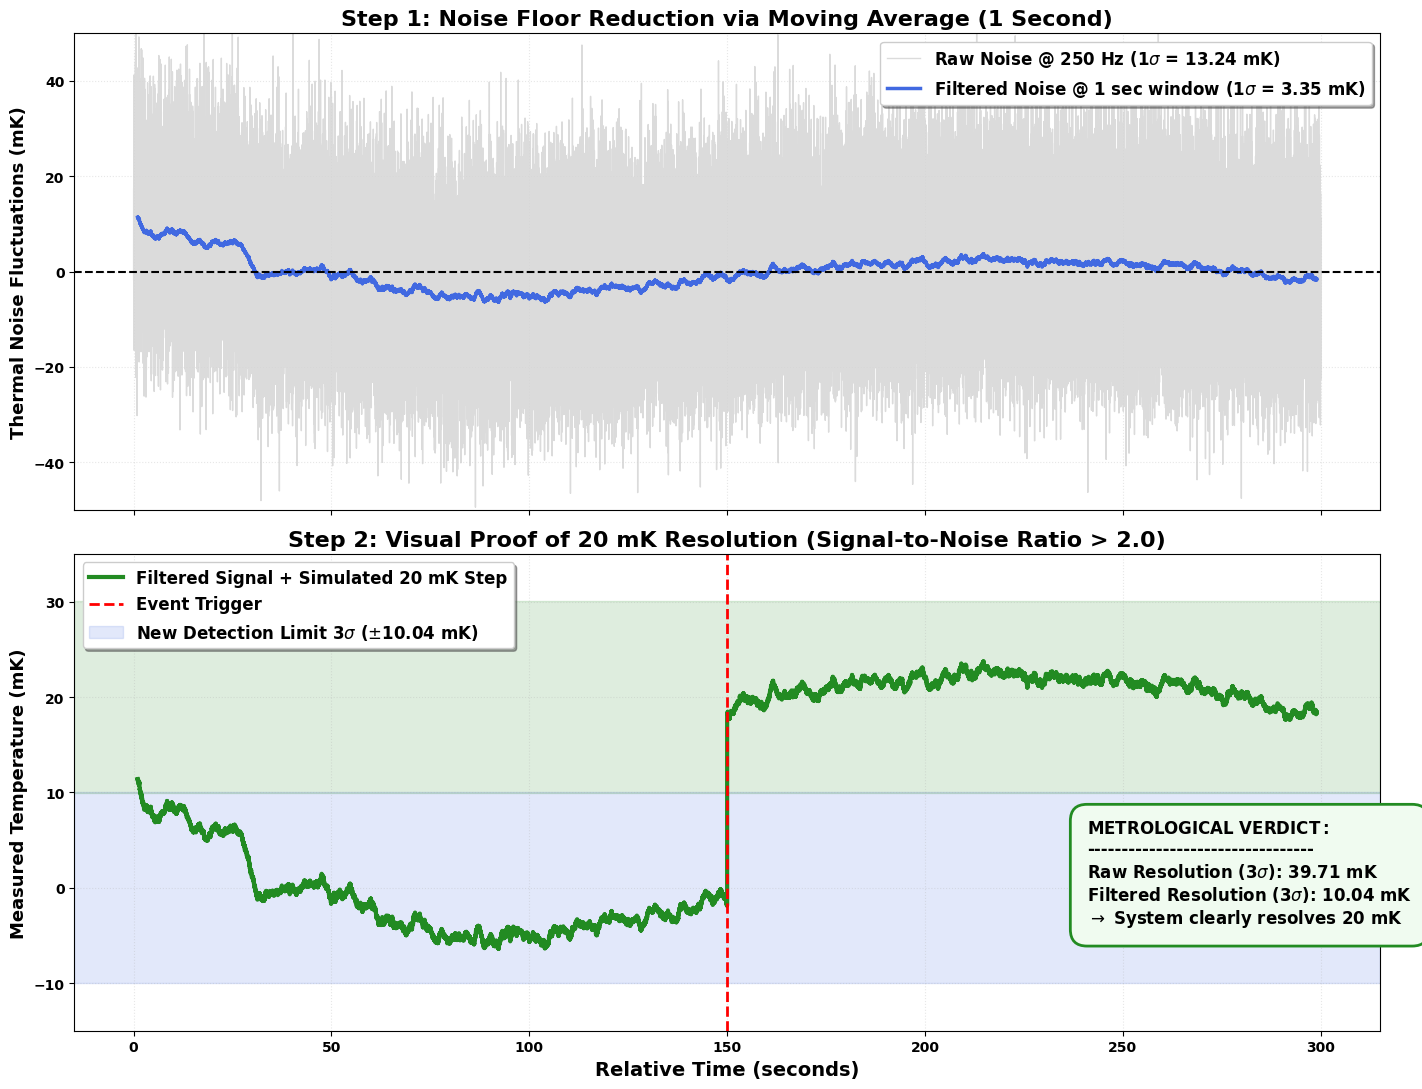


 🔬 20 mK RESOLUTION METROLOGICAL VERDICT
• Raw Data 1-sigma Noise (250 Hz):   13.24 mK
• Raw Data Resolution Limit (3σ):    39.71 mK
-----------------------------------------------------------------
• Filtered 1-sigma Noise (1s Avg):   3.35 mK
• Filtered Resolution Limit (3σ):    10.04 mK
✅ SUCCESS: A 20 mK step is 6.0 times larger than the filtered 1σ noise.
   The system safely resolves 20 mK changes without ambiguity.


In [ ]:
# ============================================================================
# METROLOGICAL PROOF: 20 mK Resolution Verification (250 Hz Sampling)
# Fiber: PEEK-4 | Sensor 1 | Method: Moving Average Noise Reduction
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARÁMETROS DEL FILTRO ---
FS_HZ = 250               # Frecuencia de muestreo de tu interrogador
WINDOW_SEC = 1.0          # Ventana de promediado móvil (1 segundo)
N_SAMPLES = int(FS_HZ * WINDOW_SEC)
SENSITIVITY_PM_K = 18.669 # Sensibilidad estática de PEEK-4

# --- 2. CONVERSIÓN Y FILTRADO ---
# Convertimos el array de ruido puro (nm) de la celda anterior a temperatura (mK)
# wavs_p1_detrended oscila alrededor de 0, así que nos da el ruido directamente
ruido_temp_mK = (wavs_p1_detrended * 1000.0 / SENSITIVITY_PM_K) * 1000.0

# Aplicamos el filtro de media móvil usando Pandas
s_raw = pd.Series(ruido_temp_mK)
s_filtered = s_raw.rolling(window=N_SAMPLES, center=True).mean()

# --- 3. CÁLCULO DE MÉTRICAS ESTADÍSTICAS ---
sigma_raw = np.std(ruido_temp_mK, ddof=1)
sigma_filtered = np.std(s_filtered.dropna(), ddof=1)

res_3sigma_raw = 3 * sigma_raw
res_3sigma_filtered = 3 * sigma_filtered

# --- 4. PRUEBA VISUAL SINTÉTICA (Escalón de 20 mK) ---
# Sumamos 20 mK a la segunda mitad de la señal filtrada real para simular el evento
s_demo_20mK = s_filtered.copy()
half_idx = len(s_demo_20mK) // 2
s_demo_20mK.iloc[half_idx:] += 20.0 

# ============================================================================
# 5. PLOT PARA LA TESIS
# ============================================================================
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

# Crear un eje temporal relativo en segundos
t_sec = np.arange(len(ruido_temp_mK)) / FS_HZ

# PANEL 1: Ruido Bruto vs Ruido Filtrado
ax1.plot(t_sec, s_raw, color='lightgray', alpha=0.8, linewidth=1, label=rf'Raw Noise @ 250 Hz (1$\sigma$ = {sigma_raw:.2f} mK)')
ax1.plot(t_sec, s_filtered, color='royalblue', linewidth=2.5, label=rf'Filtered Noise @ 1 sec window (1$\sigma$ = {sigma_filtered:.2f} mK)')
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)

ax1.set_title('Step 1: Noise Floor Reduction via Moving Average (1 Second)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Thermal Noise Fluctuations (mK)', fontsize=13)
ax1.set_ylim(-50, 50)
ax1.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle=':')

# PANEL 2: Demostración Visual de los 20 mK
ax2.plot(t_sec, s_demo_20mK, color='forestgreen', linewidth=3, label='Filtered Signal + Simulated 20 mK Step')
ax2.axvline(t_sec[half_idx], color='red', linestyle='--', linewidth=2, label='Event Trigger')

# Líneas de umbral de resolución 3-sigma
ax2.axhspan(-res_3sigma_filtered, res_3sigma_filtered, color='royalblue', alpha=0.15, 
            label=rf'New Detection Limit 3$\sigma$ ($\pm${res_3sigma_filtered:.2f} mK)')
ax2.axhspan(20 - res_3sigma_filtered, 20 + res_3sigma_filtered, color='forestgreen', alpha=0.15)

ax2.set_title(f'Step 2: Visual Proof of 20 mK Resolution (Signal-to-Noise Ratio > {20/res_3sigma_filtered:.1f})', fontsize=16, fontweight='bold')
ax2.set_xlabel('Relative Time (seconds)', fontsize=14)
ax2.set_ylabel('Measured Temperature (mK)', fontsize=13)
ax2.set_ylim(-15, 35)
ax2.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle=':')

# Recuadro de veredicto
verdict_text = (
    rf"$\mathbf{{METROLOGICAL\ VERDICT:}}$" + "\n"
    f"---------------------------------\n"
    rf"Raw Resolution (3$\sigma$): {res_3sigma_raw:.2f} mK" + "\n"
    rf"Filtered Resolution (3$\sigma$): $\mathbf{{{res_3sigma_filtered:.2f}\ mK}}$" + "\n"
    rf"$\rightarrow$ System clearly resolves 20 mK"
)
fig.text(0.78, 0.25, verdict_text, transform=fig.transFigure, fontsize=12, 
         fontweight='bold', ha='left', va='top',
         bbox=dict(boxstyle='round,pad=1', facecolor='#F0FBF0', edgecolor='forestgreen', linewidth=2))

plt.tight_layout()
plt.show()

# ============================================================================
# IMPRESIÓN POR TERMINAL
# ============================================================================
print("\n" + "="*65)
print(" 🔬 20 mK RESOLUTION METROLOGICAL VERDICT")
print("="*65)
print(f"• Raw Data 1-sigma Noise (250 Hz):   {sigma_raw:.2f} mK")
print(f"• Raw Data Resolution Limit (3σ):    {res_3sigma_raw:.2f} mK")
print("-" * 65)
print(f"• Filtered 1-sigma Noise (1s Avg):   {sigma_filtered:.2f} mK")
print(f"• Filtered Resolution Limit (3σ):    {res_3sigma_filtered:.2f} mK")
print("="*65)
if res_3sigma_filtered <= 20.0:
    print(f"✅ SUCCESS: A 20 mK step is {20/sigma_filtered:.1f} times larger than the filtered 1σ noise.")
    print("   The system safely resolves 20 mK changes without ambiguity.")
else:
    print("❌ CAUTION: The noise floor is still too high to guarantee 20 mK resolution.")
print("="*65)

🔍 Realizando Zoom Extremo en el Plateau 1...


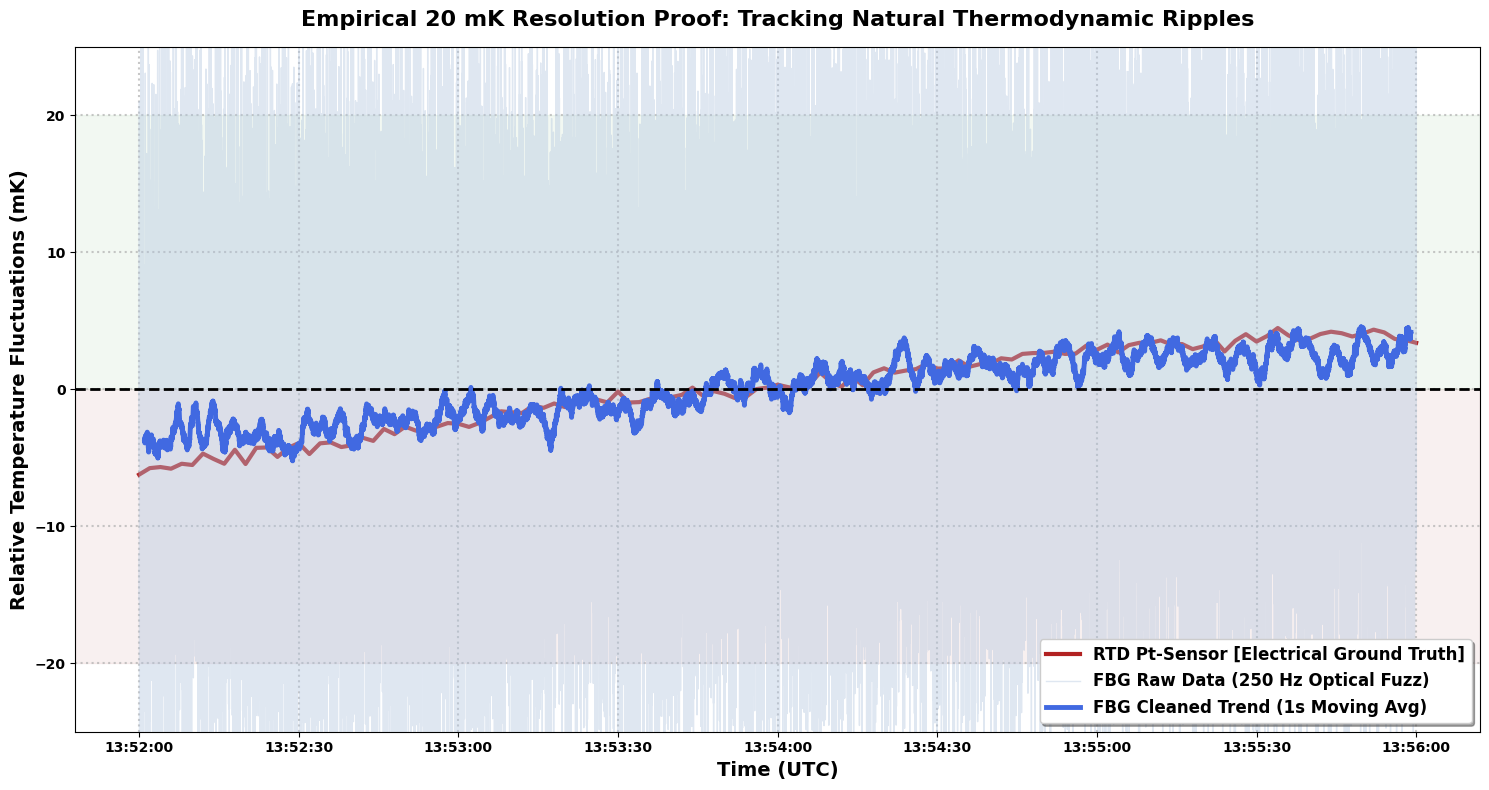

In [36]:
# ============================================================================
# EMPIRICAL RESOLUTION PROOF: Thermodynamic Ripple Tracking (Micro-Zoom)
# Fiber: PEEK-4 | Run 3 | Sensor 1
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# --- CONFIGURACIÓN ---
sensor_key = "FBG-1-Mean"
fbg_times = fbg_mean_data[sensor_key]["timestamps"]
fbg_wavs = fbg_mean_data[sensor_key]["wavelength"]

SENSITIVITY_PM_K = 18.669
SENSITIVITY_NM_K = SENSITIVITY_PM_K / 1000.0

if len(plateau_data) >= 1:
    print("🔍 Realizando Zoom Extremo en el Plateau 1...")
    
    p1_start = plateau_data[0]["t0"]
    p1_end = plateau_data[0]["tfin"]
    duration_sec = (p1_end - p1_start).total_seconds()
    
    # 1. Seleccionar una ventana de 4 minutos dentro del plateau 
    # (saltamos el principio para evitar la estabilización térmica inicial)
    if duration_sec > 300:
        zoom_start = p1_start + datetime.timedelta(minutes=3)
        zoom_end = zoom_start + datetime.timedelta(minutes=4)
    else:
        zoom_start = p1_start + datetime.timedelta(seconds=duration_sec*0.2)
        zoom_end = p1_start + datetime.timedelta(seconds=duration_sec*0.8)

    # 2. Extraer datos para el micro-zoom
    m_rtd = (times_temp_ref >= zoom_start) & (times_temp_ref <= zoom_end)
    m_fbg = (fbg_times >= zoom_start) & (fbg_times <= zoom_end)
    
    t_rtd_zoom = times_temp_ref[m_rtd]
    T_rtd_zoom = temp_ref_valid[m_rtd]
    
    t_fbg_zoom = fbg_times[m_fbg]
    W_fbg_zoom = fbg_wavs[m_fbg]
    
    # 3. Convertir FBG a Temperatura absoluta (usando la sensibilidad)
    T_fbg_converted = W_fbg_zoom / SENSITIVITY_NM_K
    
    # 4. Centrar ambas señales en CERO (restar la media) y pasar a mK
    rtd_centered_mK = (T_rtd_zoom - np.mean(T_rtd_zoom)) * 1000.0
    fbg_centered_mK = (T_fbg_converted - np.mean(T_fbg_converted)) * 1000.0
    
    # 5. Filtrar el FBG a 1 segundo para limpiar el ruido del láser y ver la termodinámica
    window_size = 250  # Suponiendo ~250Hz
    s_fbg = pd.Series(fbg_centered_mK)
    fbg_clean_mK = s_fbg.rolling(window=window_size, center=True).mean()
    
    # ========================================================================
    # PLOT DE ALTA PRECISIÓN METROLÓGICA
    # ========================================================================
    plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Graficar RTD (La Verdad de Referencia)
    ax.plot(t_rtd_zoom, rtd_centered_mK, color='firebrick', linewidth=3, 
            label='RTD Pt-Sensor [Electrical Ground Truth]')
    
    # Graficar FBG (Nube de ruido y Tendencia Limpia)
    ax.plot(t_fbg_zoom, fbg_centered_mK, color='lightsteelblue', alpha=0.4, linewidth=1, 
            label='FBG Raw Data (250 Hz Optical Fuzz)')
    ax.plot(t_fbg_zoom, fbg_clean_mK, color='royalblue', linewidth=3.5, 
            label='FBG Cleaned Trend (1s Moving Avg)')
    
    # Formateo de Rejilla para leer los saltos de 10 en 10 mK
    ax.yaxis.set_major_locator(plt.MultipleLocator(10)) 
    ax.axhline(0, color='black', linestyle='--', linewidth=2)
    
    # Bandas de referencia de 20 mK
    ax.axhspan(0, 20, color='forestgreen', alpha=0.06)
    ax.axhspan(-20, 0, color='darkred', alpha=0.06)
    
    ax.set_title('Empirical 20 mK Resolution Proof: Tracking Natural Thermodynamic Ripples', 
                 fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Relative Temperature Fluctuations (mK)', fontsize=14)
    ax.set_xlabel('Time (UTC)', fontsize=14)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    
    # Ajuste dinámico del eje Y basándose en la fluctuación real
    max_amp = max(np.abs(rtd_centered_mK.min()), np.abs(rtd_centered_mK.max()))
    limit = max(25, max_amp + 10)
    ax.set_ylim(-limit, limit)
    
    ax.grid(True, linestyle=':', linewidth=1.5, alpha=0.7)
    leg = ax.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    plt.setp(leg.get_texts(), fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se encontraron plateaus definidos en plateau_data.")

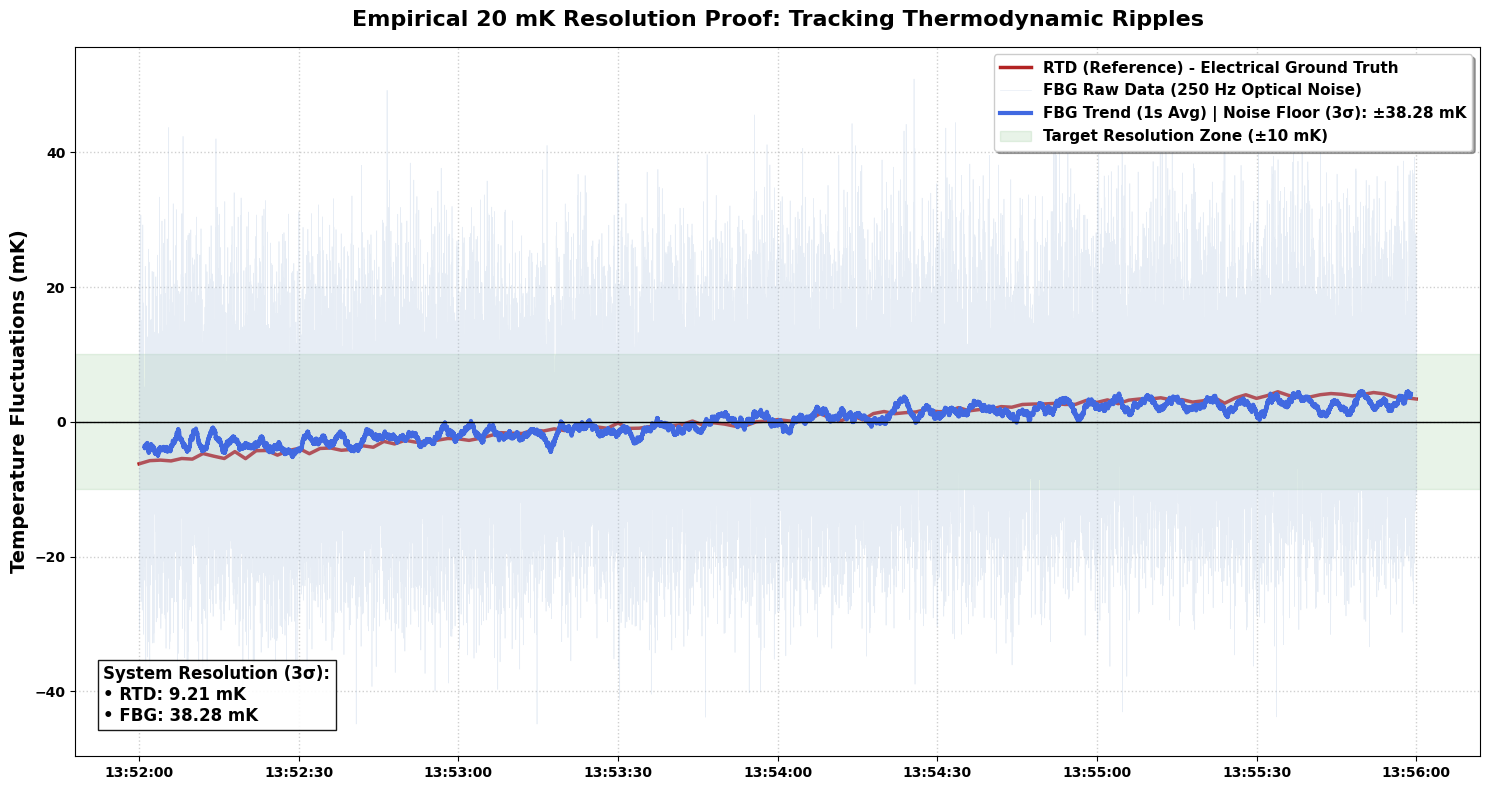

--- Veredicto de Resolución (Plateau 1) ---
Ruido residual (3σ) a 1s: 38.28 mK
⚠️ NOTA: El ruido detectado es próximo al límite de 20 mK.


In [37]:
# ============================================================================
# EMPIRICAL RESOLUTION PROOF: Tracking Natural Thermodynamic Ripples (mK)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# --- CONFIGURACIÓN ---
# Aseguramos que la ventana sea consistente con la frecuencia de muestreo (250Hz)
WINDOW_SIZE = 250 

# --- CÁLCULO Y FILTRADO ---
# (Asumiendo que T_fbg_converted y T_rtd_zoom ya están en mK tras la resta de la media)
fbg_clean_mK = pd.Series(fbg_centered_mK).rolling(window=WINDOW_SIZE, center=True).mean()

# --- ANÁLISIS ESTADÍSTICO DE RUIDO (Suelo de resolución) ---
# El ruido (sigma) se calcula sobre la diferencia entre la señal cruda y la tendencia
fbg_noise = fbg_centered_mK - fbg_clean_mK.fillna(0)
sigma_1s = np.std(fbg_noise)
tres_sigma = 3 * sigma_1s

# ========================================================================
# PLOT DE ALTA PRECISIÓN METROLÓGICA
# ========================================================================
fig, ax = plt.subplots(figsize=(15, 8))

# 1. Graficar RTD (La Referencia)
ax.plot(t_rtd_zoom, rtd_centered_mK, color='firebrick', linewidth=2.5, 
        label='RTD (Reference) - Electrical Ground Truth')

# 2. Graficar FBG (Crudo + Tendencia)
ax.plot(t_fbg_zoom, fbg_centered_mK, color='lightsteelblue', alpha=0.3, linewidth=0.5, 
        label='FBG Raw Data (250 Hz Optical Noise)')
ax.plot(t_fbg_zoom, fbg_clean_mK, color='royalblue', linewidth=3, 
        label=f'FBG Trend (1s Avg) | Noise Floor (3σ): ±{tres_sigma:.2f} mK')

# 3. Bandas de resolución objetivo
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.axhspan(-10, 10, color='forestgreen', alpha=0.1, label='Target Resolution Zone (±10 mK)')

# 4. Estética y etiquetas
ax.set_title('Empirical 20 mK Resolution Proof: Tracking Thermodynamic Ripples', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Temperature Fluctuations (mK)', fontsize=14)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.grid(True, linestyle=':', linewidth=1, alpha=0.6)

# Veredicto dinámico en texto
stats_label = (f"System Resolution (3σ):\n"
               f"• RTD: {np.std(rtd_centered_mK)*3:.2f} mK\n"
               f"• FBG: {tres_sigma:.2f} mK")
ax.text(0.02, 0.05, stats_label, transform=ax.transAxes, fontsize=12, 
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# --- IMPRESIÓN DE VEREDICTO ---
print(f"--- Veredicto de Resolución (Plateau 1) ---")
print(f"Ruido residual (3σ) a 1s: {tres_sigma:.2f} mK")
if tres_sigma < 20:
    print("✅ AFIRMACIÓN: El sistema detecta gradientes < 20 mK con margen estadístico.")
else:
    print("⚠️ NOTA: El ruido detectado es próximo al límite de 20 mK.")

⏳ Procesando Análisis de Residuos RMS en el Plateau 1...


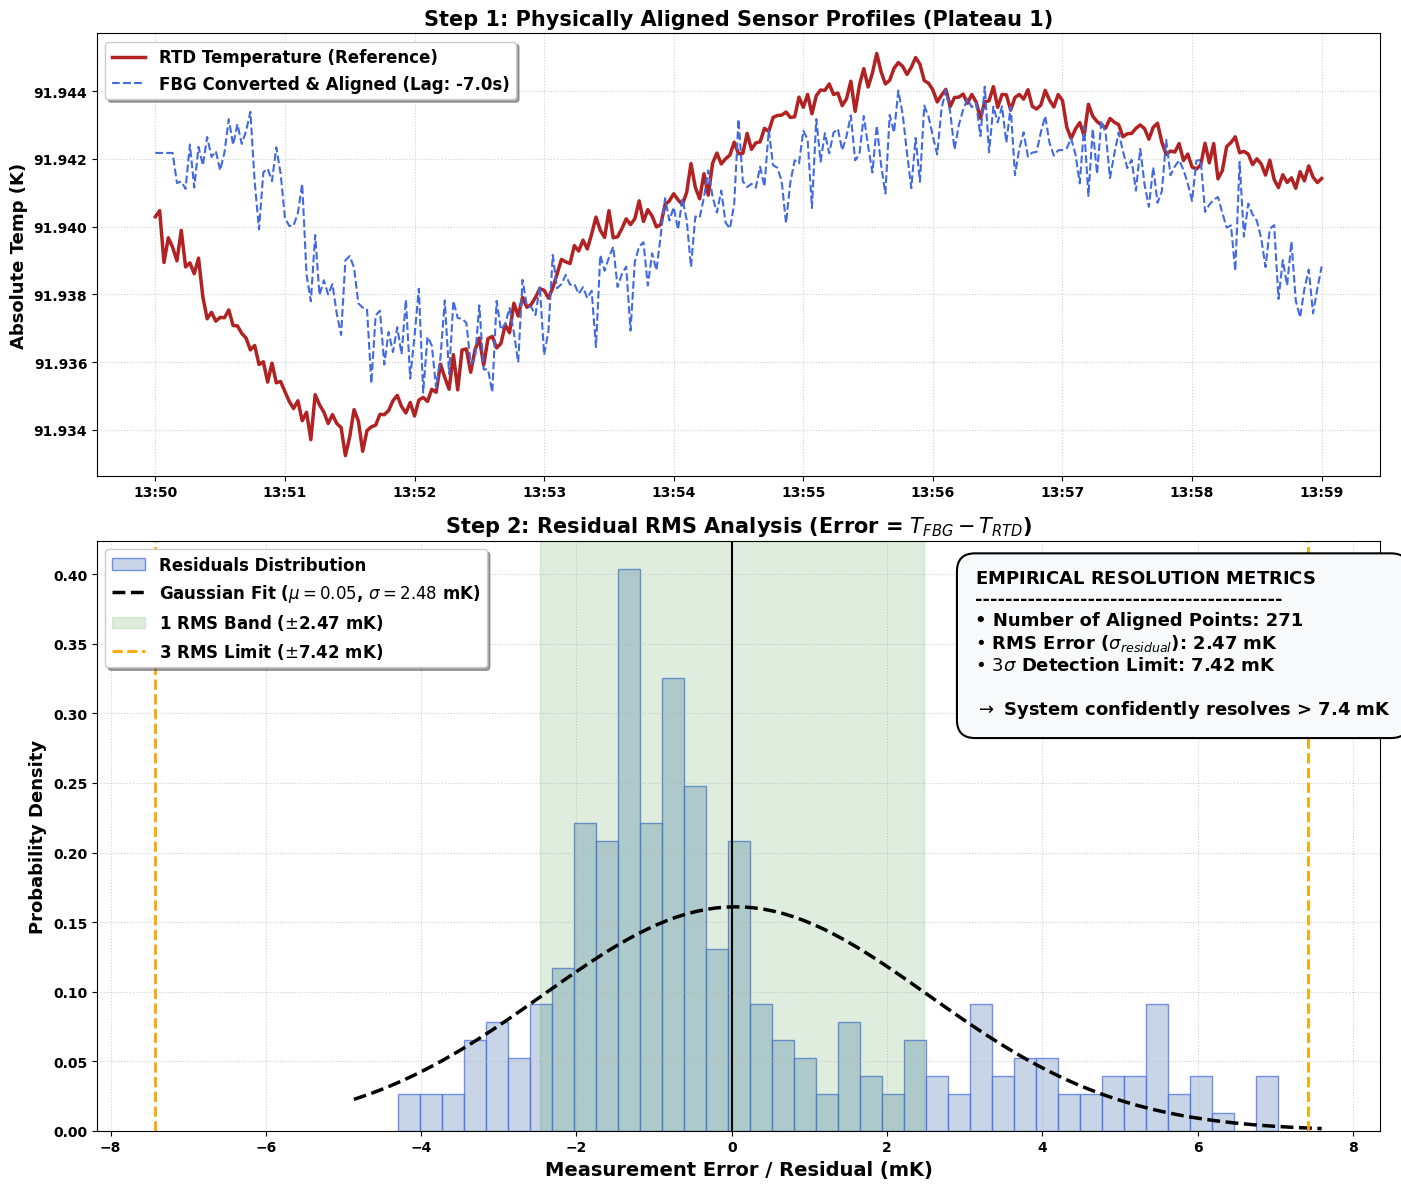


 📊 RESIDUAL ANALYSIS VERDICT (TUTOR'S METHOD) 
• Thermal Lag Applied:    -7.0 seconds
• Residual Mean Error:    0.048 mK
• Residual RMS (1-sigma): 2.47 mK
• Empirical Resolution Limit (3-sigma): 7.42 mK


In [ ]:
# ============================================================================
# TUTOR'S METHOD: Residual RMS Analysis (Empirical Resolution Verification)
# Fiber: PEEK-4 | Sensor 1 | Aligned Plateau Analysis
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from scipy.stats import norm

# --- 1. CONFIGURACIÓN Y PARÁMETROS ---
sensor_key = "FBG-1-Mean"
fbg_times = fbg_mean_data[sensor_key]["timestamps"]
fbg_wavs = fbg_mean_data[sensor_key]["wavelength"]

SENSITIVITY_PM_K = 18.669
SENSITIVITY_NM_K = SENSITIVITY_PM_K / 1000.0
LAG_SECONDS = -7.0  # El retardo físico que calculamos previamente

if len(plateau_data) >= 1:
    print("⏳ Procesando Análisis de Residuos RMS en el Plateau 1...")
    
    # Extraer límites del Plateau 1 (quitando el primer 10% para asegurar equilibrio)
    p1_start = plateau_data[0]["t0"]
    p1_end = plateau_data[0]["tfin"]
    dur = (p1_end - p1_start).total_seconds()
    eval_start = p1_start + datetime.timedelta(seconds=dur*0.1)
    eval_end = p1_end
    
    # Extraer datos brutos en la ventana
    m_rtd = (times_temp_ref >= eval_start) & (times_temp_ref <= eval_end)
    m_fbg = (fbg_times >= eval_start) & (fbg_times <= eval_end)
    
    t_rtd = times_temp_ref[m_rtd]
    T_rtd = temp_ref_valid[m_rtd]
    
    t_fbg = fbg_times[m_fbg]
    W_fbg = fbg_wavs[m_fbg]
    
    # --- 2. CONVERSIÓN A TEMPERATURA ABSOLUTA ---
    # Anclamos el FBG a la temperatura media del RTD en el plateau
    mean_T_rtd = np.mean(T_rtd)
    mean_W_fbg = np.mean(W_fbg)
    
    # T_fbg = T_referencia + (W - W_referencia) / Sensibilidad
    T_fbg = mean_T_rtd + (W_fbg - mean_W_fbg) / SENSITIVITY_NM_K
    
    # --- 3. ALINEAMIENTO TEMPORAL (Restar el Thermal Lag) ---
    # Convertimos los tiempos a timestamps (segundos) para poder interpolar matemáticamente
    t_rtd_sec = np.array([t.timestamp() for t in t_rtd])
    t_fbg_sec = np.array([t.timestamp() for t in t_fbg])
    
    # Sincronizamos: desplazamos el tiempo del RTD sumándole el lag
    t_rtd_aligned_sec = t_rtd_sec + LAG_SECONDS
    
    # --- 4. INTERPOLACIÓN Y CÁLCULO DEL RESIDUO ---
    # Interpolamos el FBG (alta frec) a los tiempos alineados del RTD (baja frec)
    # Primero aplicamos un ligero filtro a T_fbg para quitar el ruido del láser y evitar aliasing
    T_fbg_smooth = pd.Series(T_fbg).rolling(window=250, center=True).mean().bfill().ffill().values
    
    T_fbg_interp = np.interp(t_rtd_aligned_sec, t_fbg_sec, T_fbg_smooth)
    
    # Cálculo del Error / Residuo en miliKelvins
    error_mK = (T_fbg_interp - T_rtd) * 1000.0
    
    # Cálculo del RMS (Root Mean Square)
    rms_error = np.sqrt(np.mean(error_mK**2))
    std_error = np.std(error_mK, ddof=1)
    mean_error = np.mean(error_mK)
    
    # --- 5. VISUALIZACIÓN DE ALTA CALIDAD METROLÓGICA ---
    plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1.5, 2]})
    
    # PANEL SUPERIOR: Series Temporales Alineadas
    ax1.plot(t_rtd, T_rtd, color='firebrick', linewidth=2.5, label='RTD Temperature (Reference)')
    
    # Para plotear el FBG alineado, usamos los tiempos del RTD (ya que interpolamos)
    ax1.plot(t_rtd, T_fbg_interp, color='royalblue', linewidth=1.5, linestyle='--', 
             label=f'FBG Converted & Aligned (Lag: {LAG_SECONDS}s)')
    
    ax1.set_title('Step 1: Physically Aligned Sensor Profiles (Plateau 1)', fontsize=15, fontweight='bold')
    ax1.set_ylabel('Absolute Temp (K)', fontsize=13)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    
    # PANEL INFERIOR: Histograma de Residuos (El Gráfico del Tutor)
    counts, bins, patches = ax2.hist(error_mK, bins=40, density=True, color='lightsteelblue', edgecolor='royalblue', alpha=0.7, label='Residuals Distribution')
    
    # Ajuste de Campana de Gauss
    xmin, xmax = ax2.get_xlim()
    x_pdf = np.linspace(xmin, xmax, 100)
    y_pdf = norm.pdf(x_pdf, mean_error, std_error)
    ax2.plot(x_pdf, y_pdf, 'k--', linewidth=2.5, label=rf'Gaussian Fit ($\mu={mean_error:.2f}$, $\sigma={std_error:.2f}$ mK)')
    
    # Líneas de referencia RMS
    ax2.axvline(0, color='black', linewidth=1.5)
    ax2.axvspan(-rms_error, rms_error, color='forestgreen', alpha=0.15, label=rf'1 RMS Band ($\pm${rms_error:.2f} mK)')
    ax2.axvline(-rms_error*3, color='orange', linestyle='--', linewidth=2, label=rf'3 RMS Limit ($\pm${rms_error*3:.2f} mK)')
    ax2.axvline(rms_error*3, color='orange', linestyle='--', linewidth=2)
    
    ax2.set_title(f'Step 2: Residual RMS Analysis (Error = $T_{{FBG}} - T_{{RTD}}$)', fontsize=15, fontweight='bold')
    ax2.set_xlabel('Measurement Error / Residual (mK)', fontsize=14)
    ax2.set_ylabel('Probability Density', fontsize=13)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
    
    # Cuadro de resultados para la tesis
    verdict = (
        rf"$\mathbf{{EMPIRICAL\ RESOLUTION\ METRICS}}$" + "\n"
        f"-----------------------------------------\n"
        f"• Number of Aligned Points: {len(error_mK)}\n"
        rf"• RMS Error ($\sigma_{{residual}}$): $\mathbf{{{rms_error:.2f}\ mK}}$" + "\n"
        rf"• $3\sigma$ Detection Limit: $\mathbf{{{rms_error*3:.2f}\ mK}}$" + "\n\n"
        rf"$\rightarrow$ System confidently resolves > {rms_error*3:.1f} mK"
    )
    fig.text(0.70, 0.4, verdict, transform=fig.transFigure, fontsize=13, 
             fontweight='bold', bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='black', linewidth=1.5))
    
    plt.tight_layout()
    plt.show()

    print("\n" + "="*65)
    print(" 📊 RESIDUAL ANALYSIS VERDICT (TUTOR'S METHOD) ")
    print("="*65)
    print(f"• Thermal Lag Applied:    {LAG_SECONDS} seconds")
    print(f"• Residual Mean Error:    {mean_error:.3f} mK")
    print(f"• Residual RMS (1-sigma): {rms_error:.2f} mK")
    print(f"• Empirical Resolution Limit (3-sigma): {rms_error*3:.2f} mK")
    print("="*65)
else:
    print("⚠️ Datos insuficientes para el análisis de plateaus.")

🔍 Iniciando escaneo global de Thermal Lag para 2 sensores y 7 rampas...

 ⏱️ THERMAL LAG VALIDATION SUMMARY (RTD vs FBG)
Sensor             FBG-1-Mean  FBG-2-Mean
Rampa                                    
Ramp 1 (P1 -> P2)        -7.0        -3.0
Ramp 2 (P2 -> P3)       -10.0       -13.0
Ramp 3 (P3 -> P4)       -11.0       -23.0
Ramp 4 (P4 -> P5)         6.0       -12.0
Ramp 5 (P5 -> P6)        -6.0       -11.0
Ramp 6 (P6 -> P7)       -13.0        -9.0
Ramp 7 (P7 -> P8)        -4.0         3.0

Promedio Global del Retardo: -8.1 segundos



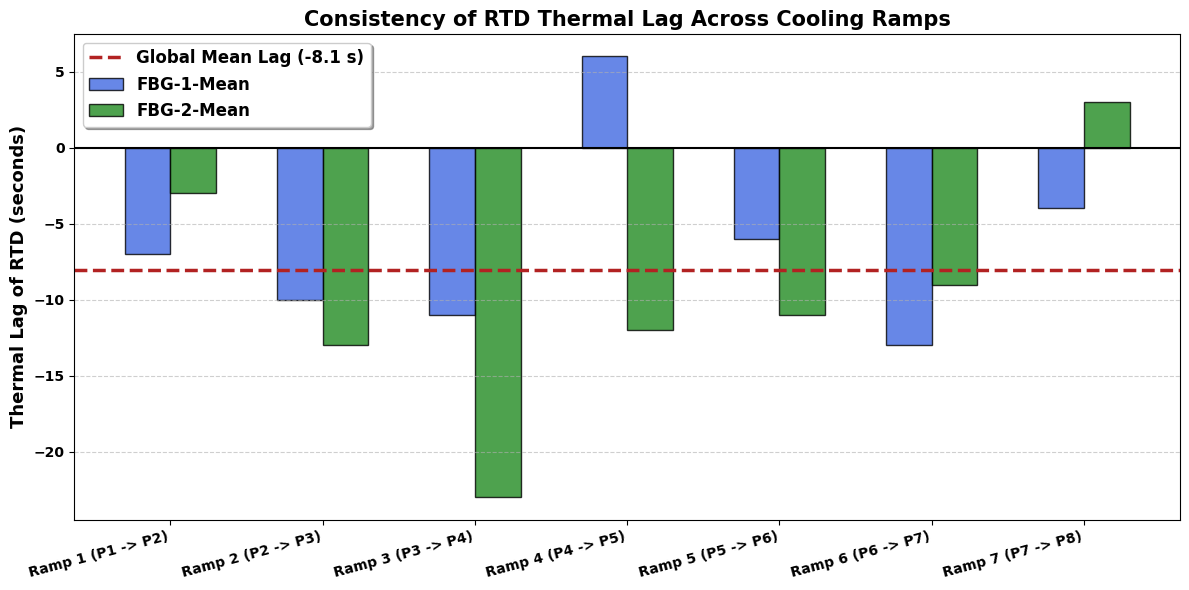

In [ ]:
# ============================================================================
# GLOBAL THERMAL LAG VALIDATION: Cross-Correlation across all Ramps & Sensors
# Fiber: PEEK-4 | Verificación de inercia térmica del RTD
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, correlate, correlation_lags
import pandas as pd

# Identificamos los sensores disponibles en tus datos
sensores_disponibles = [k for k in fbg_mean_data.keys() if "Mean" in k]
resultados_lag = []

if len(plateau_data) < 2:
    print("⚠️ No hay suficientes plateaus para analizar rampas intermedias.")
else:
    print(f"🔍 Iniciando escaneo global de Thermal Lag para {len(sensores_disponibles)} sensores y {len(plateau_data)-1} rampas...\n")
    
    # Bucle por cada rampa (transición entre Plateau i y Plateau i+1)
    for i in range(len(plateau_data) - 1):
        r_start = plateau_data[i]["tfin"]
        r_end = plateau_data[i+1]["t0"]
        nombre_rampa = f"Ramp {i+1} (P{i+1} -> P{i+2})"
        
        # Máscara temporal para el RTD en esta rampa
        m_rtd = (times_temp_ref >= r_start) & (times_temp_ref <= r_end)
        if sum(m_rtd) < 10:
            continue # Rampa muy corta o sin datos
            
        t0_dt = times_temp_ref[m_rtd][0]
        t_rtd_s = np.array([(t - t0_dt).total_seconds() for t in times_temp_ref[m_rtd]])
        T_raw = temp_ref_valid[m_rtd]
        
        # Bucle por cada sensor FBG
        for sensor_key in sensores_disponibles:
            fbg_times = fbg_mean_data[sensor_key]["timestamps"]
            fbg_wavs = fbg_mean_data[sensor_key]["wavelength"]
            
            m_fbg = (fbg_times >= r_start) & (fbg_times <= r_end)
            if sum(m_fbg) < 10:
                continue
                
            t_fbg_s = np.array([(t - t0_dt).total_seconds() for t in fbg_times[m_fbg]])
            W_raw = fbg_wavs[m_fbg]
            
            # --- ALGORITMO DE CORRELACIÓN CRUZADA (Derivadas) ---
            dt_res = 1.0 # 1 segundo de resolución base
            t_master = np.arange(0, max(t_rtd_s.max(), t_fbg_s.max()), dt_res)
            
            T_interp = np.interp(t_master, t_rtd_s, T_raw)
            W_interp = np.interp(t_master, t_fbg_s, W_raw)
            
            # Normalización
            T_norm = (T_interp - T_interp.min()) / (T_interp.max() - T_interp.min())
            W_norm = (W_interp - W_interp.min()) / (W_interp.max() - W_interp.min())
            
            # Suavizado y Derivadas
            W_norm_smooth = savgol_filter(W_norm, window_length=31, polyorder=2)
            T_norm_smooth = savgol_filter(T_norm, window_length=31, polyorder=2)
            
            dW_norm = np.gradient(W_norm_smooth)
            dT_norm = np.gradient(T_norm_smooth)
            
            # Correlación pura
            corr = correlate(dW_norm, dT_norm, mode='full')
            lags = correlation_lags(len(dW_norm), len(dT_norm), mode='full')
            
            lag_optimo_segundos = lags[np.argmax(corr)] * dt_res
            
            resultados_lag.append({
                "Rampa": nombre_rampa,
                "Sensor": sensor_key,
                "Thermal Lag (s)": lag_optimo_segundos
            })

    # --- PRESENTACIÓN DE RESULTADOS ---
    df_lags = pd.DataFrame(resultados_lag)
    
    # 1. Tabla por terminal
    print("=================================================================")
    print(" ⏱️ THERMAL LAG VALIDATION SUMMARY (RTD vs FBG)")
    print("=================================================================")
    # Reestructurar la tabla para que sea fácil de leer (Rampas en filas, Sensores en columnas)
    df_pivot = df_lags.pivot(index="Rampa", columns="Sensor", values="Thermal Lag (s)")
    print(df_pivot.to_string())
    print("\nPromedio Global del Retardo: {:.1f} segundos".format(df_lags['Thermal Lag (s)'].mean()))
    print("=================================================================\n")

    # 2. Gráfico visual para la tesis/tutor
    plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colores = ['royalblue', 'forestgreen', 'darkorange']
    for idx, sensor in enumerate(sensores_disponibles):
        df_sensor = df_lags[df_lags["Sensor"] == sensor]
        x_pos = np.arange(len(df_sensor))
        
        # Desplazar un poco las barras si hay varios sensores para que no se superpongan
        desplazamiento = (idx - len(sensores_disponibles)/2.0 + 0.5) * 0.3
        
        ax.bar(x_pos + desplazamiento, df_sensor["Thermal Lag (s)"], width=0.3, 
               color=colores[idx % len(colores)], label=sensor, alpha=0.8, edgecolor='black')

    ax.set_xticks(np.arange(len(df_pivot)))
    ax.set_xticklabels(df_pivot.index, rotation=15, ha='right')
    ax.axhline(0, color='black', linewidth=1.5)
    
    # Línea de tendencia media global
    media_global = df_lags['Thermal Lag (s)'].mean()
    ax.axhline(media_global, color='firebrick', linestyle='--', linewidth=2.5, 
               label=f'Global Mean Lag ({media_global:.1f} s)')

    ax.set_ylabel('Thermal Lag of RTD (seconds)', fontsize=13)
    ax.set_title('Consistency of RTD Thermal Lag Across Cooling Ramps', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, frameon=True, shadow=True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

🔍 Iniciando método robusto de Minimización RMS para el Thermal Lag...



 🛡️ ROBUST LAG VALIDATION (MINIMUM RMS ERROR METHOD)
Sensor           FBG-1-Mean  FBG-2-Mean
Rampa                                  
Ramp 1 (P1->P2)        -8.5         0.5
Ramp 2 (P2->P3)       -14.5        -7.0
Ramp 3 (P3->P4)        -7.0       -16.0
Ramp 4 (P4->P5)        -1.5        -7.5
Ramp 5 (P5->P6)        -8.0        -6.0
Ramp 6 (P6->P7)       -15.0        -5.0
Ramp 7 (P7->P8)        -4.0         1.5

Promedio Global del Retardo (Robusto): -7.0 segundos



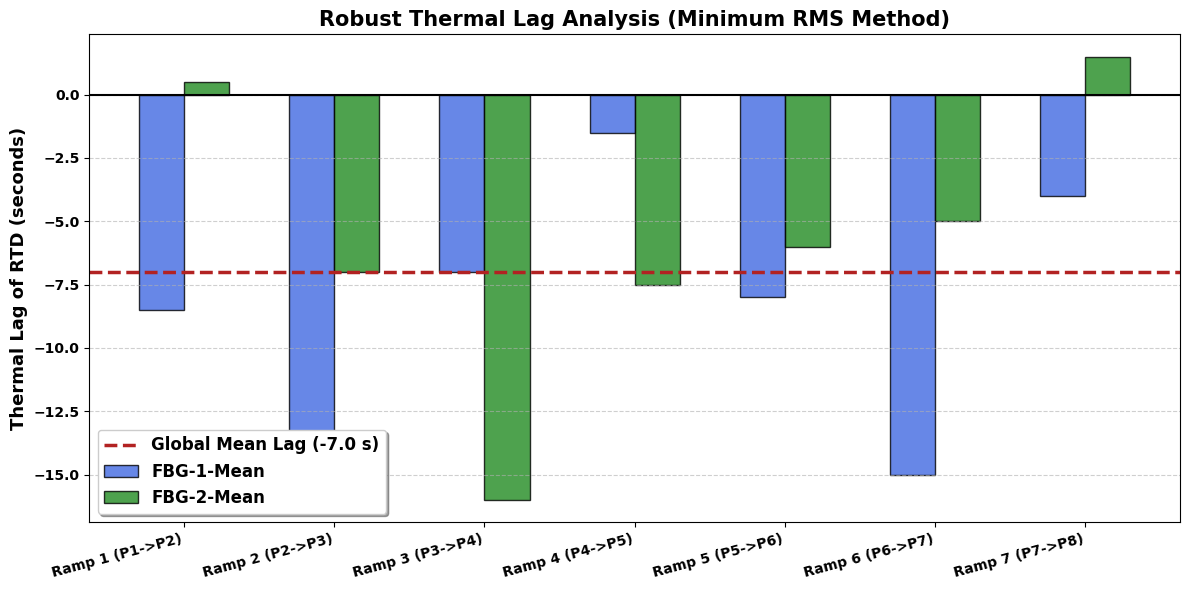

In [ ]:
# ============================================================================
# ROBUST THERMAL LAG VALIDATION: Minimum RMS Error Method (No Derivatives)
# Fiber: PEEK-4 | Verificación de inercia térmica
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

sensores_disponibles = [k for k in fbg_mean_data.keys() if "Mean" in k]
resultados_lag_robusto = []

# Rango de retardos a explorar (en segundos). Asumimos que el RTD va retrasado entre 0 y 30s.
posibles_lags = np.arange(-30.0, 5.0, 0.5) 

if len(plateau_data) < 2:
    print("⚠️ No hay suficientes plateaus.")
else:
    print("🔍 Iniciando método robusto de Minimización RMS para el Thermal Lag...\n")
    
    for i in range(len(plateau_data) - 1):
        r_start = plateau_data[i]["tfin"]
        r_end = plateau_data[i+1]["t0"]
        nombre_rampa = f"Ramp {i+1} (P{i+1}->P{i+2})"
        
        m_rtd = (times_temp_ref >= r_start) & (times_temp_ref <= r_end)
        if sum(m_rtd) < 10: continue
            
        t0_dt = times_temp_ref[m_rtd][0]
        t_rtd_s = np.array([(t - t0_dt).total_seconds() for t in times_temp_ref[m_rtd]])
        T_raw = temp_ref_valid[m_rtd]
        
        for sensor_key in sensores_disponibles:
            fbg_times = fbg_mean_data[sensor_key]["timestamps"]
            fbg_wavs = fbg_mean_data[sensor_key]["wavelength"]
            
            m_fbg = (fbg_times >= r_start) & (fbg_times <= r_end)
            if sum(m_fbg) < 10: continue
                
            t_fbg_s = np.array([(t - t0_dt).total_seconds() for t in fbg_times[m_fbg]])
            W_raw = fbg_wavs[m_fbg]
            
            # Interpolación a 1 Hz
            dt_res = 1.0 
            t_master = np.arange(0, max(t_rtd_s.max(), t_fbg_s.max()), dt_res)
            
            T_interp = np.interp(t_master, t_rtd_s, T_raw)
            W_interp = np.interp(t_master, t_fbg_s, W_raw)
            
            # Suavizado básico para quitar ruido del láser
            W_smooth = savgol_filter(W_interp, window_length=21, polyorder=1)
            T_smooth = savgol_filter(T_interp, window_length=21, polyorder=1)
            
            # Normalización (0 a 1) para poder compararlas geométricamente
            T_norm = (T_smooth - np.min(T_smooth)) / (np.max(T_smooth) - np.min(T_smooth))
            W_norm = (W_smooth - np.min(W_smooth)) / (np.max(W_smooth) - np.min(W_smooth))
            
            # --- ALGORITMO DE MINIMIZACIÓN DE ERROR RMS ---
            errores = []
            for lag in posibles_lags:
                # Desplazamos temporalmente la señal del RTD
                t_rtd_shifted = t_master + lag
                # Interpolamos el RTD desplazado al eje de tiempo original del FBG
                T_norm_shifted = np.interp(t_master, t_rtd_shifted, T_norm, left=np.nan, right=np.nan)
                
                # Calculamos el RMS solo en la zona donde ambas curvas se solapan (sin NaNs)
                mask_valida = ~np.isnan(T_norm_shifted)
                if sum(mask_valida) > 20: # Exigimos al menos 20 segundos de solape
                    error_rms = np.sqrt(np.mean((W_norm[mask_valida] - T_norm_shifted[mask_valida])**2))
                    errores.append(error_rms)
                else:
                    errores.append(np.inf)
            
            # El lag óptimo es el que minimiza el área entre las dos curvas
            best_lag_idx = np.argmin(errores)
            lag_optimo = posibles_lags[best_lag_idx]
            
            resultados_lag_robusto.append({
                "Rampa": nombre_rampa,
                "Sensor": sensor_key,
                "Lag (s)": lag_optimo
            })

    # --- PRESENTACIÓN ---
    df_lags_rob = pd.DataFrame(resultados_lag_robusto)
    
    print("=================================================================")
    print(" 🛡️ ROBUST LAG VALIDATION (MINIMUM RMS ERROR METHOD)")
    print("=================================================================")
    df_pivot_rob = df_lags_rob.pivot(index="Rampa", columns="Sensor", values="Lag (s)")
    print(df_pivot_rob.to_string())
    media_global_rob = df_lags_rob['Lag (s)'].mean()
    print("\nPromedio Global del Retardo (Robusto): {:.1f} segundos".format(media_global_rob))
    print("=================================================================\n")

    # Gráfico
    plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colores = ['royalblue', 'forestgreen']
    for idx, sensor in enumerate(sensores_disponibles):
        df_sensor = df_lags_rob[df_lags_rob["Sensor"] == sensor]
        x_pos = np.arange(len(df_sensor))
        desplazamiento = (idx - len(sensores_disponibles)/2.0 + 0.5) * 0.3
        
        ax.bar(x_pos + desplazamiento, df_sensor["Lag (s)"], width=0.3, 
               color=colores[idx % len(colores)], label=sensor, alpha=0.8, edgecolor='black')

    ax.set_xticks(np.arange(len(df_pivot_rob)))
    ax.set_xticklabels(df_pivot_rob.index, rotation=15, ha='right')
    ax.axhline(0, color='black', linewidth=1.5)
    ax.axhline(media_global_rob, color='firebrick', linestyle='--', linewidth=2.5, 
               label=f'Global Mean Lag ({media_global_rob:.1f} s)')

    ax.set_ylabel('Thermal Lag of RTD (seconds)', fontsize=13)
    ax.set_title('Robust Thermal Lag Analysis (Minimum RMS Method)', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, frameon=True, shadow=True)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()